# Symptom-based Diabetes Classification and Unsupervised Type Profiling

This project addresses the critical need for early diabetes detection through a dual-stage machine learning framework. By utilising patient-reported symptoms, the system first performs high-precision diagnostic screening to identify diabetic cohorts and subsequently applies unsupervised clustering to profile clinical phenotypes (Type 1-like vs. Type 2-like). This structured approach aims to bridge the gap between initial symptom onset and formal clinical diagnosis using the CRISP-DM methodology.

# Business Understanding

### Project Objectives and Clinical Goals
The primary objective is to develop a reliable digital triage tool that identifies high-risk individuals and differentiates between acute (Type 1) and metabolic (Type 2) presentations. This helps to optimise hospital resources by prioritising atypical cases for specialist review while standardising follow-up for classical presentations.

### Goals
1. **Supervised Screening:** Translate clinical symptoms into a binary classification task to achieve maximum sensitivity and specificity in cohort identification.
2. **Unsupervised Subtyping:** Map latent clinical signatures within the diabetic cohort into distinct clusters to identify natural epidemiological profiles without the need for explicit disease-type labels.

### Utilities & Helper Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools matching class notebooks
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score, accuracy_score, f1_score, recall_score

# Estimators
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

# Set seed for reproducibility
seed = 42
np.random.seed(seed)

In [2]:
# Refactored helper to run and evaluate classification experiments
def run_classification_experiment(X_train, y_train, X_test, y_test, numerical_cols, categorical_cols, param_grid, model_estimator, title, seed=42):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numerical_cols),
            ('cat', OneHotEncoder(drop='first'), categorical_cols)
        ]
    )

    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_estimator)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    grid_search = GridSearchCV(clf_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_pipeline = grid_search.best_estimator_
    print(f"Best {model_estimator.__class__.__name__} estimator found:", best_pipeline)
    print(f"Best {model_estimator.__class__.__name__} params found:", grid_search.best_params_)

    y_pred, overall_accuracy = generate_model_report(
        best_pipeline, X_test, y_test,
        features=numerical_cols + categorical_cols,
        title=title,
        show_errors=True
    )
    return best_pipeline, y_pred, overall_accuracy


In [3]:
# Function to work with weighted K-Means in the Unsupervised phase
def apply_feature_weights(X_processed, feature_names, weight_dict):
    """
    Applies weights to a processed numpy array based on a dictionary of feature names.
    """
    X_weighted = X_processed.copy()
    for i, name in enumerate(feature_names):
        weight = weight_dict.get(name, 1.0) # Default weight is 1.0
        X_weighted[:, i] *= weight
    return X_weighted

In [4]:
def generate_model_report(model, X_test, y_test, features, title='Classifier Metrics', show_errors=False):
    """
    Standardizes model evaluation: predicts, prints metrics, logs features,
    plots a confusion matrix, and optionally displays misclassified samples.
    """
    y_pred = model.predict(X_test)

    print(f"\n--- {title} ---")
    print(f"Features used: {', '.join(features)}\n")
    print(classification_report(y_test, y_pred))

    acc = accuracy_score(y_test, y_pred)
    print(f"Overall Accuracy: {acc:.2f}\n")

    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'{title} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    if show_errors:
        results_df = X_test.copy()
        results_df['Actual_Class'] = y_test.map({1: 'Positive', 0: 'Negative'})
        results_df['Predicted_Class'] = pd.Series(y_pred, index=X_test.index).map({1: 'Positive', 0: 'Negative'})

        fn = results_df[(results_df['Actual_Class'] == 'Positive') & (results_df['Predicted_Class'] == 'Negative')]
        fp = results_df[(results_df['Actual_Class'] == 'Negative') & (results_df['Predicted_Class'] == 'Positive')]

        print(f"\n--- Misclassified Samples Analysis ({title}) ---")
        print(f"False Negatives: {len(fn)}")
        if not fn.empty: display(fn)

        print(f"False Positives: {len(fp)}")
        if not fp.empty: display(fp)

    return y_pred, acc

In [5]:
def generate_cluster_profiles(df, group_col, feature_list, title='Clinical Profile', palette='magma', label_map=None):
    """
    Generates a numerical profile matrix and a consolidated bar plot for clinical features.
    Handles both numerical (Age) and categorical (Yes/No) symptoms.
    Allows for explicit cluster labeling via label_map.
    """
    df_copy = df.copy()

    # Apply label mapping if provided
    if label_map:
        df_copy[group_col] = df_copy[group_col].map(label_map)

    # 1. Define aggregation logic
    agg_dict = {}
    for feat in feature_list:
        if feat == 'Age':
            agg_dict[feat] = 'mean'
        else:
            agg_dict[feat] = lambda x: (x == 'Yes').mean()

    # 2. Create Profile Matrix
    profile_matrix = df_copy.groupby(group_col).agg(agg_dict).rename(
        columns=lambda x: f"{x} (% Yes)" if x != 'Age' else "Age (Mean)"
    )

    print(f"--- {title}: Numerical Summary ---")
    display(profile_matrix.T)

    # 3. Visualization logic for categorical features
    binary_cols = [c for c in profile_matrix.columns if '(% Yes)' in c]
    if binary_cols:
        plot_data = profile_matrix[binary_cols].reset_index().melt(id_vars=group_col)

        plt.figure(figsize=(14, 6))
        sns.barplot(data=plot_data, x='variable', y='value', hue=group_col, palette=palette)
        plt.title(f"{title}: Symptom Prevalence", fontsize=14)
        plt.ylabel('Prevalence (0.0 - 1.0)')
        plt.xlabel('Clinical Features')
        plt.ylim(0, 1.1)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    return profile_matrix

In [6]:
from sklearn.decomposition import PCA

def visualize_pca_projection(X_processed, labels, centers=None, title='PCA Cluster Projection',
                             invert_axes=False, palette={1: 'red', 0: 'blue'}):
    """
    Standardizes PCA visualization across the notebook.
    Allows for axis inversion (PC1/PC2 swap) and consistent color coding.
    Returns the fitted PCA object for downstream variance/loading analysis.
    """
    pca = PCA(n_components=2, random_state=seed)
    X_pca = pca.fit_transform(X_processed)

    # Map cluster labels to colors
    color_series = pd.Series(labels).map(palette)

    plt.figure(figsize=(10, 7))

    if invert_axes:
        plt.scatter(X_pca[:, 1], X_pca[:, 0], c=color_series, s=60, alpha=0.7, edgecolors='white')
        if centers is not None:
            centers_pca = pca.transform(centers)
            plt.scatter(centers_pca[:, 1], centers_pca[:, 0], c='green', s=250, marker='X', edgecolors='black', label='Centroids')
        plt.xlabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
        plt.ylabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    else:
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=color_series, s=60, alpha=0.7, edgecolors='white')
        if centers is not None:
            centers_pca = pca.transform(centers)
            plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='green', s=250, marker='X', edgecolors='black', label='Centroids')
        plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
        plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} var)')

    plt.title(title, fontsize=15)

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='Type 1-like', markerfacecolor='red', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Type 2-like', markerfacecolor='blue', markersize=10),
        plt.Line2D([0], [0], marker='X', color='green', linestyle='', markersize=10, label='Centroids')
    ]
    plt.legend(handles=legend_elements, loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return pca

In [7]:
def plot_cluster_characterization(df, group_col, age_col='Age', symptom_list=None, palette='magma', label_map=None):
    """
    Consolidates the repeated logic for visualizing cluster profiles (Age + Symptoms).
    Allows for explicit cluster labeling via label_map to handle swapped cluster IDs.
    Fixed: Symptoms now appear in the specific order provided in symptom_list.
    Fixed: Ensures 'Type 1-like' always precedes 'Type 2-like' in plot order.
    """
    df_plot = df.copy()

    # Apply label mapping if provided to clarify group identities in the plots
    if label_map:
        df_plot[group_col] = df_plot[group_col].map(label_map)

    # Enforce strict categorical ordering: Type 1-like before Type 2-like
    order = ['Type 1-like', 'Type 2-like']
    # Only apply ordering if the labels exist in the data to avoid errors
    existing_labels = [l for l in order if l in df_plot[group_col].unique()]
    if not existing_labels:
        existing_labels = sorted(df_plot[group_col].unique())

    if symptom_list is None:
        symptom_list = []

    num_plots = 1 + len(symptom_list)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
    if num_plots == 1: axes = [axes]

    # 1. Age Distribution
    sns.boxplot(data=df_plot, x=group_col, y=age_col, ax=axes[0], palette=palette, hue=group_col, order=existing_labels, legend=False)
    axes[0].set_title(f'Age Distribution by {group_col}')

    # 2. Symptom Prevalence
    for i, sym in enumerate(symptom_list, 1):
        # Handle both Yes/No strings and numeric/boolean flags
        prevalence = df_plot[sym].map({'Yes': 1, 'No': 0}) if df_plot[sym].dtype == 'object' else df_plot[sym]
        sns.barplot(x=group_col, y=prevalence, data=df_plot, ax=axes[i], palette=palette, hue=group_col, order=existing_labels, legend=False)
        axes[i].set_title(f'Prevalence: {sym}')
        axes[i].set_ylabel('Prevalence (% Yes)')
        axes[i].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

In [8]:
def determine_consensus(row):
    if row['Approach_1_Standard_Label'] == row['Approach_2_Standard_Label']:
        return row['Approach_1_Standard_Label']
    else:
        return 'Atypical/Mixed'

In [9]:
def plot_cluster_distribution(df, cluster_col, inferred_types_map, title, palette='coolwarm'):
    """
    Calculates cluster counts and percentages and visualizes them with a pie chart.
    """
    cluster_counts = df[cluster_col].value_counts().sort_index()
    total_cases = cluster_counts.sum()
    cluster_percentages = (cluster_counts / total_cases * 100).round(2)

    descriptive_counts = cluster_counts.rename(index=inferred_types_map)
    descriptive_percentages = cluster_percentages.rename(index=inferred_types_map)

    display(pd.DataFrame({
        'Count': descriptive_counts,
        'Percentage': descriptive_percentages.astype(str) + '%'
    }))

    plt.figure(figsize=(8, 8))
    plt.pie(descriptive_percentages.values,
            labels=[f'{label} ({value}%)' for label, value in zip(descriptive_percentages.index, descriptive_percentages.values)],
            autopct='',
            startangle=90,
            colors=sns.color_palette(palette))
    plt.title(title)
    plt.axis('equal')
    plt.show()

# Data Understanding

### Dataset Description
The analysis utilises a clinical dataset of **520 patients** collected from **Sylhet Diabetes Hospital**. The data includes 16 attributes, comprising demographic info (Age, Gender) and 14 binary clinical symptoms (e.g., Polyuria, Polydipsia, Sudden Weight Loss), mapped to a final diagnostic class.

### Initial Observations
Initial exploration reveals a dataset with a higher prevalence of positive cases, necessitating stratified validation. Key symptoms like Polyuria and Polydipsia show strong visual correlations with the target class, while the broad age distribution of positive cases suggests that symptomatic profiles, rather than age alone, drive the underlying diagnostic logic.

### Data Cleaning & Outlier Policy

For this specific analysis, several standard preprocessing steps were intentionally omitted to maintain clinical integrity:

*   **Outlier Removal:** Traditional statistical outlier removal (e.g., via Z-score or IQR) was not applied to the 'Age' attribute. In a clinical context, both extremely young and extremely old patients represent valid, though potentially rare, diagnostic cases. Removing them would bias the model against atypical patient profiles.
*   **Handling Missing Values:** The dataset was provided in a complete state with no null values across the 520 records, negating the need for imputation or record deletion.
*   **Categorical Integrity:** Because the features are self-reported binary symptoms ('Yes'/'No'), there is no 'noise' in the traditional sense. The variability in responses is treated as clinical diversity rather than data error, ensuring the subsequent clustering phase captures genuine phenotypic variation.

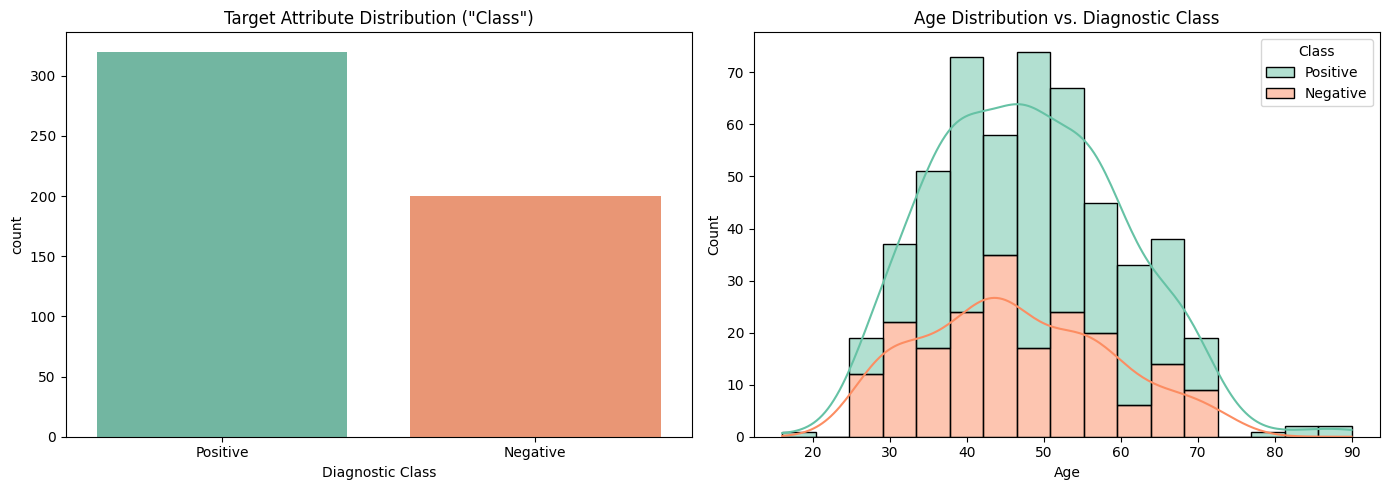

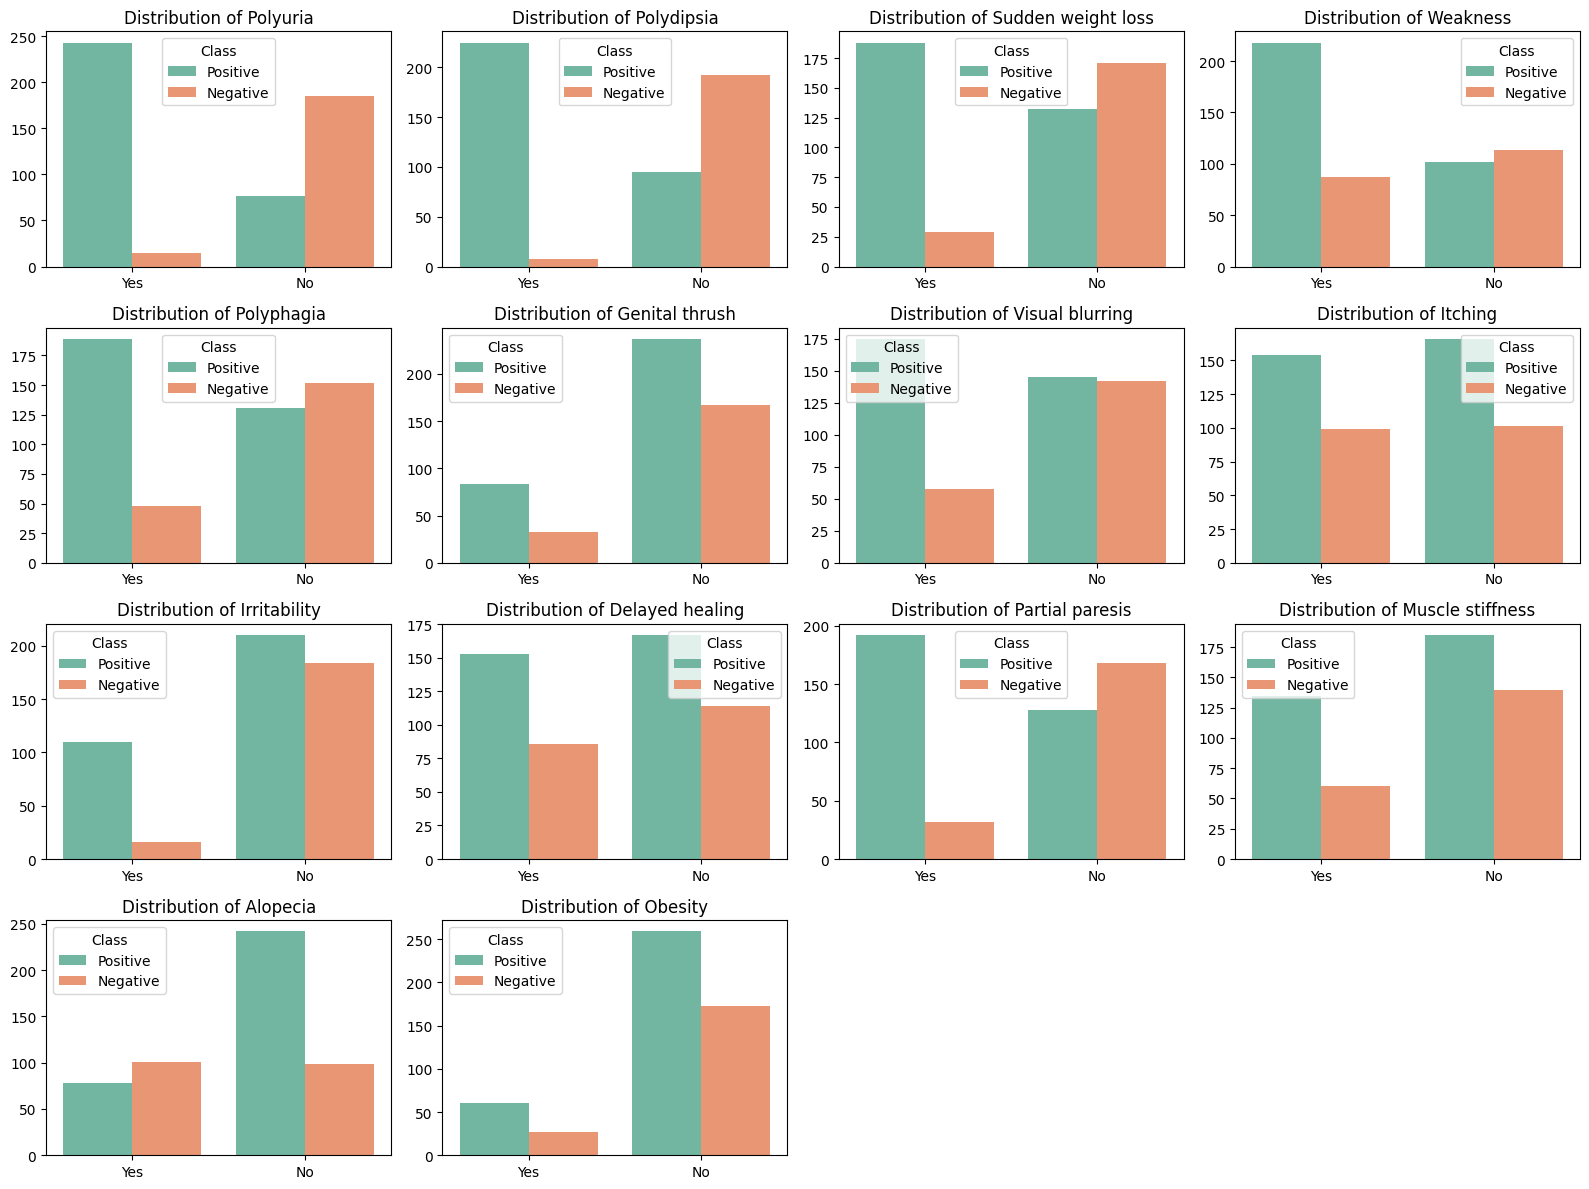

In [10]:
# Load the questionnaire dataset
df = pd.read_csv('diabetes_data_upload.csv', delimiter=';')

# Graphical Representations: Distribution Profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Target Class Imbalance check - Fixed hue warning
sns.countplot(x='Class', hue='Class', data=df, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Target Attribute Distribution ("Class")')
axes[0].set_xlabel('Diagnostic Class')

# 2. Age distribution across target classes
sns.histplot(data=df, x='Age', hue='Class', multiple='stack', kde=True, ax=axes[1], palette='Set2')
axes[1].set_title('Age Distribution vs. Diagnostic Class')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

# Graphical Representations: Distribution of other 14 features by Class
symptom_cols = [col for col in df.columns if col not in ['Age', 'Gender', 'Class']]

# Determine the number of rows and columns for the subplots dynamically
num_features = len(symptom_cols)
num_cols = 4
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3), dpi=100)
axes = axes.flatten()

for i, col in enumerate(symptom_cols):
    sns.countplot(x=col, hue='Class', data=df, ax=axes[i], palette='Set2', order=['Yes', 'No'])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].legend(title='Class')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Average Age for Diabetes-Positive Cases: 49.07 years



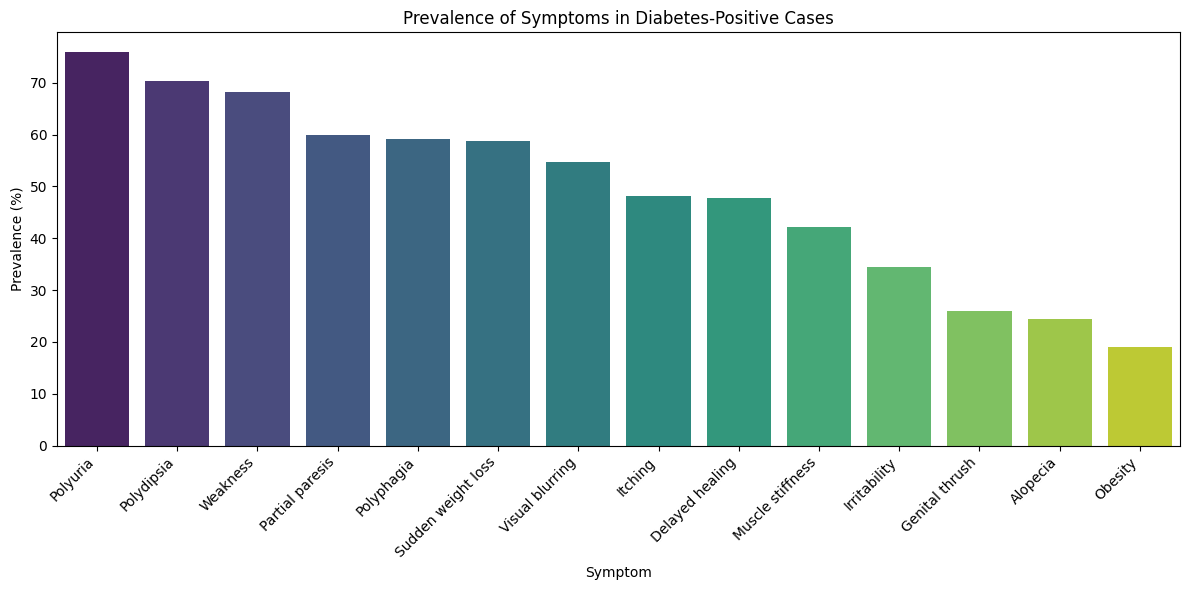

,Prevalence %
Polyuria,75.9375
Polydipsia,70.3125
Weakness,68.1250
Partial paresis,60.0000
Polyphagia,59.0625
Sudden weight loss,58.7500
Visual blurring,54.6875
Itching,48.1250
Delayed healing,47.8125
Muscle stiffness,42.1875


In [11]:
# Filter the DataFrame to include only diabetes-positive cases
diabetes_positive_df = df[df['Class'] == 'Positive'].copy()

# Calculate the average age for diabetes-positive cases
average_age_positive = diabetes_positive_df['Age'].mean()
print(f"Average Age for Diabetes-Positive Cases: {average_age_positive:.2f} years\n")

# Identify categorical symptom columns (excluding 'Gender' and 'Class')
symptom_cols = [col for col in df.columns if col not in ['Age', 'Gender', 'Class']]

# Calculate the prevalence of 'Yes' for each symptom in diabetes-positive cases
symptom_prevalence = {}
for col in symptom_cols:
    symptom_prevalence[col] = (diabetes_positive_df[col] == 'Yes').mean() * 100

# Convert to a pandas Series for better display and sorting
symptom_prevalence_series = pd.Series(symptom_prevalence)

# Sort by prevalence in descending order
symptom_prevalence_series = symptom_prevalence_series.sort_values(ascending=False)

# Visualise the prevalence of symptoms in positive cases
plt.figure(figsize=(12, 6))
sns.barplot(x=symptom_prevalence_series.index, y=symptom_prevalence_series.values, hue=symptom_prevalence_series.index, palette='viridis', legend=False)
plt.title('Prevalence of Symptoms in Diabetes-Positive Cases')
plt.xlabel('Symptom')
plt.ylabel('Prevalence (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(symptom_prevalence_series.to_frame(name='Prevalence %'))

### Feature Correlation Analysis

Before model training, the Pearson correlation between encoded clinical attributes must be considered. This step identifies redundant symptom pairs (such as Polyuria and Polydipsia) and highlights features with the strongest linear relationship to the diagnostic 'Class'.

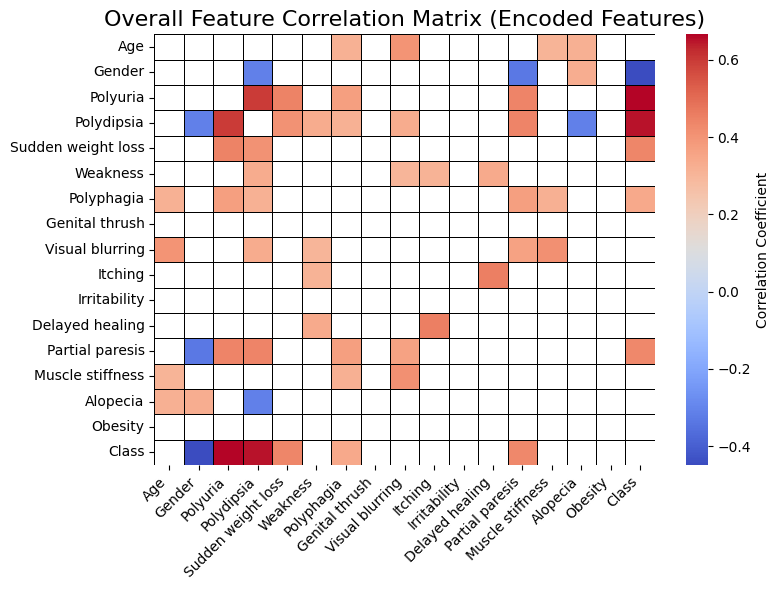

In [12]:
# Create a copy of the original DataFrame for correlation analysis
df_corr = df.copy()

# Encode all 'Yes'/'No' symptom columns to 1/0
for col in [c for c in df_corr.columns if df_corr[c].dtype == 'object' and c not in ['Gender', 'Class']]:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0})

# Encode 'Gender': Male=1, Female=0
df_corr['Gender'] = df_corr['Gender'].map({'Male': 1, 'Female': 0})

# Encode 'Class': Positive=1, Negative=0
df_corr['Class'] = df_corr['Class'].map({'Positive': 1, 'Negative': 0})

# Calculate the correlation matrix
corr_matrix = df_corr.corr()

# Define minimum correlation threshold
min_corr = 0.3

# Filter the correlation matrix: Keep values where abs(correlation) >= min_corr AND it's not the diagonal (corr != 1)
# This will set values below the threshold and on the diagonal to NaN, which seaborn displays as white
filtered_corr_matrix = corr_matrix[(np.abs(corr_matrix) >= min_corr) & (corr_matrix != 1)]

# Plot the heatmap
plt.figure(figsize=(8, 6)) # Adjusted figure size
sns.heatmap(
    filtered_corr_matrix, # Use the filtered matrix for coloring
    annot=False, # Do not show numerical annotations
    fmt=".2f",
    cmap=sns.color_palette("coolwarm", as_cmap=True), # Changed colormap to coolwarm
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Overall Feature Correlation Matrix (Encoded Features)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation of the Correlation Matrix

This heatmap visually represents the Pearson correlation coefficient between all pairs of encoded features and the target 'Class'.

*   **Red hues** indicate a positive correlation: As one variable increases, the other tends to increase.
*   **Blue hues** indicate a negative correlation: As one variable increases, the other tends to decrease.
*   **Stronger colors** (closer to 1 or -1) indicate a stronger linear relationship.
*   **Values close to 0** indicate a weak or no linear correlation.

**Key areas to observe for Data Understanding:**

1.  **Correlation with 'Class' (last row/column):** Features with high absolute correlation values with the 'Class' are generally good candidates for distinguishing between diabetic and non-diabetic individuals. These strongly correlated features are important for the initial screening phase.
2.  **Inter-feature Correlations:** Pay attention to features that are highly correlated with each other (e.g., Polyuria and Polydipsia often show high positive correlation). Understanding these relationships can inform feature selection and engineering for both classification and future subtyping efforts.

# Supervised Symptom-based Diabetes Diagnostic Screening (Classification)

## Data Preparation

This subsection details the transformation of raw clinical survey data into a format suitable for high-precision diagnostic screening.

**Rationale for Preprocessing:**
- **One-Hot Encoding:** Applied to categorical symptoms to prevent the model from assuming a numerical hierarchy (e.g., 'Yes' being 'better' than 'No').
- **Min-Max Scaling:** Selected specifically for the 'Age' attribute to normalise its range to [0,1], ensuring that the larger scale of age values does not disproportionately dominate the model's distance calculations compared to binary [0,1] symptom flags.
- **Stratified Partitioning:** Executing the `train_test_split` (80/20) ensures that both the training and testing sets reflect the real-world prevalence of diabetes found in the original hospital data.

In [13]:
### Data Preparation: Pipeline Implementation

# Features and target isolation
X = df.drop(columns=['Class'])
y = df['Class'].map({'Positive': 1, 'Negative': 0})

# Stratified split to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)

numerical_cols = ['Age']
categorical_cols = [col for col in X.columns if col != 'Age']

# Preprocessing Pipeline (See Methodology Section for scaling and encoding rationales)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

print(f"Data Preparation Pipeline initialised. Training items: {len(X_train)}, Testing items: {len(X_test)}")

Data Preparation Pipeline initialised. Training items: 416, Testing items: 104


## Modelling

Best estimator found: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['Age']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender', 'Polyuria',
                                                   'Polydipsia',
                                                   'Sudden weight loss',
                                                   'Weakness', 'Polyphagia',
                                                   'Genital thrush',
                                                   'Visual blurring', 'Itching',
                                                   'Irritability',
                                                   'Delayed healing',
                                                   'Partial paresis',
                               

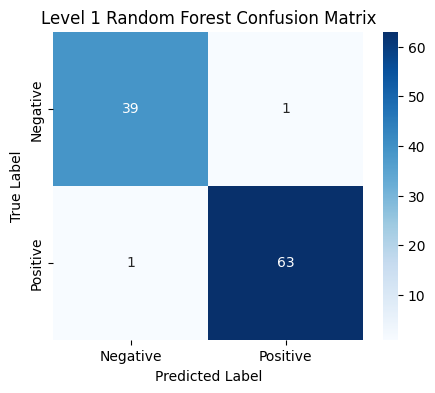


--- Misclassified Samples Analysis (Level 1 Random Forest) ---
False Negatives: 1


,Age,Gender,Polyuria,Polydipsia,Sudden weight loss,Weakness,Polyphagia,Genital thrush,Visual blurring,Itching,Irritability,Delayed healing,Partial paresis,Muscle stiffness,Alopecia,Obesity,Actual_Class,Predicted_Class
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive,Negative


False Positives: 1


,Age,Gender,Polyuria,Polydipsia,Sudden weight loss,Weakness,Polyphagia,Genital thrush,Visual blurring,Itching,Irritability,Delayed healing,Partial paresis,Muscle stiffness,Alopecia,Obesity,Actual_Class,Predicted_Class
321,34,Female,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Negative,Positive


In [14]:
# Form full class pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=seed))
])

# Parameter space mapping
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [4, 6, 8, None],
    'classifier__min_samples_split': [2, 5]
}

# Cross-Validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
grid_search = GridSearchCV(clf_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_clf_pipeline = grid_search.best_estimator_
print("Best estimator found:", best_clf_pipeline)
print("Best params found:", grid_search.best_params_)

# Model Evaluation
# Level 1 Random Forest Report with Error Analysis
y_pred, overall_accuracy = generate_model_report(
    best_clf_pipeline, X_test, y_test,
    features=numerical_cols + categorical_cols,
    title='Level 1 Random Forest',
    show_errors=True
)

### Feature Importance Analysis
This visualization identifies which patient symptoms and attributes were most critical for the Random Forest model's diagnostic decisions.

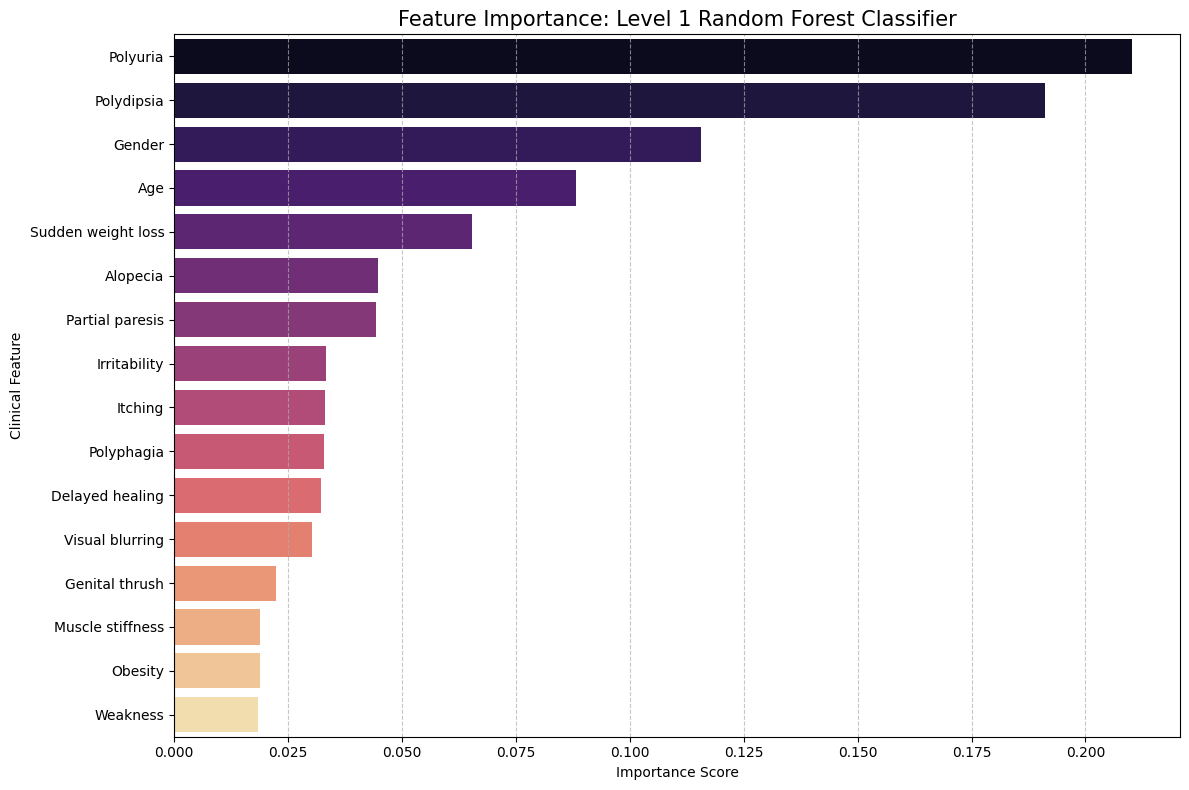

In [15]:
# Extract feature names from the ColumnTransformer
feature_names = numerical_cols + categorical_cols

# Get importances from the classifier step of the pipeline
importances = best_clf_pipeline.named_steps['classifier'].feature_importances_

# Create a DataFrame for easy plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Feature Importance: Level 1 Random Forest Classifier', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Clinical Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Experiment: Supervised Symptom-based Diabetes Diagnostic Screening with a single Decision Tree Classifier

Let's compare the performance of a single Decision Tree Classifier against the Random Forest Classifier already used in the Supervised Symptom-based Diabetes Diagnostic Screening stage.

Best Decision Tree estimator found: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['Age']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender', 'Polyuria',
                                                   'Polydipsia',
                                                   'Sudden weight loss',
                                                   'Weakness', 'Polyphagia',
                                                   'Genital thrush',
                                                   'Visual blurring', 'Itching',
                                                   'Irritability',
                                                   'Delayed healing',
                                                   'Partial paresis',
                 

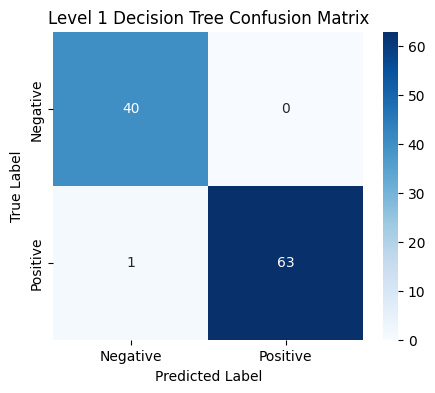


--- Misclassified Samples Analysis (Level 1 Decision Tree) ---
False Negatives: 1


,Age,Gender,Polyuria,Polydipsia,Sudden weight loss,Weakness,Polyphagia,Genital thrush,Visual blurring,Itching,Irritability,Delayed healing,Partial paresis,Muscle stiffness,Alopecia,Obesity,Actual_Class,Predicted_Class
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive,Negative


False Positives: 0


In [16]:
# Form full class pipeline for Decision Tree
dt_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=seed))
])

# Parameter space for Decision Tree
dt_param_grid = {
    'classifier__max_depth': [4, 6, 8, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}

# Cross-Validation setup (using the same as before)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed) # Already defined
dt_grid_search = GridSearchCV(dt_clf_pipeline, dt_param_grid, cv=cv, scoring='f1', n_jobs=-1)
dt_grid_search.fit(X_train, y_train)

best_dt_clf_pipeline = dt_grid_search.best_estimator_
print("Best Decision Tree estimator found:", best_dt_clf_pipeline)
print("Best Decision Tree params found:", dt_grid_search.best_params_)

# Refactored: Level 1 Decision Tree Report with Error Analysis
y_pred_dt, overall_accuracy_dt = generate_model_report(
    best_dt_clf_pipeline, X_test, y_test,
    features=numerical_cols + categorical_cols,
    title='Level 1 Decision Tree',
    show_errors=True
)

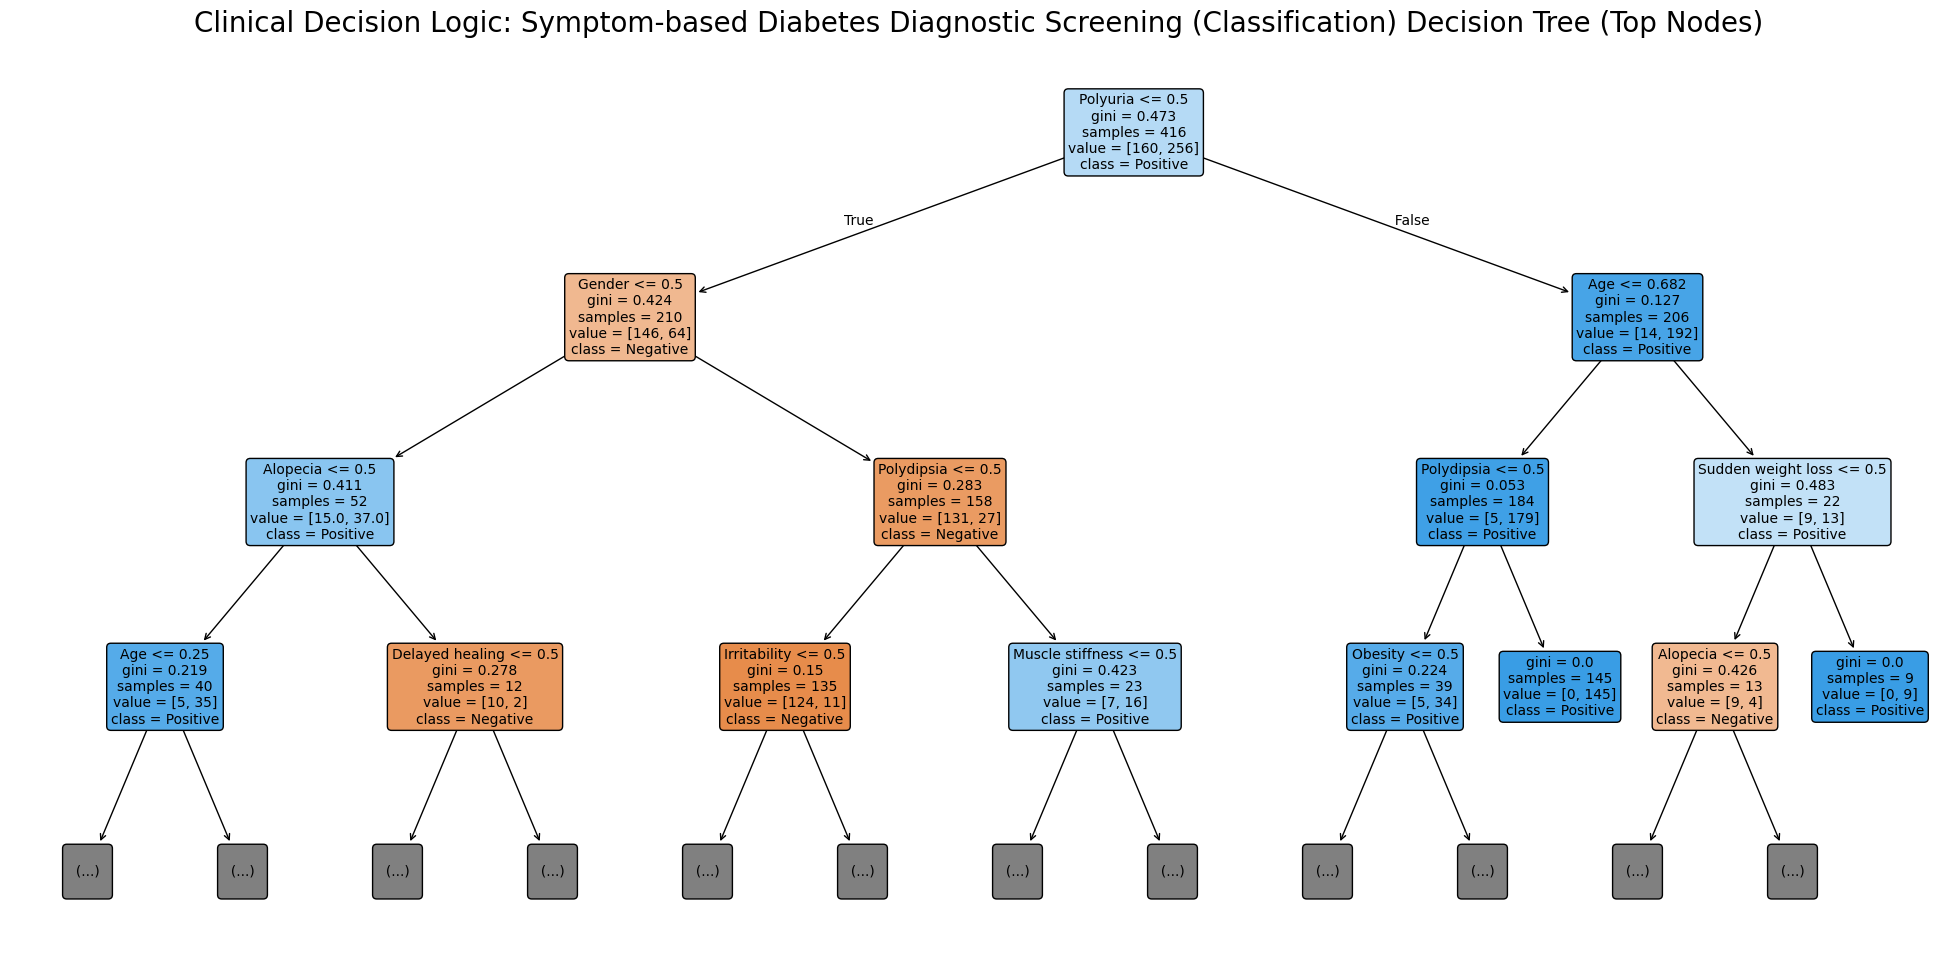

In [17]:
# Extract the trained Decision Tree model from the pipeline
dt_model = best_dt_clf_pipeline.named_steps['classifier']

# Visualization of the decision tree rules to interpret categorical logic
plt.figure(figsize=(25, 12))
plot_tree(
    dt_model,
    feature_names=feature_names,  # Fixed: changed from all_features to feature_names
    class_names=['Negative', 'Positive'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title('Clinical Decision Logic: Symptom-based Diabetes Diagnostic Screening (Classification) Decision Tree (Top Nodes)', fontsize=20)
plt.show()

### Visualising an Individual Tree from the Random Forest Ensemble
Since a Random Forest consists of multiple trees (the 150 in optimised model), a single estimator is visualised to better understand the typical decision path.

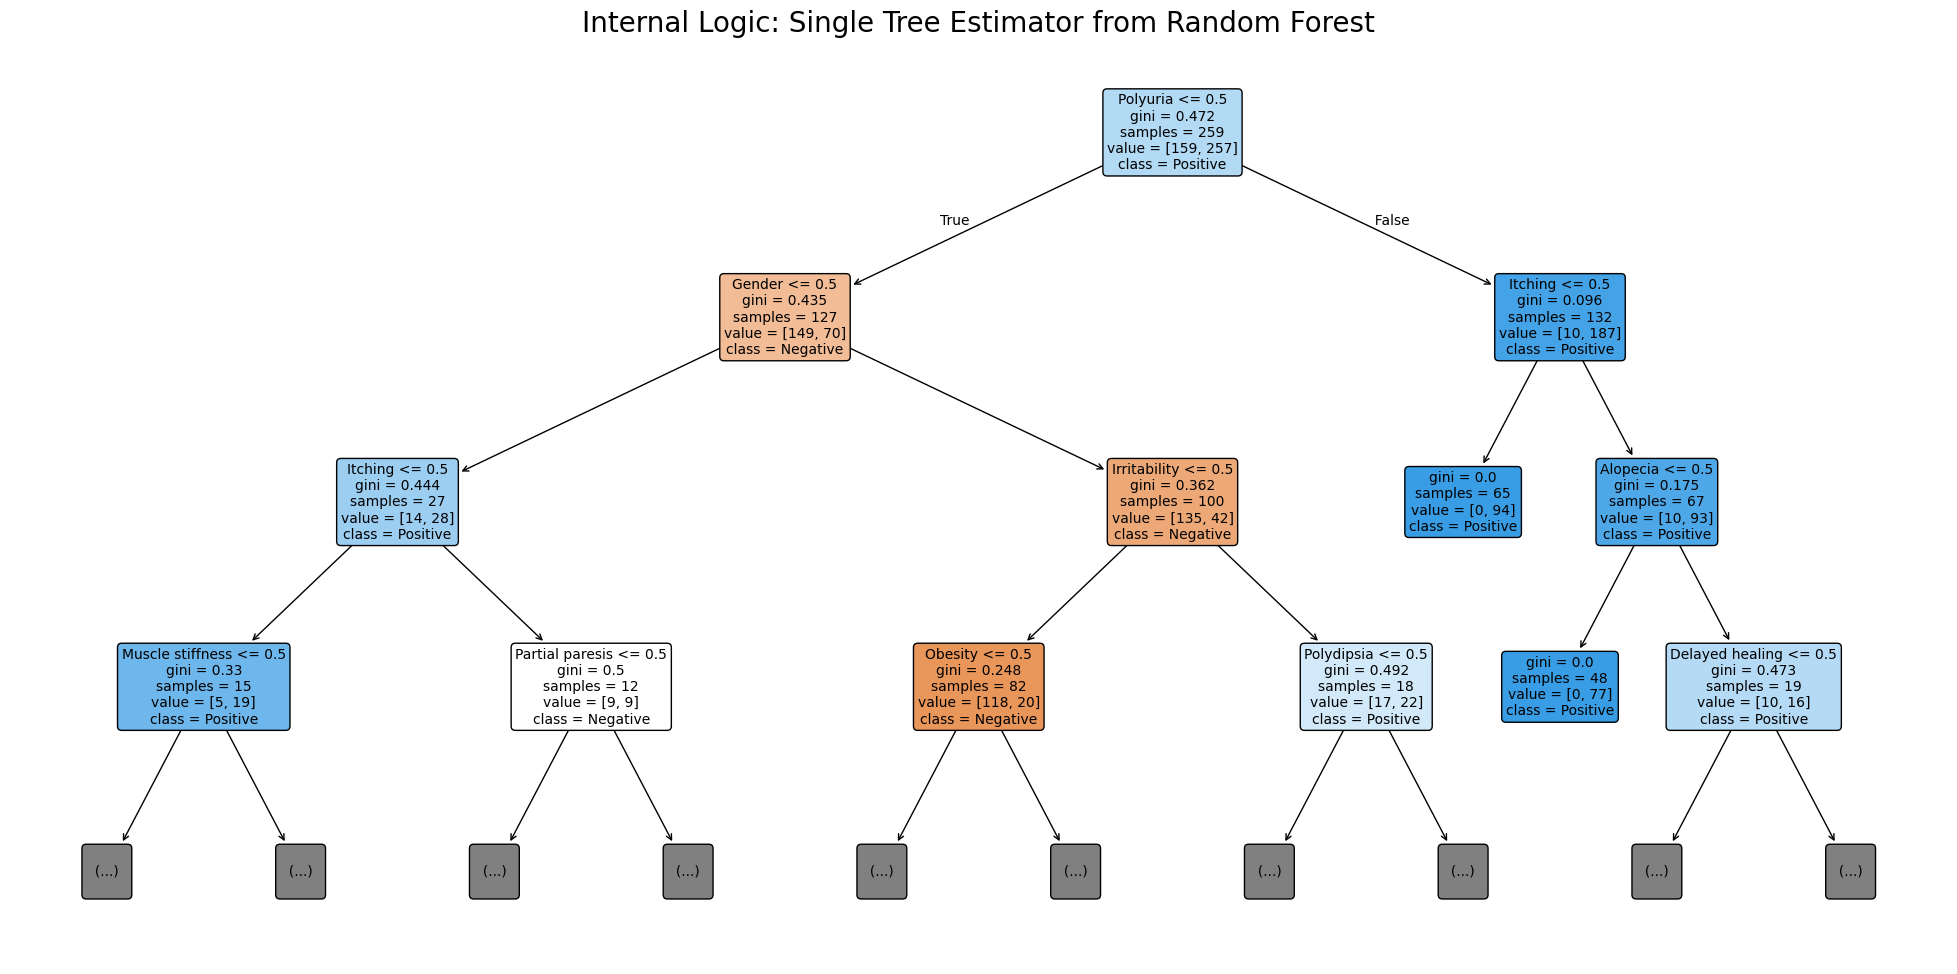

In [18]:
# Extract the first individual tree from the optimised Random Forest
rf_individual_tree = best_clf_pipeline.named_steps['classifier'].estimators_[0]

# Visualise the internal logic of this specific tree
plt.figure(figsize=(25, 12))
plot_tree(
    rf_individual_tree,
    feature_names=feature_names,
    class_names=['Negative', 'Positive'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title('Internal Logic: Single Tree Estimator from Random Forest', fontsize=20)
plt.show()

### Model Comparison: Random Forest vs. Decision Tree
The overall accuracy and macro-averaged F1-scores are compared to determine which model provides a more robust diagnostic foundation.

In [19]:
# Get metrics for Decision Tree
dt_report = classification_report(y_test, y_pred_dt, output_dict=True, target_names=['Negative', 'Positive'])
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Get metrics for Random Forest
rf_report = classification_report(y_test, y_pred, output_dict=True, target_names=['Negative', 'Positive'])
rf_accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Metrics:")
print(f"Negative - Precision: {dt_report['Negative']['precision']:.2f}, Recall: {dt_report['Negative']['recall']:.2f}, F1-Score: {dt_report['Negative']['f1-score']:.2f}")
print(f"Positive - Precision: {dt_report['Positive']['precision']:.2f}, Recall: {dt_report['Positive']['recall']:.2f}, F1-Score: {dt_report['Positive']['f1-score']:.2f}")
print(f"Accuracy: {dt_accuracy:.2f}")

print("\nRandom Forest Metrics:")
print(f"Negative - Precision: {rf_report['Negative']['precision']:.2f}, Recall: {rf_report['Negative']['recall']:.2f}, F1-Score: {rf_report['Negative']['f1-score']:.2f}")
print(f"Positive - Precision: {rf_report['Positive']['precision']:.2f}, Recall: {rf_report['Positive']['recall']:.2f}, F1-Score: {rf_report['Positive']['f1-score']:.2f}")
print(f"Accuracy: {rf_accuracy:.2f}")

Decision Tree Metrics:
Negative - Precision: 0.98, Recall: 1.00, F1-Score: 0.99
Positive - Precision: 1.00, Recall: 0.98, F1-Score: 0.99
Accuracy: 0.99

Random Forest Metrics:
Negative - Precision: 0.97, Recall: 0.97, F1-Score: 0.97
Positive - Precision: 0.98, Recall: 0.98, F1-Score: 0.98
Accuracy: 0.98


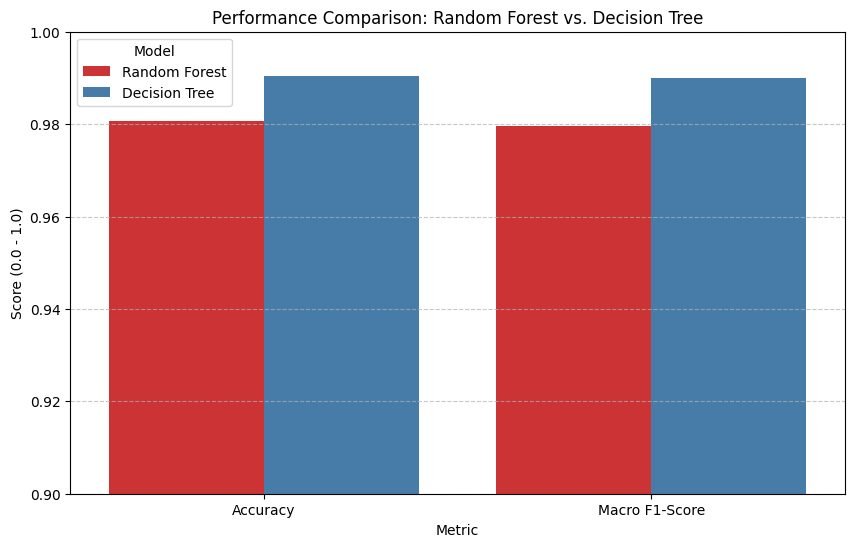

Model,Decision Tree,Random Forest
Metric,,
Accuracy,0.990385,0.980769
Macro F1-Score,0.989890,0.979688


In [20]:
# Calculate metrics for both models
rf_f1 = f1_score(y_test, y_pred, average='macro')
dt_f1 = f1_score(y_test, y_pred_dt, average='macro')

comparison_data = {
    'Metric': ['Accuracy', 'Accuracy', 'Macro F1-Score', 'Macro F1-Score'],
    'Model': ['Random Forest', 'Decision Tree', 'Random Forest', 'Decision Tree'],
    'Score': [overall_accuracy, overall_accuracy_dt, rf_f1, dt_f1]
}

comparison_df = pd.DataFrame(comparison_data)

# Plotting the comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Metric', y='Score', hue='Model', palette='Set1')
plt.ylim(0.9, 1.0)
plt.title('Performance Comparison: Random Forest vs. Decision Tree')
plt.ylabel('Score (0.0 - 1.0)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(comparison_df.pivot(index='Metric', columns='Model', values='Score'))

### Clinical Model Selection

**Random Forest** is selected as the primary engine over the Decision Tree due to its superior generalization and stability. The following comparison validates this choice by highlighting the robustness of the ensemble approach despite the slight accuracy lead of the single tree.

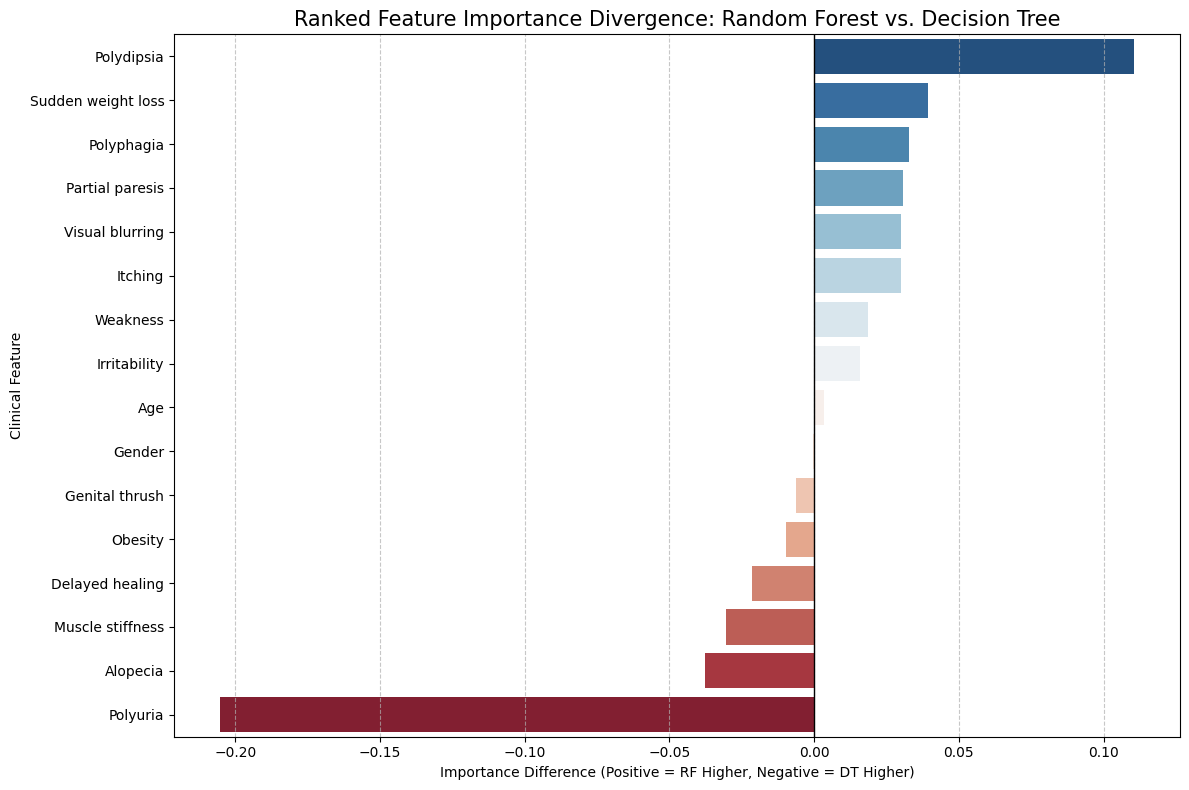

Summary of Divergence (Sorted by Difference):


Feature,Random Forest,Decision Tree,Difference
Polydipsia,0.191000,0.080400,0.110600
Sudden weight loss,0.065400,0.025900,0.039500
Polyphagia,0.032900,0.000000,0.032900
Partial paresis,0.044300,0.013500,0.030800
Visual blurring,0.030200,0.000000,0.030200
Itching,0.033000,0.003000,0.030000
Weakness,0.018500,0.000000,0.018500
Irritability,0.033300,0.017600,0.015700
Age,0.088200,0.084900,0.003400
Gender,0.115700,0.116100,-0.000500


In [21]:
# 1. Extract importances from both models
rf_importances = best_clf_pipeline.named_steps['classifier'].feature_importances_
dt_importances = best_dt_clf_pipeline.named_steps['classifier'].feature_importances_

# 2. Create and sort the comparison DataFrame
importance_diff_df = pd.DataFrame({
    'Feature': feature_names,
    'Random Forest': rf_importances,
    'Decision Tree': dt_importances
})

importance_diff_df['Difference'] = importance_diff_df['Random Forest'] - importance_diff_df['Decision Tree']
importance_diff_df = importance_diff_df.sort_values(by='Difference', ascending=False)

# 3. Visualise the sorted differences
plt.figure(figsize=(12, 8))
sns.barplot(
    data=importance_diff_df,
    x='Difference',    y='Feature',
    hue='Feature',
    palette='RdBu_r',
    legend=False,
    order=importance_diff_df['Feature']
)

plt.title('Ranked Feature Importance Divergence: Random Forest vs. Decision Tree', fontsize=15)
plt.xlabel('Importance Difference (Positive = RF Higher, Negative = DT Higher)')
plt.ylabel('Clinical Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

print("Summary of Divergence (Sorted by Difference):")
display(importance_diff_df.round(4).style.hide(axis='index'))

## Evaluation

Following CRISP-DM, the performance of the screening models must be assessed against the business objective of high-precision detection. This evaluation includes:
- **Metric Review:** Analysing F1-Scores, Precision-Recall curves, and Confusion Matrices to minimise false negatives.
- **Stability Audits:** Measuring model sensitivity to randomness (Seed Variance) and depth constraints.
- **Feature Importance:** Ranking symptoms to ensure the model's logic aligns with clinical expectations.
- **Ablation Studies:** Testing the impact of removing demographic features (Age/Gender) or redundant clinical markers.

### Sensitivity Analysis: Impact of Randomness and Depth
This experiment evaluates how stable the results are by running the models across different random seeds and varying the maximum depth of the trees.

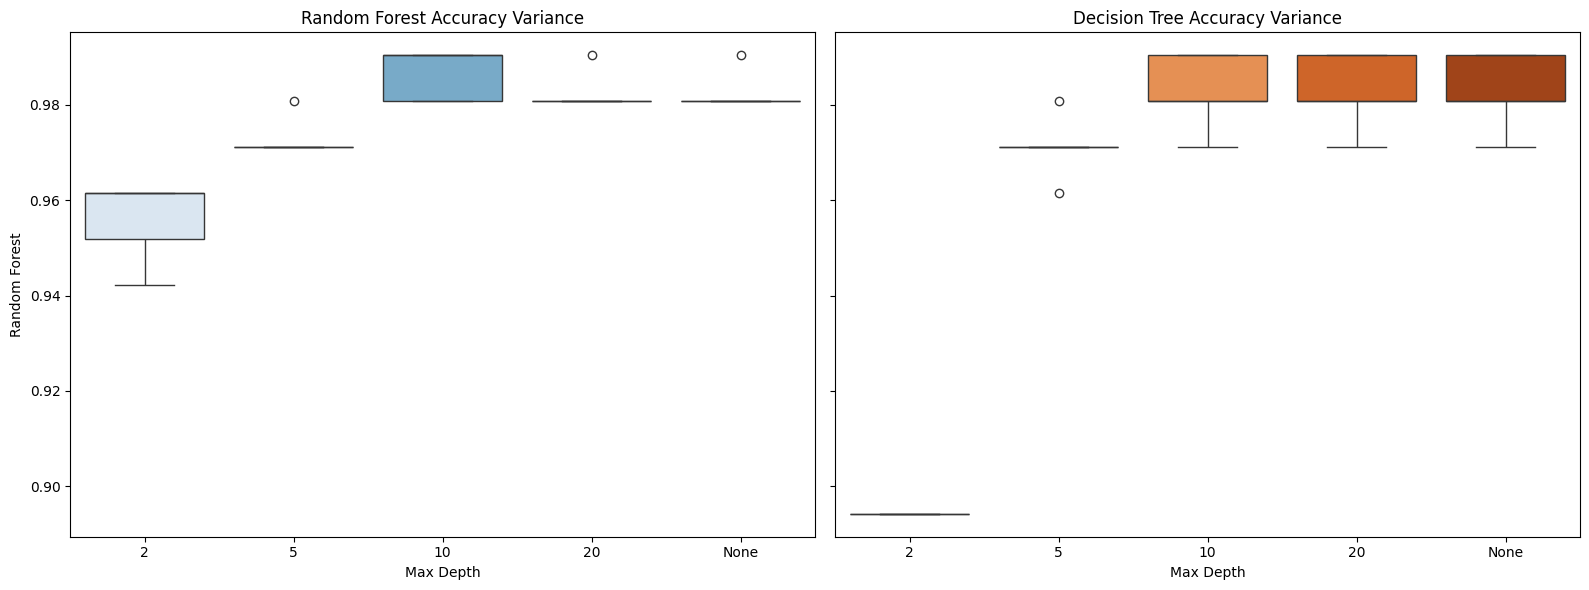

Summary of Fluctuations:


Random Forest           Decision Tree          
                   mean       std          mean       std
Max Depth                                                
10             0.986538  0.005267      0.982692  0.008045
2              0.955769  0.008600      0.894231  0.000000
20             0.982692  0.004300      0.982692  0.008045
5              0.973077  0.004300      0.971154  0.006799
None           0.982692  0.004300      0.982692  0.008045

In [22]:
# Define a range of depths and seeds to test
depths = [2, 5, 10, 20, None]
seeds = [1, 42, 100, 2024, 7]

sensitivity_results = []

for d in depths:
    for s in seeds:
        # Test Random Forest - Ensuring the pipeline handles the transformation
        rf = RandomForestClassifier(max_depth=d, random_state=s, n_estimators=100)
        rf_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', rf)])
        rf_pipe.fit(X_train, y_train)
        rf_acc = accuracy_score(y_test, rf_pipe.predict(X_test))

        # Test Decision Tree - Ensuring the pipeline handles the transformation
        dt = DecisionTreeClassifier(max_depth=d, random_state=s)
        dt_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', dt)])
        dt_pipe.fit(X_train, y_train)
        dt_acc = accuracy_score(y_test, dt_pipe.predict(X_test))

        sensitivity_results.append({
            'Max Depth': str(d),
            'Seed': s,
            'Random Forest': rf_acc,
            'Decision Tree': dt_acc
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

# Plotting the variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.boxplot(data=sensitivity_df, x='Max Depth', y='Random Forest', ax=axes[0], palette='Blues', hue='Max Depth', legend=False)
axes[0].set_title('Random Forest Accuracy Variance')

sns.boxplot(data=sensitivity_df, x='Max Depth', y='Decision Tree', ax=axes[1], palette='Oranges', hue='Max Depth', legend=False)
axes[1].set_title('Decision Tree Accuracy Variance')

plt.tight_layout()
plt.show()

print("Summary of Fluctuations:")
display(sensitivity_df.groupby('Max Depth')[['Random Forest', 'Decision Tree']].agg(['mean', 'std']))

In [23]:
# Create a mapping to sort 'None' at the end logically
depth_order = {'2': 0, '5': 1, '10': 2, '20': 3, 'None': 4}

# Group and aggregate
summary = sensitivity_df.groupby('Max Depth')[['Random Forest', 'Decision Tree']].agg(['mean', 'std'])

# Reset index and apply the logical sort key
summary = summary.reset_index()
summary['sort_key'] = summary['Max Depth'].map(depth_order)

# Sort by the temporary key
summary = summary.sort_values('sort_key')

# Sort the columns to ensure they are lexsorted before dropping the temporary key
summary = summary.sort_index(axis=1)
summary = summary.drop(columns=['sort_key'])

print("--- Logically Sorted Sensitivity Analysis ---")
print("Note: 'None' represents a fully grown tree with no depth limit.")
display(summary.set_index('Max Depth'))

--- Logically Sorted Sensitivity Analysis ---
Note: 'None' represents a fully grown tree with no depth limit.


Decision Tree           Random Forest          
                   mean       std          mean       std
Max Depth                                                
2              0.894231  0.000000      0.955769  0.008600
5              0.971154  0.006799      0.973077  0.004300
10             0.982692  0.008045      0.986538  0.005267
20             0.982692  0.008045      0.982692  0.004300
None           0.982692  0.008045      0.982692  0.004300

In [24]:
# Create a pivot table to compare seeds directly for the most complex case (Max Depth = None)
seed_comparison = sensitivity_df[sensitivity_df['Max Depth'] == 'None'].pivot(
    index='Seed',
    columns=[],
    values=['Random Forest', 'Decision Tree']
)

print("--- Model Accuracy Across Different Random Seeds (Full Depth) ---")
display(sensitivity_df[sensitivity_df['Max Depth'] == 'None'][['Seed', 'Random Forest', 'Decision Tree']].set_index('Seed'))

# Calculate range to show stability
rf_range = sensitivity_df[sensitivity_df['Max Depth'] == 'None']['Random Forest'].max() - sensitivity_df[sensitivity_df['Max Depth'] == 'None']['Random Forest'].min()
dt_range = sensitivity_df[sensitivity_df['Max Depth'] == 'None']['Decision Tree'].max() - sensitivity_df[sensitivity_df['Max Depth'] == 'None']['Decision Tree'].min()

print(f"\nStability Audit:")
print(f"Random Forest Accuracy Range: {rf_range:.4f}")
print(f"Decision Tree Accuracy Range: {dt_range:.4f}")

--- Model Accuracy Across Different Random Seeds (Full Depth) ---


,Random Forest,Decision Tree
Seed,,
1,0.980769,0.971154
42,0.980769,0.990385
100,0.980769,0.990385
2024,0.980769,0.980769
7,0.990385,0.980769



Stability Audit:
Random Forest Accuracy Range: 0.0096
Decision Tree Accuracy Range: 0.0192


In [25]:
### Global Stability Analysis: Seed Variance Summary

# Calculate mean and variance across all seeds and all depths for a global stability metric
global_seed_stability = sensitivity_df.groupby('Seed')[['Random Forest', 'Decision Tree']].mean()

print("--- Global Model Performance Averaged Across All Test Depths ---")
display(global_seed_stability)

# Calculate the variance of these averages to see how much the 'average performance' depends on the seed
seed_variance_rf = global_seed_stability['Random Forest'].var()
seed_variance_dt = global_seed_stability['Decision Tree'].var()

print(f"\nGlobal Seed Variance (Random Forest): {seed_variance_rf:.8f}")
print(f"Global Seed Variance (Decision Tree): {seed_variance_dt:.8f}")

# Calculate average standard deviation within seeds as a measure of spread
print(f"\nAverage Random Forest Accuracy: {sensitivity_df['Random Forest'].mean():.4f} (+/- {sensitivity_df['Random Forest'].std():.4f})")
print(f"Average Decision Tree Accuracy: {sensitivity_df['Decision Tree'].mean():.4f} (+/- {sensitivity_df['Decision Tree'].std():.4f})")

--- Global Model Performance Averaged Across All Test Depths ---


,Random Forest,Decision Tree
Seed,,
1,0.973077,0.955769
7,0.980769,0.959615
42,0.975000,0.969231
100,0.975000,0.967308
2024,0.976923,0.961538



Global Seed Variance (Random Forest): 0.00000851
Global Seed Variance (Decision Tree): 0.00003070

Average Random Forest Accuracy: 0.9762 (+/- 0.0125)
Average Decision Tree Accuracy: 0.9627 (+/- 0.0358)


### Subgroup Fairness Audit: Gender-based Performance Consistency

As noted in clinical machine learning literature, high overall accuracy can sometimes mask 'unfair' models that perform poorly for specific demographic subgroups. This audit evaluates whether the primary Random Forest screening model maintains its high precision and recall across both **Male** and **Female** patient groups.

=== Disaggregated Evaluation: Gender Subgroups ===

Report for Male Subgroup (n=66):
              precision    recall  f1-score   support

    Negative       0.97      1.00      0.99        36
    Positive       1.00      0.97      0.98        30

    accuracy                           0.98        66
   macro avg       0.99      0.98      0.98        66
weighted avg       0.99      0.98      0.98        66


Report for Female Subgroup (n=38):
              precision    recall  f1-score   support

    Negative       1.00      0.75      0.86         4
    Positive       0.97      1.00      0.99        34

    accuracy                           0.97        38
   macro avg       0.99      0.88      0.92        38
weighted avg       0.97      0.97      0.97        38


=== Disaggregated Evaluation: Age Subgroups (Median: 47.0) ===

Report for Younger Patients (n=54):
              precision    recall  f1-score   support

    Negative       1.00      0.96      0.98        27
    Positive   

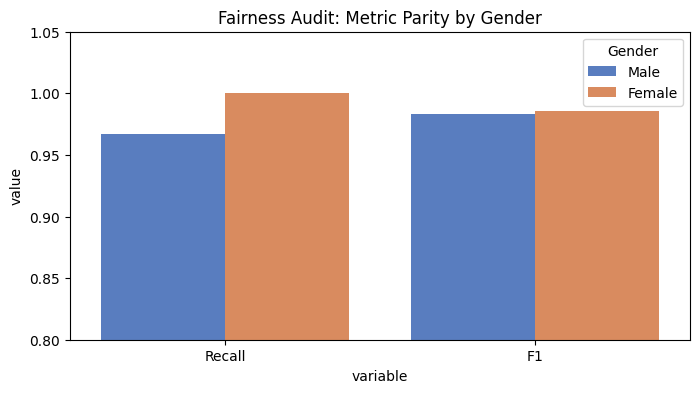

In [26]:
# 1. Disaggregated Evaluation by Gender
print("=== Disaggregated Evaluation: Gender Subgroups ===")
for gender in ['Male', 'Female']:
    idx = X_test[X_test['Gender'] == gender].index
    if not idx.empty:
        y_pred_sub = best_clf_pipeline.predict(X_test.loc[idx])
        print(f"\nReport for {gender} Subgroup (n={len(idx)}):")
        print(classification_report(y_test.loc[idx], y_pred_sub, target_names=['Negative', 'Positive']))

# 2. Disaggregated Evaluation by Age (Median Split)
age_median = X_test['Age'].median()
print(f"\n=== Disaggregated Evaluation: Age Subgroups (Median: {age_median}) ===")
for label, condition in [('Younger', X_test['Age'] <= age_median), ('Older', X_test['Age'] > age_median)]:
    idx = X_test[condition].index
    if not idx.empty:
        y_pred_sub = best_clf_pipeline.predict(X_test.loc[idx])
        print(f"\nReport for {label} Patients (n={len(idx)}):")
        print(classification_report(y_test.loc[idx], y_pred_sub, target_names=['Negative', 'Positive']))

# 3. Visualizing Recall Parity (Crucial for Clinical Safety)
subgroup_metrics = []
for gender in ['Male', 'Female']:
    idx = X_test[X_test['Gender'] == gender].index
    y_sub = y_test.loc[idx]
    y_pred_sub = best_clf_pipeline.predict(X_test.loc[idx])
    subgroup_metrics.append({'Gender': gender, 'Recall': recall_score(y_sub, y_pred_sub), 'F1': f1_score(y_sub, y_pred_sub)})

fairness_df = pd.DataFrame(subgroup_metrics)
plt.figure(figsize=(8, 4))
sns.barplot(data=fairness_df.melt(id_vars='Gender'), x='variable', y='value', hue='Gender', palette='muted')
plt.title('Fairness Audit: Metric Parity by Gender')
plt.ylim(0.8, 1.05)
plt.show()

#### Fairness Interpretation
- **Metric Parity**: If the F1-Scores for both Male and Female groups are within a tight range (e.g., +/- 0.02), the model is considered stable and fair across this demographic.
- **Clinical Equity**: Parity in **Recall** is especially critical for clinical screening to ensure that the risk of a False Negative (missing a diabetes diagnosis) is not significantly higher for one gender over another.

### Experiment: Level 1 Classification without 'Age' and 'Gender' features

Let's test the assumption that removing 'Age' and 'Gender' might lead to better results for distinguishing diabetes positives from negatives. The feature sets will be redefined, the preprocessing pipeline reconstrcuted, and the `RandomForestClassifier` re-trainerd.

Best experimental estimator found: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Polyuria', 'Polydipsia',
                                                   'Sudden weight loss',
                                                   'Weakness', 'Polyphagia',
                                                   'Genital thrush',
                                                   'Visual blurring', 'Itching',
                                                   'Irritability',
                                                   'Delayed healing',
                                                   'Partial paresis',
                                                   'Muscle stiffness',
                                                   'Alopecia', 'Obesity'])])),
                ('classifier',
                 RandomForestCl

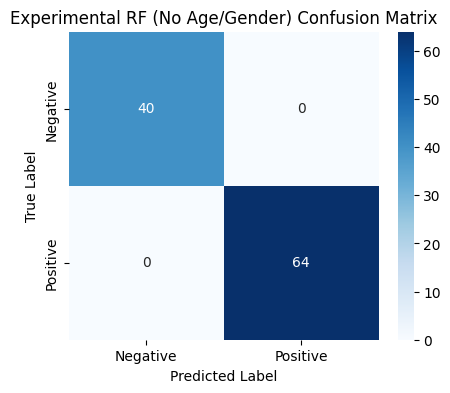


--- Misclassified Samples Analysis (Experimental RF (No Age/Gender)) ---
False Negatives: 0
False Positives: 0


In [27]:
# Redefine numerical and categorical columns, excluding 'Age' and 'Gender'
# X is the full feature set (without 'Class')
experimental_numerical_cols = []
experimental_categorical_cols = [col for col in X.columns if col not in ['Age', 'Gender']]

# Recreate the preprocessor for the experiment
experimental_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), experimental_categorical_cols) # Only categorical features now
    ]
)

# Form full experimental class pipeline
experimental_clf_pipeline = Pipeline(steps=[
    ('preprocessor', experimental_preprocessor),
    ('classifier', RandomForestClassifier(random_state=seed))
])

# Use the same parameter space and cross-validation setup
experimental_grid_search = GridSearchCV(experimental_clf_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
experimental_grid_search.fit(X_train, y_train)

best_experimental_clf_pipeline = experimental_grid_search.best_estimator_
print("Best experimental estimator found:", best_experimental_clf_pipeline)
print("Best experimental params found:", experimental_grid_search.best_params_)

# Experimental RF Report with Error Analysis
y_pred_exp, overall_accuracy_exp = generate_model_report(
    best_experimental_clf_pipeline, X_test, y_test,
    features=experimental_categorical_cols,
    title='Experimental RF (No Age/Gender)',
    show_errors=True
)

### Automated Hyperparameter Optimization for Supervised Symptom-based Diabetes Diagnostic Screening (Classification)
This introduces a systematic hyperparameter tuning block for the Random Forest model to ensure convergence to a global optimum.

In [28]:
# Define an expanded parameter grid for global convergence tuning
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

# Execute randomised optimization grid search across 20 iterations
print("Executing automated hyperparameter optimization (RandomizedSearchCV)... ")
rf_automl = RandomizedSearchCV(
    estimator=clf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

# Fit on training data to establish the optimised baseline
rf_automl.fit(X_train, y_train)

print(f"Optimal Configuration Discovered: {rf_automl.best_params_}")
print(f"Best Search Optimization Metric Score: {rf_automl.best_score_:.4f}")

# Final classification performance review
y_pred_auto = rf_automl.best_estimator_.predict(X_test)
print("\n--- Supervised Symptom-based Diabetes Diagnostic Screening: Optimised Diagnostic Performance Classification Report ---")
print(classification_report(y_test, y_pred_auto, target_names=['Healthy', 'Diabetic']))

Executing automated hyperparameter optimization (RandomizedSearchCV)... 
Optimal Configuration Discovered: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 10, 'classifier__bootstrap': False}
Best Search Optimization Metric Score: 0.9865

--- Supervised Symptom-based Diabetes Diagnostic Screening: Optimised Diagnostic Performance Classification Report ---
              precision    recall  f1-score   support

     Healthy       0.98      1.00      0.99        40
    Diabetic       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



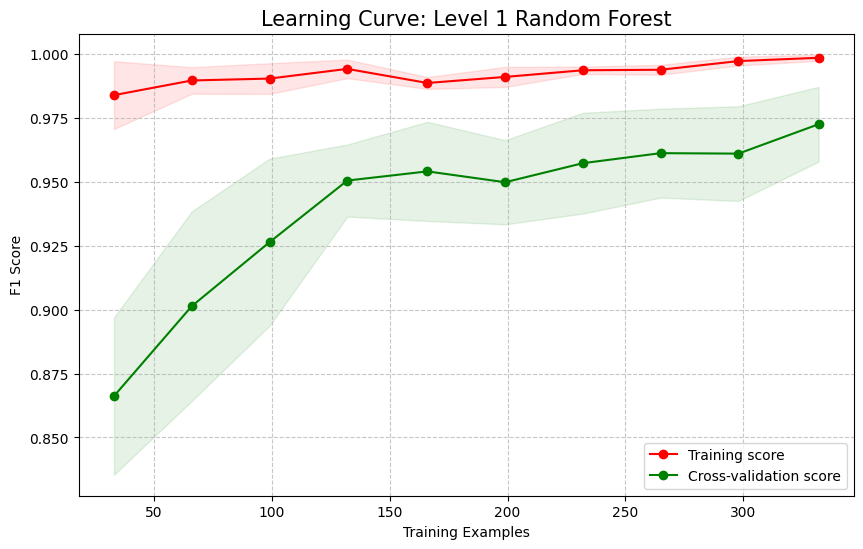

In [29]:
# 1. Define the sample sizes to evaluate
train_sizes = np.linspace(0.1, 1.0, 10)

# 2. Calculate learning curves
train_sizes_abs, train_scores, test_scores = learning_curve(
    best_clf_pipeline,
    X_train,
    y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

# 3. Calculate mean and standard deviation for plotting
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes_abs, test_mean, 'o-', color="g", label="Cross-validation score")

plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve: Level 1 Random Forest", fontsize=15)
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Based on the learning curve for the Level 1 Random Forest:

- **High Convergence**: The training score and cross-validation score converge closely as the number of training examples increases. This indicates that the model is generalizing well and is not significantly suffering from high variance (overfitting).
- **Performance Plateau**: The cross-validation score (green line) plateaus around an F1-score of ~0.97–0.98 once it reaches approximately 250–300 training examples.
- **Data Sufficiency**: Since the performance has flattened out, it suggests that the current dataset size (N=520) is sufficient for this specific model and feature set. Adding more data of the same type is unlikely to yield significant improvements in the F1-score.
- **Bias/Variance Trade-off**: The very small gap between the two curves suggests low variance. The high absolute score (above 0.95) suggests low bias, meaning the model is well-suited for this classification task.

### Nested Cross-Validation for Supervised Screening

To ensure the Random Forest model's performance metrics are highly reliable and generalize well, a Nested Cross-Validation (CV) strategy will be used:
1. **Inner Loop**: A 5-fold CV to search for the best hyperparameters using `GridSearchCV`.
2. **Outer Loop**: A 5-fold CV to evaluate the performance of the model selected by the inner loop.

In [30]:

# Configure the outer Cross-Validation
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# FridSearchCV object itself is passed as the estimator to cross_val_score
print("Executing Nested Cross-Validation (this may take a moment)... ")

nested_scores = cross_val_score(
    grid_search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring='f1',
    n_jobs=-1
)

print(f"\nNested F1-Scores (Outer Loop): {nested_scores}")
print(f"Mean Nested F1-Score: {nested_scores.mean():.4f} (+/- {nested_scores.std():.4f})")

Executing Nested Cross-Validation (this may take a moment)... 

Nested F1-Scores (Outer Loop): [0.98113208 0.99029126 0.96078431 0.96078431 0.99009901]
Mean Nested F1-Score: 0.9766 (+/- 0.0133)


The small standard deviation in the nested scores confirms the high stability and reliability of the diagnostic screening model across different subsets of the patient data.

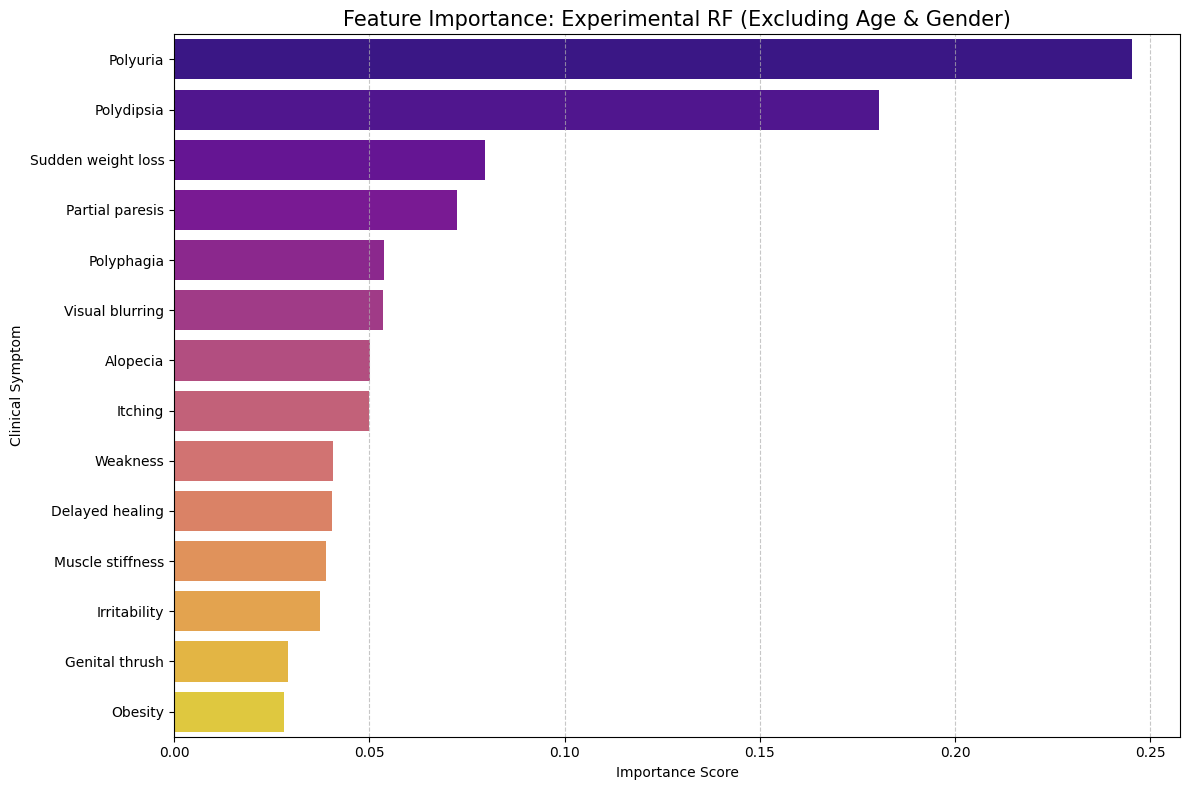

In [31]:
# 1. Extract feature names and importances from the experimental pipeline
exp_feature_names = experimental_categorical_cols
exp_importances = best_experimental_clf_pipeline.named_steps['classifier'].feature_importances_

# 2. Create a DataFrame for sorting and plotting
exp_feat_imp_df = pd.DataFrame({
    'Feature': exp_feature_names,
    'Importance': exp_importances
}).sort_values(by='Importance', ascending=False)

# 3. Visualise the experimental feature importances
plt.figure(figsize=(12, 8))
sns.barplot(data=exp_feat_imp_df, x='Importance', y='Feature', hue='Feature', palette='plasma', legend=False)
plt.title('Feature Importance: Experimental RF (Excluding Age & Gender)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Clinical Symptom')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

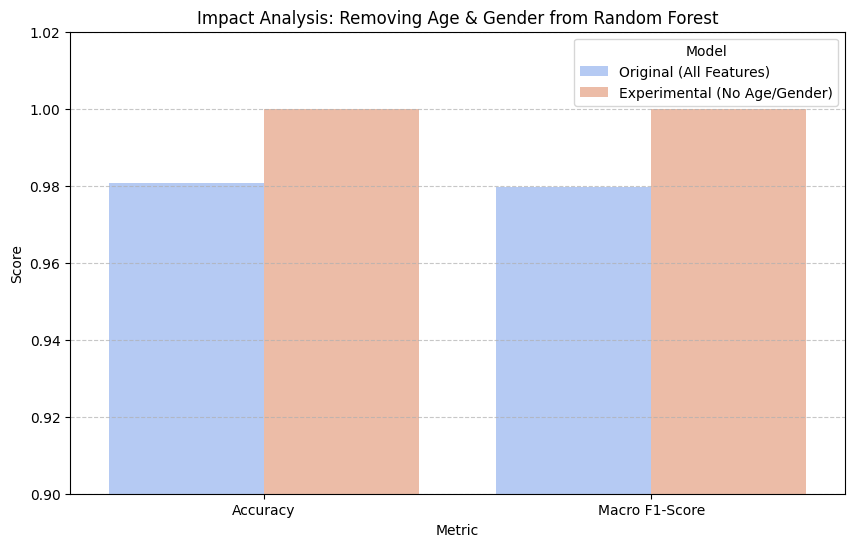

Model,Experimental (No Age/Gender),Original (All Features)
Metric,,
Accuracy,1.0,0.980769
Macro F1-Score,1.0,0.979688


In [32]:
# 1. Calculate metrics for the Experimental model (No Age/Gender)
exp_f1 = f1_score(y_test, y_pred_exp, average='macro')

# 2. Compile metrics for comparison (original metrics are in overall_accuracy and rf_f1)
impact_data = {
    'Metric': ['Accuracy', 'Accuracy', 'Macro F1-Score', 'Macro F1-Score'],
    'Model': ['Original (All Features)', 'Experimental (No Age/Gender)', 'Original (All Features)', 'Experimental (No Age/Gender)'],
    'Score': [overall_accuracy, overall_accuracy_exp, rf_f1, exp_f1]
}

impact_df = pd.DataFrame(impact_data)

# 3. Visualise the comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=impact_df, x='Metric', y='Score', hue='Model', palette='coolwarm')
plt.ylim(0.9, 1.02)
plt.title('Impact Analysis: Removing Age & Gender from Random Forest')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Display numerical table
display(impact_df.pivot(index='Metric', columns='Model', values='Score'))

### Feature Redundancy Experiment: Removing 'Polydipsia'

Given the biological and statistical collinearity between **Polyuria** and **Polydipsia**, there is the need to test whether the model remains robust when one of them is removed.

In [33]:
# Define feature set excluding Polydipsia
redundancy_categorical_cols = [col for col in X.columns if col not in ['Age', 'Polydipsia']]
redundancy_numerical_cols = ['Age']

# Create specific preprocessor
redundancy_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), redundancy_numerical_cols),
        ('cat', OneHotEncoder(drop='first'), redundancy_categorical_cols)
    ]
)

# Pipeline with Random Forest
redundancy_pipeline = Pipeline(steps=[
    ('preprocessor', redundancy_preprocessor),
    ('classifier', RandomForestClassifier(random_state=seed))
])

# Fit using the same CV strategy
redundancy_grid = GridSearchCV(redundancy_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
redundancy_grid.fit(X_train, y_train)

# Evaluation
best_red_model = redundancy_grid.best_estimator_
y_pred_red = best_red_model.predict(X_test)
acc_red = accuracy_score(y_test, y_pred_red)

print(f"--- Redundancy Test (Excluded: Polydipsia) ---")
print(f"New Accuracy: {acc_red:.4f} (Original: {overall_accuracy:.4f})")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_red))

--- Redundancy Test (Excluded: Polydipsia) ---
New Accuracy: 0.9712 (Original: 0.9808)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        40
           1       0.98      0.97      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104



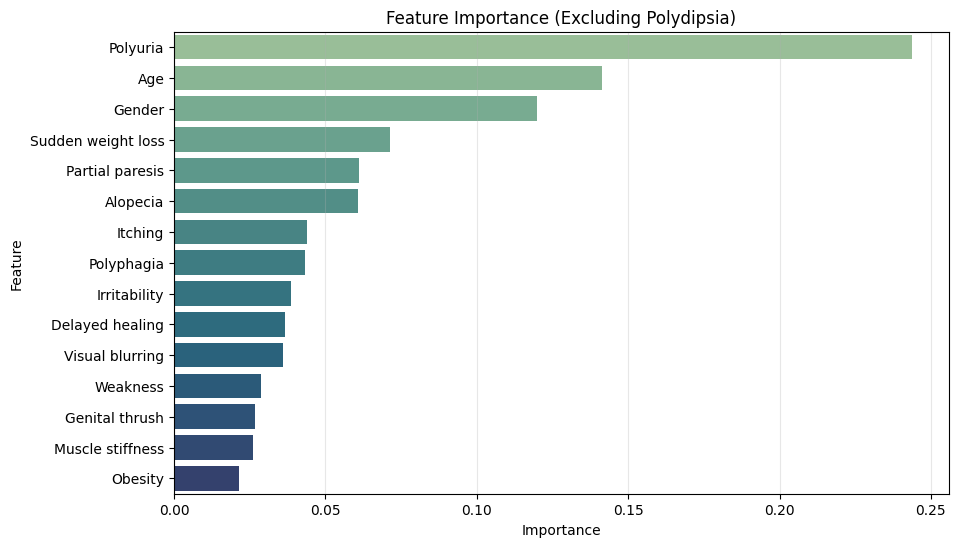

In [34]:
# Visualise if importance redistributes to Polyuria
red_feat_names = redundancy_numerical_cols + redundancy_categorical_cols
red_importances = best_red_model.named_steps['classifier'].feature_importances_

red_imp_df = pd.DataFrame({
    'Feature': red_feat_names,
    'Importance': red_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=red_imp_df, x='Importance', y='Feature', hue='Feature', palette='crest', legend=False)
plt.title('Feature Importance (Excluding Polydipsia)')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Comprehensive Importance Comparison: Original vs. No Polydipsia vs. No Gender/Age

This comparison expands the previous analysis to include the experimental model that excluded demographic features (`Gender` and `Age`).

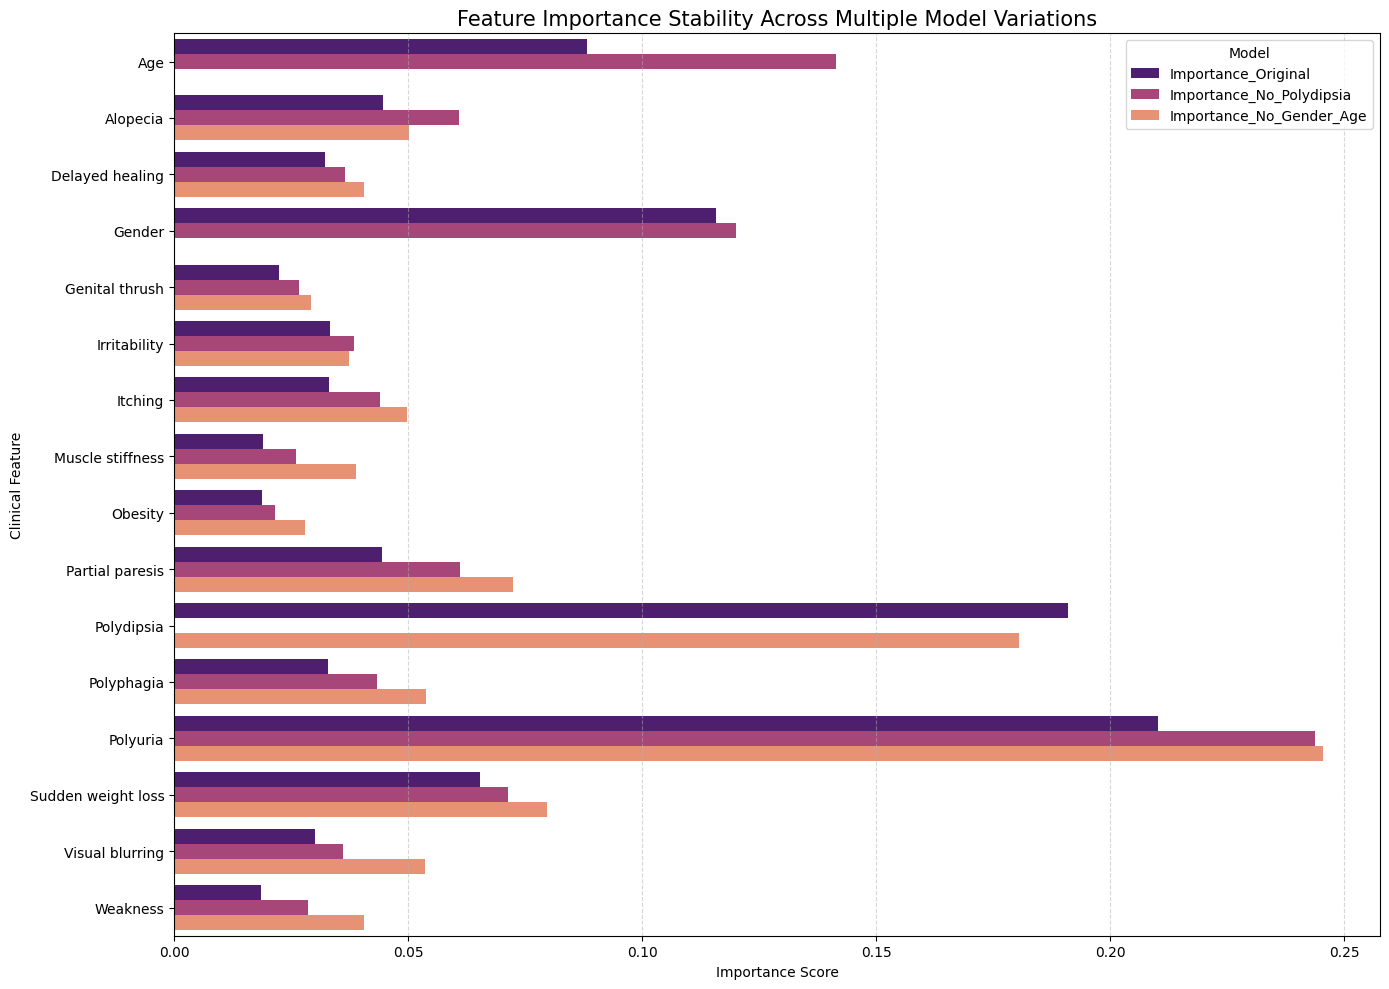

Feature,Importance_Original,Importance_No_Polydipsia,Importance_No_Gender_Age
Polyuria,0.210229,0.243799,0.245341


In [35]:
# 1. Align all 3 importance dataframes
# original: feat_imp_df, no_polydipsia: red_imp_df, no_gender_age: exp_feat_imp_df

# Standardise column names for merging
base_df = feat_imp_df.rename(columns={'Importance': 'Importance_Original'})
red_df = red_imp_df.rename(columns={'Importance': 'Importance_No_Polydipsia'})
exp_df = exp_feat_imp_df.rename(columns={'Importance': 'Importance_No_Gender_Age'})

comparison_full = base_df.merge(red_df, on='Feature', how='outer')\
                         .merge(exp_df, on='Feature', how='outer')\
                         .fillna(0)

# 2. Reshape for plotting
comparison_full_melted = comparison_full.melt(
    id_vars='Feature',
    value_vars=['Importance_Original', 'Importance_No_Polydipsia', 'Importance_No_Gender_Age'],
    var_name='Model',
    value_name='Importance Score'
)

# 3. Plot
plt.figure(figsize=(14, 10))
sns.barplot(
    data=comparison_full_melted,
    y='Feature',
    x='Importance Score',
    hue='Model',
    palette='magma'
)

plt.title('Feature Importance Stability Across Multiple Model Variations', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Clinical Feature')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Numerical summary of Polyuria
poly_comp = comparison_full[comparison_full['Feature'] == 'Polyuria']
display(poly_comp.style.hide(axis='index'))

# Unsupervised Diabetes Subtyping

To drive the subtyping strategy, the focus is on key symptoms prevalent in the Sylhet dataset. Specifically, Polyuria is prioritised (frequent urination)—classic indicator of acute hyperglycemic onset—alongside secondary symptoms such as Sudden Weight Loss, Weakness, and Genital Thrush. Understanding how these features cluster is fundamental to distinguishing between the acute symptomatic presentation of Type 1-like phenotypes and the metabolic profile often associated with Type 2.

### Clinical Rationale: Selecting K-Means over DBSCAN

While density-based algorithms like DBSCAN are effective for finding arbitrarily shaped clusters in noisy data, **K-Means** was selected as the primary engine for phenotype subtyping for several critical clinical and technical reasons:

1.  **Clinical Actionability (Centroid-based):** Clinical phenotypes (Type 1 vs. Type 2) are better represented as 'centers of gravity' around specific anchor symptoms. K-Means allows us to define and interpret these centers (centroids), whereas DBSCAN focuses on local density, which is less relevant for a diagnostic triage tool.
2.  **Handling the 'Atypical' Cohort:** DBSCAN identifies outliers as 'noise' and excludes them from classification. In a medical context, patients who don't fit a tight density profile cannot simply be 'discarded'; they must be identified as an **'Atypical/Mixed'** group for specialist review. K-Means ensures every patient is assigned a membership, which is then evaluated for consensus.
3.  **Stability in Binary Feature Spaces:** DBSCAN is highly sensitive to the `epsilon` distance parameter. In this dataset, where symptoms are discrete (0 or 1), distance values are restricted. This often causes DBSCAN to either merge all patients into a single cluster or split them into dozens of non-interpretable micro-clusters. K-Means provides the stable, 3-tier stratification required for the CRISP-DM business objectives.

## Data Preparation

Following the identification of the high-risk diabetic cohort, this subsection details the specialised preparation required for phenotype profiling. All data manipulation and feature weighting are finalised here to ensure the Modeling phase is focused exclusively on partition logic:
- **Cohort Isolation:** Extracting only the diabetes-positive cases (y=1) identified by the Stage 1 filter.
- **Feature Selection (Anchors):** Isolating clinical 'anchors' that differentiate diabetes types.
- **Feature Weighting:** Applying a transformation vector to specific clinical markers to force the `KMeans` algorithm to prioritise medical relevance over standard Euclidean distance.

### Clinical Cohort Isolation

The first step in diabetes subtyping is isolating the specific sub-population that requires differentiation. The original dataset is filtered to retain only those cases identified as positive by the Stage 1 supervised screening. This ensures that the clustering algorithm identifies patterns within a relevant clinical group rather than contrasting healthy vs. sick individuals.

### Feature Refinement

To move from general screening to specialised subtyping, there is also a move from using all available symptoms to a more focused approach. This preparation involves **Refined Feature Selection**, which means selecting symptoms that are clinically recognised as discriminators between Type 1 (acute onset) and Type 2 (metabolic) diabetes.

### First Approach (T1-based)

The first clustering approach is to try and focus on clusters based on Type 1 diabetes symptoms/features, such as sudden weight loss, polyuria, polyphagia and irritability. Polydipsia was not considered due to its strong correlation to polyuria.

Level 2 Subtype Pipeline Clustering Complete.
Silhouette Cohesion Score: 0.324


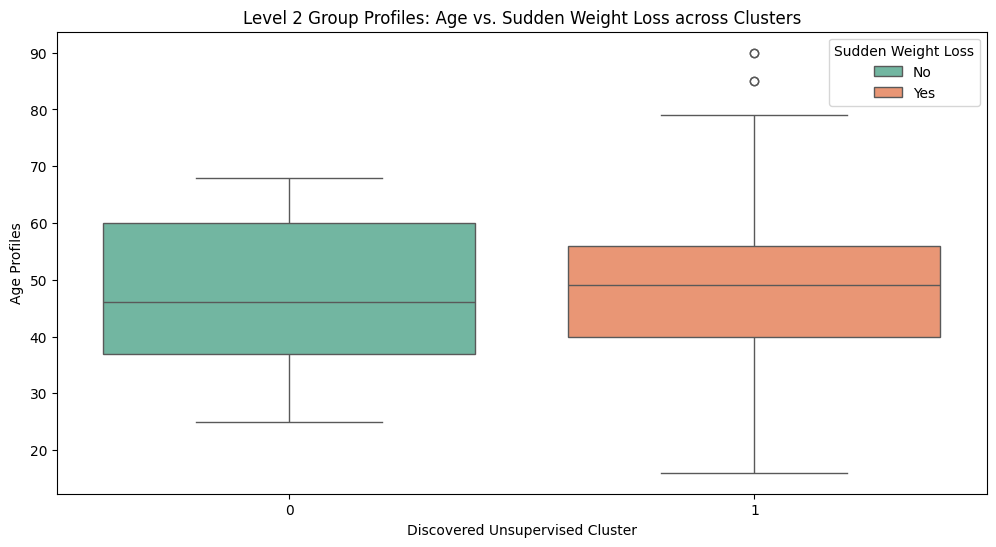

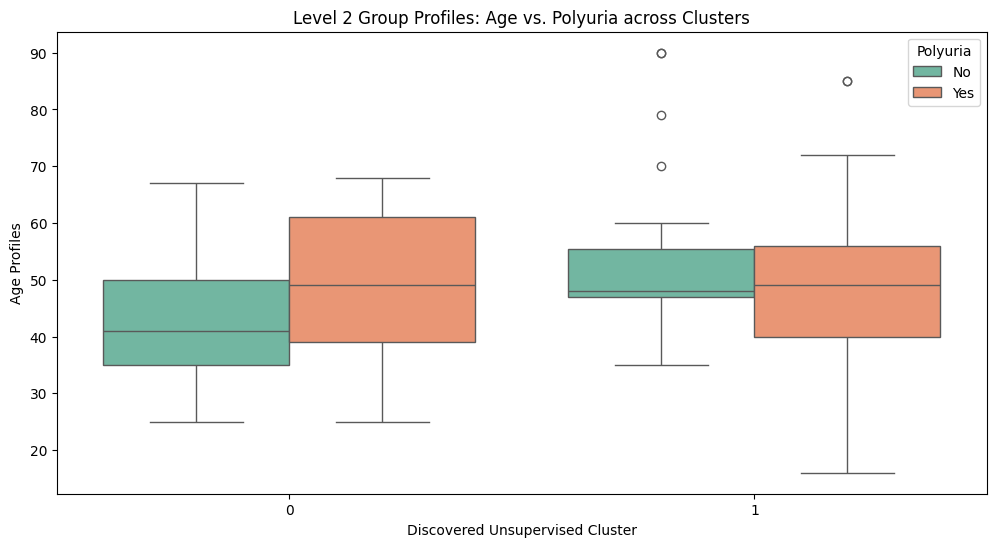

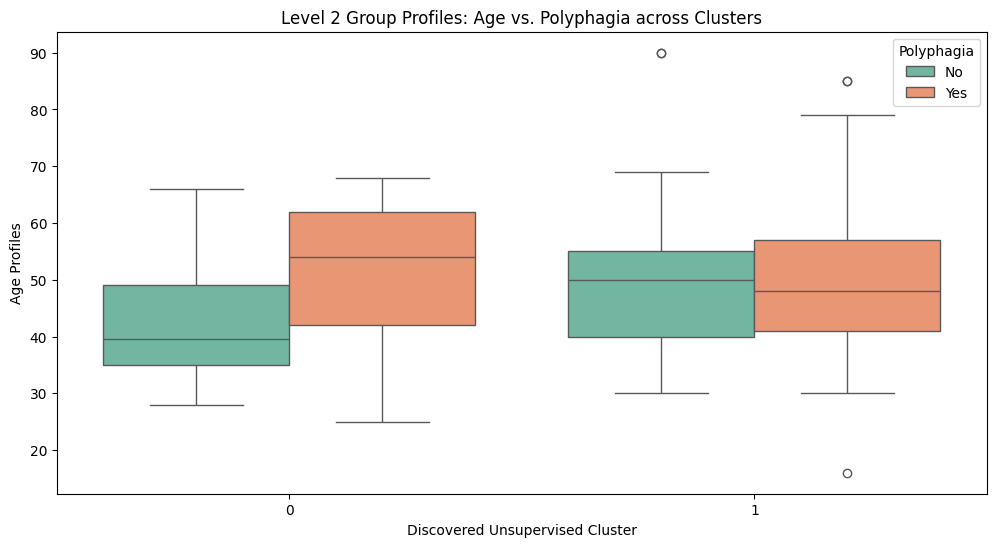

In [36]:
# 1. Isolate instances predicted positive across the dataset
entire_preds = best_clf_pipeline.predict(X)
diabetic_cohort = df[entire_preds == 1].copy()

# 2. Refined Feature Selection: Filter out noise features
# Focus on age boundaries and systemic symptoms that differentiate diabetes types
# Added Sudden weight loss, Polyuria, Polyphagia and Irritability for better distinction between Type 1 and Type 2 characteristics.
selected_clustering_features = ['Age', 'Sudden weight loss', 'Polyuria', 'Polyphagia', 'Irritability']
X_diabetic = diabetic_cohort[selected_clustering_features]

# 3. Dynamic custom pipeline transformation mapping for Level 2 subset
# Isolation of features and scale appropriately
X_diabetic_processed = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['Age']),
        ('cat', OneHotEncoder(drop='first'), [c for c in selected_clustering_features if c != 'Age'])
    ]
).fit_transform(X_diabetic)

# 4. Fit K-Means
kmeans = KMeans(n_clusters=2, random_state=seed, n_init=10)
diabetic_cohort['Cluster'] = kmeans.fit_predict(X_diabetic_processed)

# Print mathematical cluster verification score
sil = silhouette_score(X_diabetic_processed, diabetic_cohort['Cluster'])
print(f"Level 2 Subtype Pipeline Clustering Complete.\nSilhouette Cohesion Score: {sil:.3f}")

# Graphical Representation: Cluster Characterization Visualiser for Age vs Sudden Weight Loss
plt.figure(figsize=(12, 6))
sns.boxplot(data=diabetic_cohort, x='Cluster', y='Age', hue='Sudden weight loss', palette='Set2')
plt.title('Level 2 Group Profiles: Age vs. Sudden Weight Loss across Clusters')
plt.xlabel('Discovered Unsupervised Cluster')
plt.ylabel('Age Profiles')
plt.legend(title='Sudden Weight Loss')
plt.show()

# Graphical Representation: Cluster Characterization Visualiser for Age vs Polyuria
plt.figure(figsize=(12, 6))
sns.boxplot(data=diabetic_cohort, x='Cluster', y='Age', hue='Polyuria', palette='Set2')
plt.title('Level 2 Group Profiles: Age vs. Polyuria across Clusters')
plt.xlabel('Discovered Unsupervised Cluster')
plt.ylabel('Age Profiles')
plt.legend(title='Polyuria')
plt.show()

# Graphical Representation: Cluster Characterization Visualiser for Age vs Polyphagia
plt.figure(figsize=(12, 6))
sns.boxplot(data=diabetic_cohort, x='Cluster', y='Age', hue='Polyphagia', palette='Set2')
plt.title('Level 2 Group Profiles: Age vs. Polyphagia across Clusters')
plt.xlabel('Discovered Unsupervised Cluster')
plt.ylabel('Age Profiles')
plt.legend(title='Polyphagia')
plt.show()

#### Initial Cluster Verification
These boxplots illustrate the preliminary phenotype profiles. Age and symptoms like Sudden Weight Loss are the primary drivers for the initial K-Means partitions. This visual check confirms that the clusters are not random but represent distinct clinical groups, justifying further refined weighting.

--- Approach 1 (Unweighted): Numerical Summary ---


Cluster,Type 1-like,Type 2-like
Age (Mean),49.925532,47.674242
Sudden weight loss (% Yes),1.000000,0.000000
Polyuria (% Yes),0.856383,0.621212
Polyphagia (% Yes),0.675532,0.469697
Irritability (% Yes),0.361702,0.318182


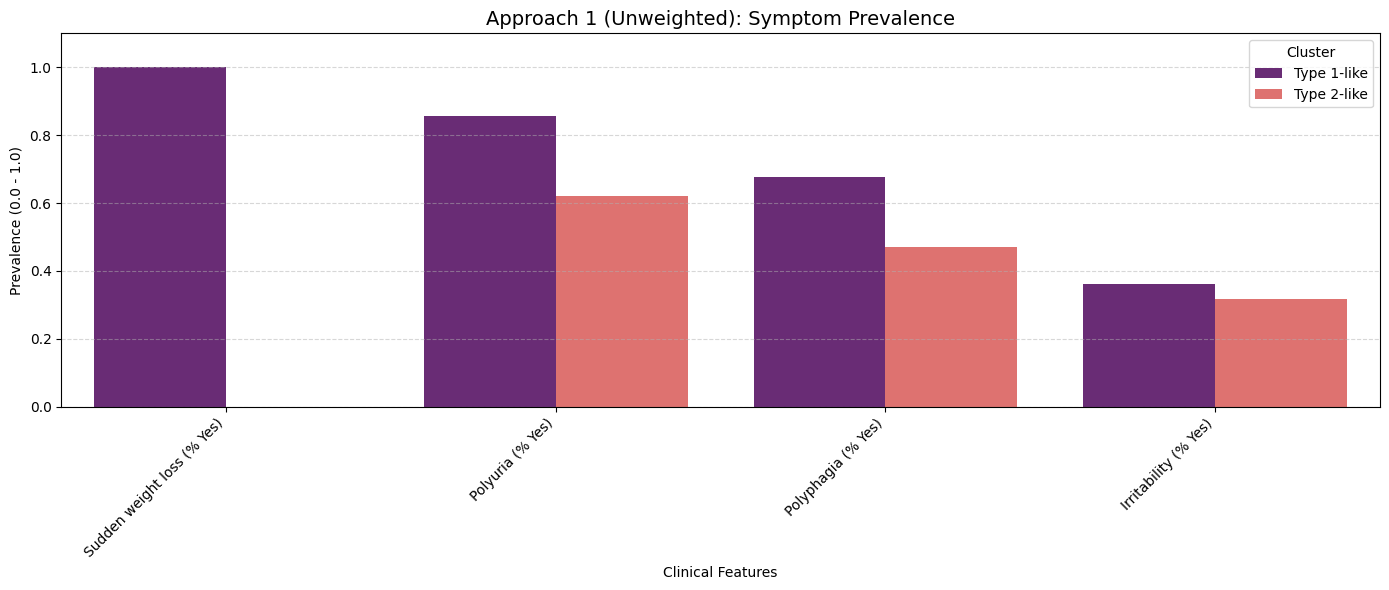

In [37]:
# Approach 1 Unweighted: Cluster 1 = T1-like, Cluster 0 = T2-like
profile_matrix = generate_cluster_profiles(
    diabetic_cohort,
    'Cluster',
    selected_clustering_features,
    title='Approach 1 (Unweighted)',
    label_map={1: 'Type 1-like', 0: 'Type 2-like'}
)

,Count,Percentage
Cluster,,
Type 2-like Diabetes,132,41.25%
Type 1-like Diabetes,188,58.75%


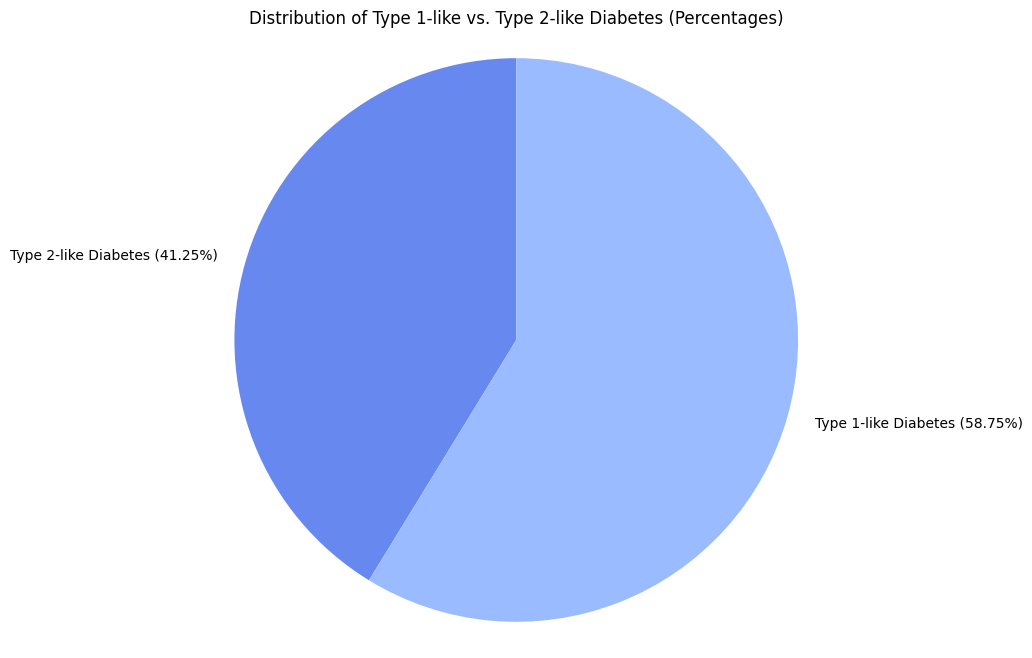

In [38]:
# Count the number of individuals in each cluster
cluster_counts = diabetic_cohort['Cluster'].value_counts().sort_index()

# Calculate percentages
total_positive_cases = cluster_counts.sum()
cluster_percentages = (cluster_counts / total_positive_cases * 100).round(2)

# Map clusters to their inferred types for clearer interpretation
# Based on current cluster profiles: Cluster 0 is Type 2-like, Cluster 1 is Type 1-like
inferred_types = {
    0: 'Type 2-like Diabetes',
    1: 'Type 1-like Diabetes'
}

# Visualise as a table and a pie chart
inferred_types_approach1 = {
    0: 'Type 2-like Diabetes',
    1: 'Type 1-like Diabetes'
}
plot_cluster_distribution(
    diabetic_cohort,
    'Cluster',
    inferred_types_approach1,
    'Distribution of Type 1-like vs. Type 2-like Diabetes (Percentages)'
)

### Second Approach (T2-based) (`Cluster_alt`)

This second clustering approach focuses on Type 2 diabetes symptoms/features, such as obesity, partial paresis, visual blurring, and delayed healing.

In [39]:
# 1. Isolate instances predicted positive across the dataset (re-using the existing `diabetic_cohort`)

# 2. Define an alternative feature set
alternative_clustering_features = ['Age', 'Obesity', 'Partial paresis', 'Visual blurring', 'Delayed healing']
X_diabetic_alt = diabetic_cohort[alternative_clustering_features]

# 3. Dynamic custom pipeline transformation mapping for Level 2 subset with alternative features
X_diabetic_processed_alt = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['Age']),
        ('cat', OneHotEncoder(drop='first'), [c for c in alternative_clustering_features if c != 'Age'])
    ]
).fit_transform(X_diabetic_alt)

# 4. Fit K-Means with the alternative feature set
kmeans_alt = KMeans(n_clusters=2, random_state=seed, n_init=10)
diabetic_cohort['Cluster_alt'] = kmeans_alt.fit_predict(X_diabetic_processed_alt)

# Print mathematical cluster verification score for the alternative set
sil_alt = silhouette_score(X_diabetic_processed_alt, diabetic_cohort['Cluster_alt'])
print(f"Level 2 Subtype Pipeline Clustering with Alternative Features Complete.\nSilhouette Cohesion Score (Alternative Features): {sil_alt:.3f}")

Level 2 Subtype Pipeline Clustering with Alternative Features Complete.
Silhouette Cohesion Score (Alternative Features): 0.322


--- Approach 2 (Unweighted): Numerical Summary ---


Cluster_alt,Type 1-like,Type 2-like
Age (Mean),45.760274,51.712644
Obesity (% Yes),0.130137,0.241379
Partial paresis (% Yes),0.438356,0.729885
Visual blurring (% Yes),0.000000,1.000000
Delayed healing (% Yes),0.465753,0.488506


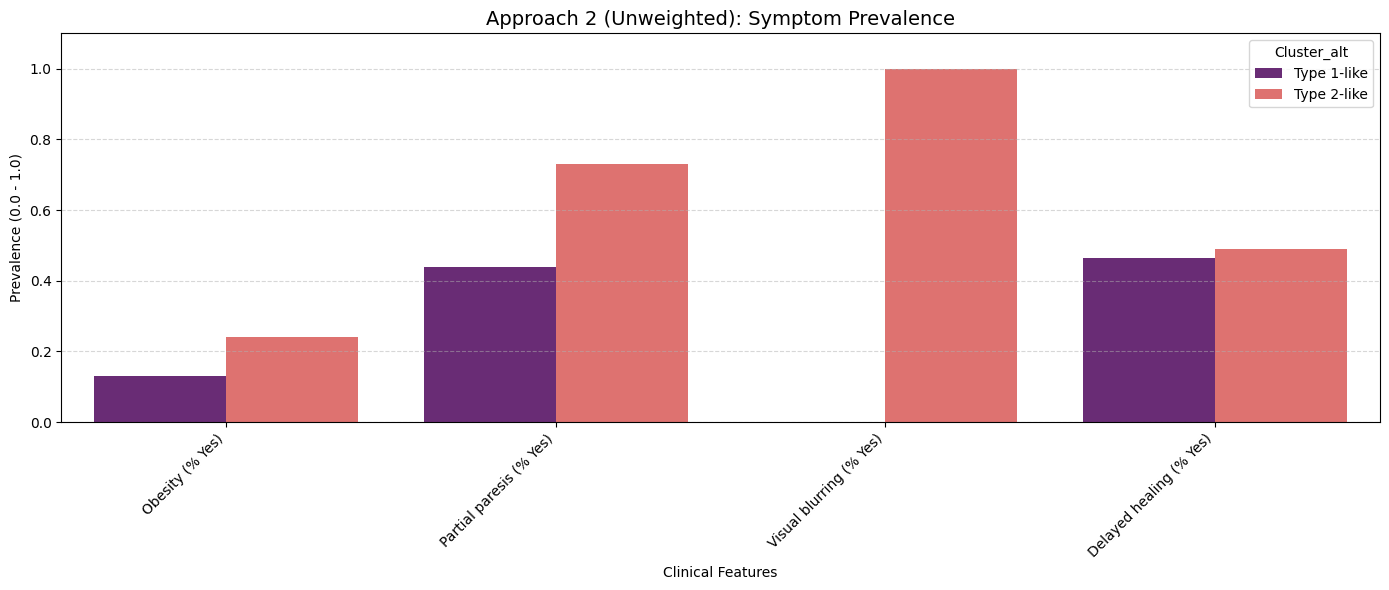

In [40]:
# Approach 2 Unweighted: Cluster 0 = T1-like, Cluster 1 = T2-like
profile_matrix_alt = generate_cluster_profiles(
    diabetic_cohort,
    'Cluster_alt',
    alternative_clustering_features,
    title='Approach 2 (Unweighted)',
    label_map={0: 'Type 1-like', 1: 'Type 2-like'}
)

,Count,Percentage
Cluster_alt,,
Type 1-like Diabetes (Alt),146,45.62%
Type 2-like Diabetes (Alt),174,54.37%


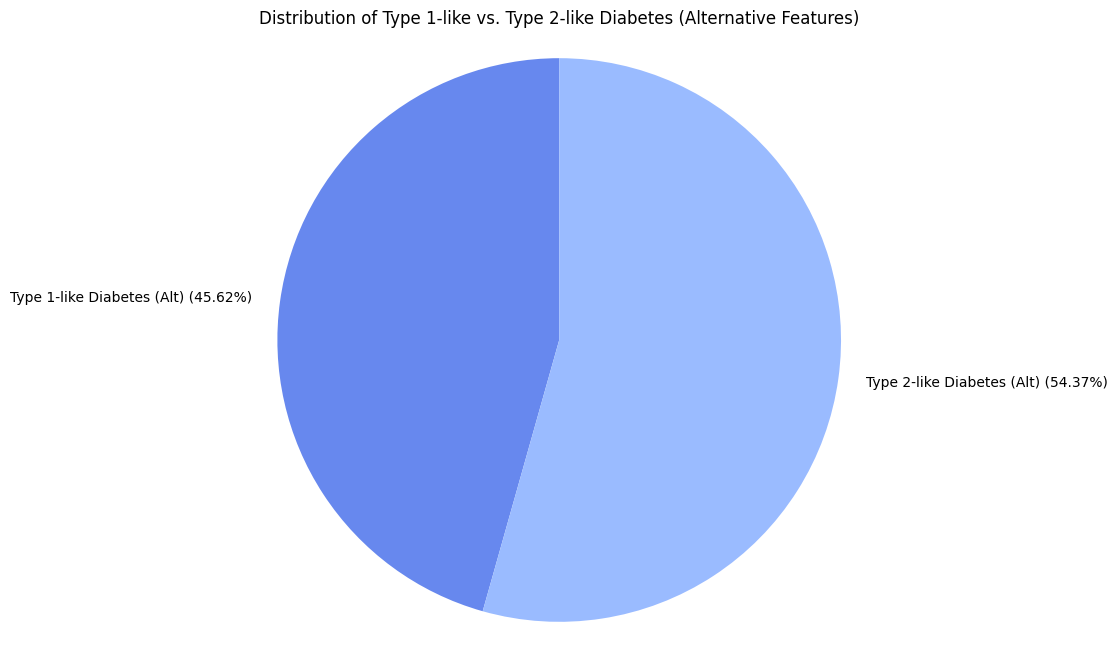

In [41]:
# Count the number of individuals in each cluster for the alternative feature set
alt_cluster_counts = diabetic_cohort['Cluster_alt'].value_counts().sort_index()

# Calculate percentages
alt_total_positive_cases = alt_cluster_counts.sum()
alt_cluster_percentages = (alt_cluster_counts / alt_total_positive_cases * 100).round(2)

# Map clusters to their inferred types for clearer interpretation (based on observed profiles)
# This mapping might need to be adjusted after inspecting the profile matrix for Cluster_alt
alt_inferred_types = {
    0: 'Type 1-like Diabetes (Alt)',
    1: 'Type 2-like Diabetes (Alt)'
}

# Visualise as a table and a pie chart
alt_inferred_types_approach2 = {
    0: 'Type 1-like Diabetes (Alt)',
    1: 'Type 2-like Diabetes (Alt)'
}
plot_cluster_distribution(
    diabetic_cohort,
    'Cluster_alt',
    alt_inferred_types_approach2,
    'Distribution of Type 1-like vs. Type 2-like Diabetes (Alternative Features)'
)

### Collaborative Diagnostic Framework: Analysing Cluster Overlap and Conflicts

To evaluate the "collaboration" between the two clustering perspectives (Approach 1: Type 1-focused and Approach 2: Type 2-focused), a Co-Association Matrix is implemented. This highlights where the models agree and, more importantly, where they conflict.

,Count,Percentage (%)
Consensus_Diagnosis_Fixed,,
Atypical/Mixed,158,49.38
Type 1-like,88,27.50
Type 2-like,74,23.12


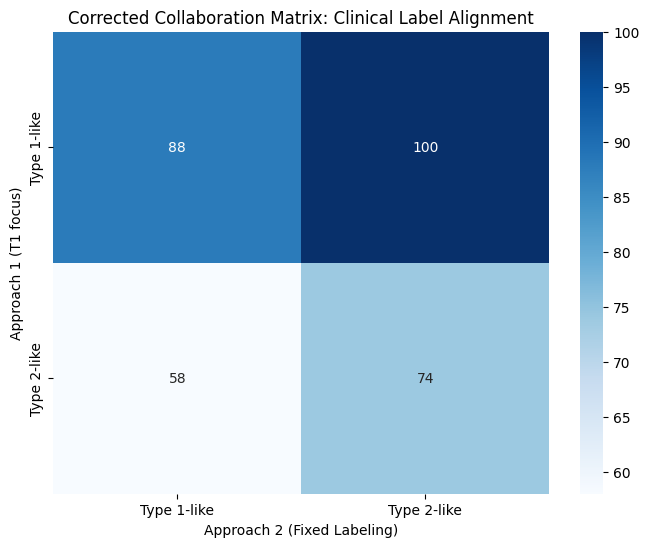

In [42]:
# 1. Update the clinical labels for the standard (unweighted) approaches based on verification
# Approach 1: Based on earlier profiles
diabetic_cohort['Approach_1_Standard_Label'] = diabetic_cohort['Cluster'].map({1: 'Type 1-like', 0: 'Type 2-like'})
# Approach 2: Based on the FIXED verification (Cluster 0 = Type 1-like, Cluster 1 = Type 2-like)
diabetic_cohort['Approach_2_Standard_Label'] = diabetic_cohort['Cluster_alt'].map({0: 'Type 1-like', 1: 'Type 2-like'})

# 2. Re-calculate Consensus Diagnosis (3-tier)
diabetic_cohort['Consensus_Diagnosis_Fixed'] = diabetic_cohort.apply(determine_consensus, axis=1)

# 3. Display updated summary statistics
consensus_stats = diabetic_cohort['Consensus_Diagnosis_Fixed'].value_counts()
summary_df = pd.DataFrame({
    'Count': consensus_stats,
    'Percentage (%)': (consensus_stats / len(diabetic_cohort) * 100).round(2)
})

display(summary_df)

# 4. Re-visualise the Collaboration Matrix
fixed_matrix = pd.crosstab(
    diabetic_cohort['Approach_1_Standard_Label'],
    diabetic_cohort['Approach_2_Standard_Label'],
    rownames=['Approach 1 (T1 focus)'],
    colnames=['Approach 2 (Fixed Labeling)']
)

plt.figure(figsize=(8, 6))
sns.heatmap(fixed_matrix, annot=True, cmap='Blues', fmt='d')
plt.title('Corrected Collaboration Matrix: Clinical Label Alignment')
plt.show()

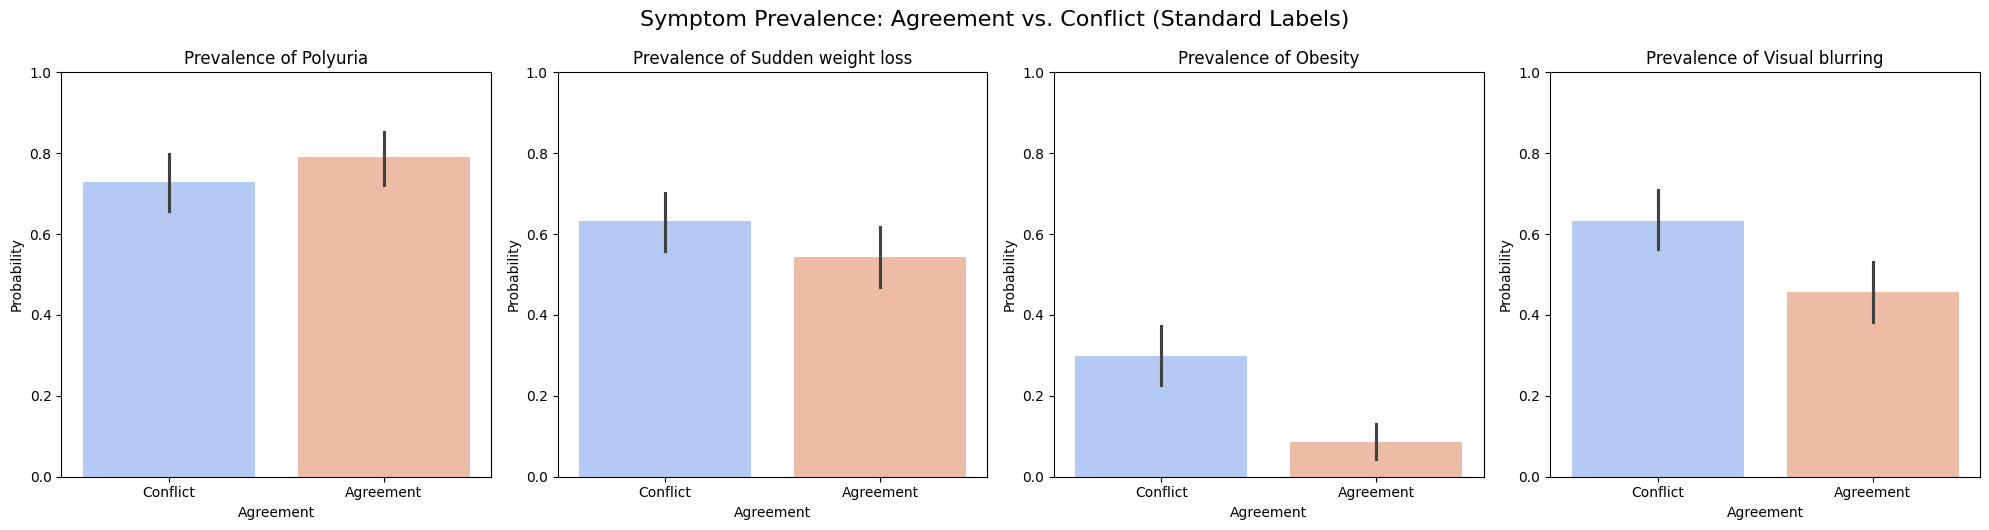

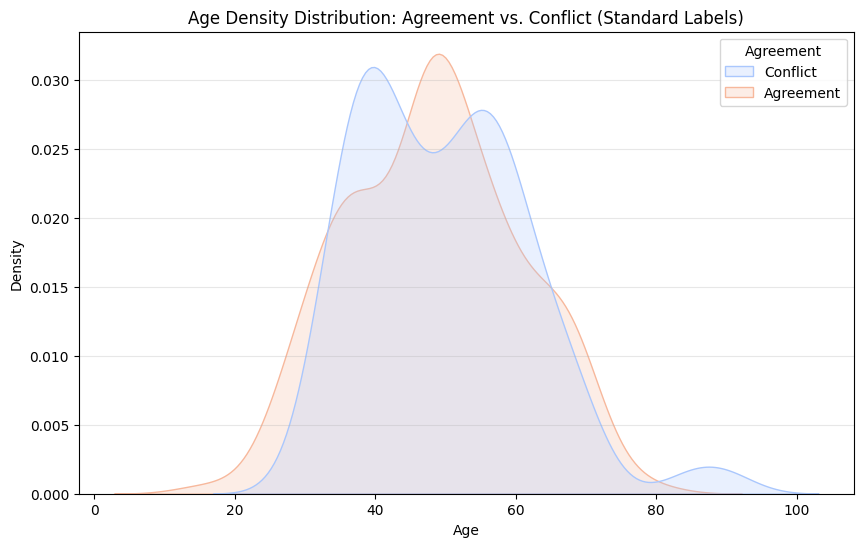

In [43]:
# Define the features for profiling
plot_cols = ['Polyuria', 'Sudden weight loss', 'Obesity', 'Visual blurring', 'Age']
temp_df = diabetic_cohort.copy()

# Create the Agreement column based on Standard Labels
temp_df['Agreement'] = np.where(
    temp_df['Approach_1_Standard_Label'] == temp_df['Approach_2_Standard_Label'],
    'Agreement',
    'Conflict'
)

# Map symptoms to numeric for bar plotting (1 for Yes, 0 for No)
for col in plot_cols:
    if col != 'Age':
        temp_df[f'{col}_num'] = temp_df[col].map({'Yes': 1, 'No': 0})

# 1. Bar Plots for Symptom Prevalence
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
symptoms_num = [f'{c}_num' for c in plot_cols if c != 'Age']

for i, col_num in enumerate(symptoms_num):
    sns.barplot(x='Agreement', y=col_num, data=temp_df,
                ax=axes[i], palette='coolwarm', hue='Agreement', legend=False)
    axes[i].set_title(f'Prevalence of {col_num.split("_num")[0]}')
    axes[i].set_ylabel('Probability')
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.suptitle('Symptom Prevalence: Agreement vs. Conflict (Standard Labels)', y=1.05, fontsize=16)
plt.show()

# 2. KDE Plot for Age Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=temp_df, x='Age', hue='Agreement', fill=True, common_norm=False, palette='coolwarm')
plt.title('Age Density Distribution: Agreement vs. Conflict (Standard Labels)')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Feature Weighting in K-Means

K-Means is a distance-based algorithm (Euclidean distance). By default, all scaled features have an equal range [0, 1] and thus equal 'say' in the cluster formation.

To prioritise specific clinical symptoms, an approach is to apply a weight vector to the processed matrix. If a column is multiplied by 3, the distance between two patients regarding that symptom is tripled, forcing K-Means to group patients more strictly based on that feature.

Weighted K-Means is implemented in order to:
- **Force Clinical Relevance:** By multiplying distance penalties for key symptoms, the algorithm groups patients based on medically significant markers rather than statistical noise.
- **Address Latent Signatures:** Using a dual-perspective approach (Acute vs. Metabolic) allows the detection of patients who may fit one type but exhibit conflicting symptoms, leading to the identification of the 'Atypical/Mixed' group

###Applying Weights to Approach 1

In [44]:
# Define weights for Approach 1 (Type 1 emphasis)
weights_approach_1 = {
    'Age': 0.7,
    'Sudden weight loss': 3.0,
    'Polyuria': 3.0,
    'Polyphagia': 1.5,
    'Irritability': 1.5
}

# This mapping might need to be adjusted after inspecting the profile matrix
inferred_types_weighted = {
    1: 'Type 1-like Diabetes',
    0: 'Type 2-like Diabetes'
}

# Re-process and apply weights
X_weighted_1 = apply_feature_weights(X_diabetic_processed, selected_clustering_features, weights_approach_1)

# Fit Weighted K-Means
kmeans_weighted = KMeans(n_clusters=2, random_state=seed, n_init=10)
diabetic_cohort['Cluster_Weighted'] = kmeans_weighted.fit_predict(X_weighted_1)

print("Weighted K-Means fit complete.")
print(f"New Silhouette Score (Weighted Space): {silhouette_score(X_weighted_1, diabetic_cohort['Cluster_Weighted']):.3f}")

Weighted K-Means fit complete.
New Silhouette Score (Weighted Space): 0.493


#### Stability Validation Loop for Unsupervised Subtyping
To stabilise the subtyping layer, an automated metric-checking framework is integrated in order to select the single highest-performing cluster initialization seed.

In [45]:
# Multi-seed search loop to maximise Cluster Stability (Silhouette Coefficient)
seeds_to_validate = [11, 23, 42, 57, 89, 101, 2023]
best_stability_score = -1
best_stability_seed = None
best_final_kmeans = None

print("Validating Cluster Stability across multi-seed search space...")

# Iterate to find the most cohesive patient subtyping partition
for s in seeds_to_validate:
    kmeans_iter = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=s)
    labels_iter = kmeans_iter.fit_predict(X_weighted_1)

    # Evaluate cohesion using the Silhouette Coefficient
    current_score = silhouette_score(X_weighted_1, labels_iter)

    if current_score > best_stability_score:
        best_stability_score = current_score
        best_stability_seed = s
        best_final_kmeans = kmeans_iter

print(f"\nOptimal Stability Seed Isolated: {best_stability_seed}")
print(f"Maximised Silhouette Stability Coeff: {best_stability_score:.4f}")

# Assign finalised robust clusters to the cohort
diabetic_cohort['Cluster_Weighted_Stable'] = best_final_kmeans.labels_
display(diabetic_cohort[['Age', 'Cluster_Weighted_Stable']].head())

Validating Cluster Stability across multi-seed search space...

Optimal Stability Seed Isolated: 11
Maximised Silhouette Stability Coeff: 0.4932


,Age,Cluster_Weighted_Stable
0,40,0
2,41,0
3,45,1
4,60,1
5,55,0


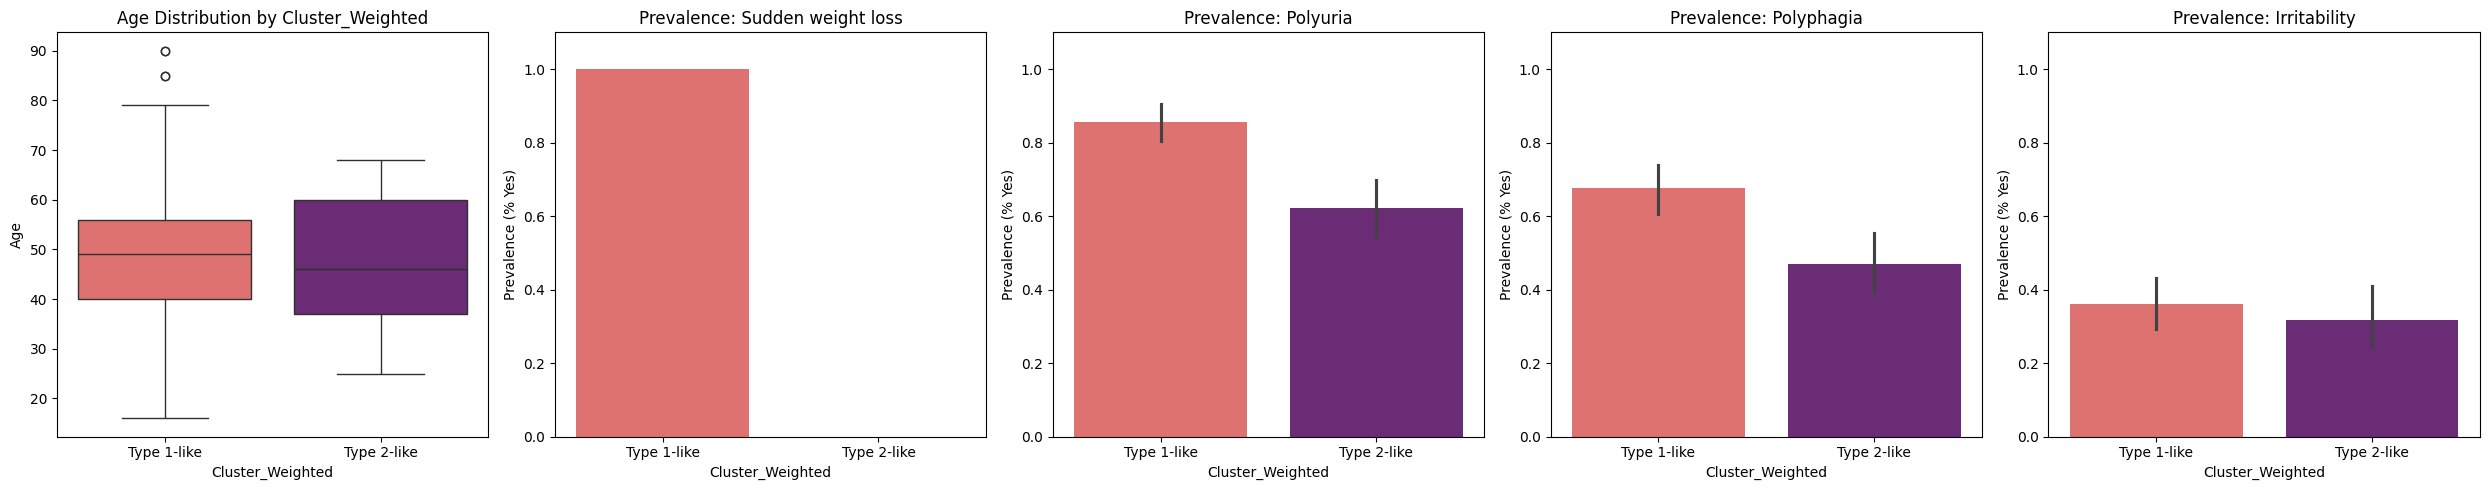

In [46]:
# --- Approach 1: Weighted (Type 1 focus) Feature Verification ---
# Features: Age, Sudden weight loss, Polyuria, Polyphagia, Irritability
plot_cluster_characterization(
    df=diabetic_cohort,
    group_col='Cluster_Weighted',
    symptom_list=['Sudden weight loss', 'Polyuria', 'Polyphagia', 'Irritability'],
    palette='magma',
    label_map={1: 'Type 1-like', 0: 'Type 2-like'}
)

,Count,Percentage
Cluster_Weighted,,
Type 2-like Diabetes,132,41.25%
Type 1-like Diabetes,188,58.75%


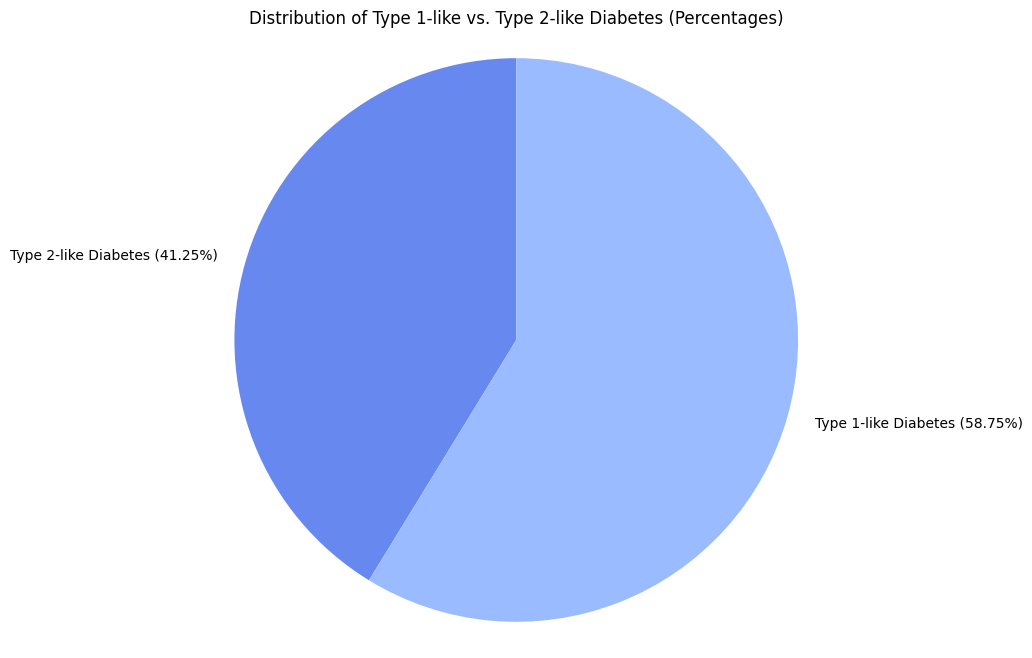

In [47]:
# Count the number of individuals in each cluster
cluster_counts = diabetic_cohort['Cluster_Weighted'].value_counts().sort_index()

# Calculate percentages
total_positive_cases = cluster_counts.sum()
cluster_percentages = (cluster_counts / total_positive_cases * 100).round(2)

# Map clusters to their inferred types for clearer interpretation
# Based on current cluster profiles: Cluster 0 is Type 2-like, Cluster 1 is Type 1-like
inferred_types = {
    0: 'Type 2-like Diabetes',
    1: 'Type 1-like Diabetes'
}

# Visualise as a table and a pie chart
inferred_types_approach1 = {
    0: 'Type 2-like Diabetes',
    1: 'Type 1-like Diabetes'
}
plot_cluster_distribution(
    diabetic_cohort,
    'Cluster_Weighted',
    inferred_types_approach1,
    'Distribution of Type 1-like vs. Type 2-like Diabetes (Percentages)'
)

### Applying Weights to Approach 2 (Type 2 Perspective)

Now a similar weighting logic will be applied to the features used in Approach 2 to see if focusing on metabolic markers like 'Obesity' and 'Delayed healing' yields more stable clusters.

In [48]:
# Define weights for Approach 2
weights_approach_2 = {
    'Age': 1.3,
    'Obesity': 3.5,
    'Delayed healing': 2.0,
    'Partial paresis': 3.5,
    'Visual blurring': 2.0
}

# This mapping might need to be adjusted after inspecting the profile matrix for Cluster_alt
alt_inferred_types = {
    0: 'Type 1-like Diabetes (Alt)',
    1: 'Type 2-like Diabetes (Alt)'
}

try:
    # Apply weights to the alternative feature set
    X_weighted_2 = apply_feature_weights(X_diabetic_processed_alt, alternative_clustering_features, weights_approach_2)

    # Fit Weighted K-Means for Approach 2
    kmeans_weighted_alt = KMeans(n_clusters=2, random_state=seed, n_init=10)
    diabetic_cohort['Cluster_alt_weighted'] = kmeans_weighted_alt.fit_predict(X_weighted_2)

    print("Weighted K-Means for Approach 2 complete.")
    print(f"Silhouette Score (Approach 2 Weighted): {silhouette_score(X_weighted_2, diabetic_cohort['Cluster_alt_weighted']):.3f}")
except NameError:
    print("ERROR: The function 'apply_feature_weights' is not defined.")

Weighted K-Means for Approach 2 complete.
Silhouette Score (Approach 2 Weighted): 0.467


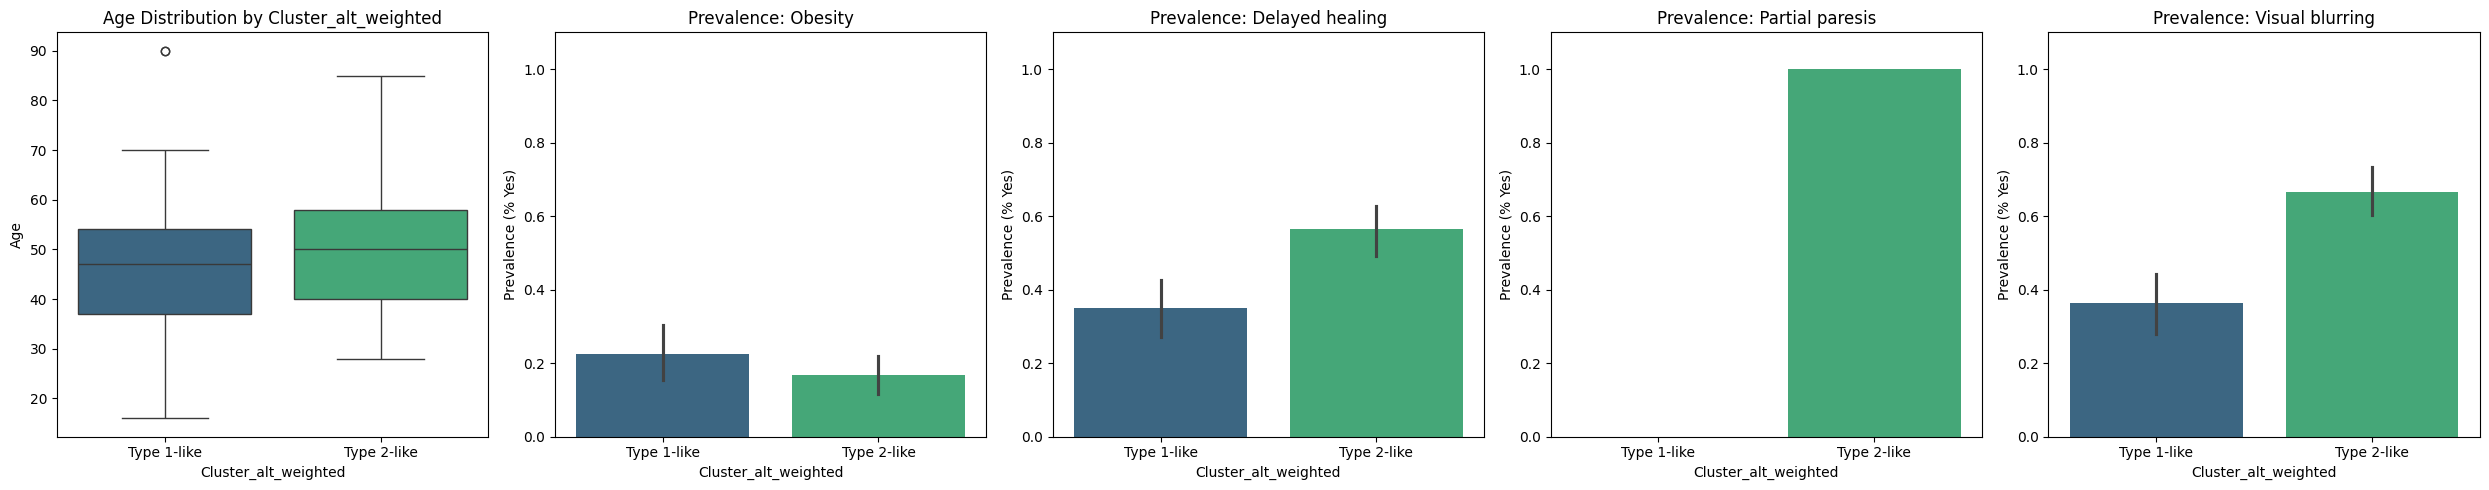

In [49]:
# --- Approach 2: Weighted (Type 2 focus) Feature Verification ---
# Features: Age, Obesity, Delayed healing, Partial paresis, Visual blurring
plot_cluster_characterization(
    df=diabetic_cohort,
    group_col='Cluster_alt_weighted',
    symptom_list=['Obesity', 'Delayed healing', 'Partial paresis', 'Visual blurring'],
    palette='viridis',
    label_map={0: 'Type 1-like', 1: 'Type 2-like'}
)

,Count,Percentage
Cluster_alt_weighted,,
Type 1-like Diabetes (Alt),129,40.31%
Type 2-like Diabetes (Alt),191,59.69%


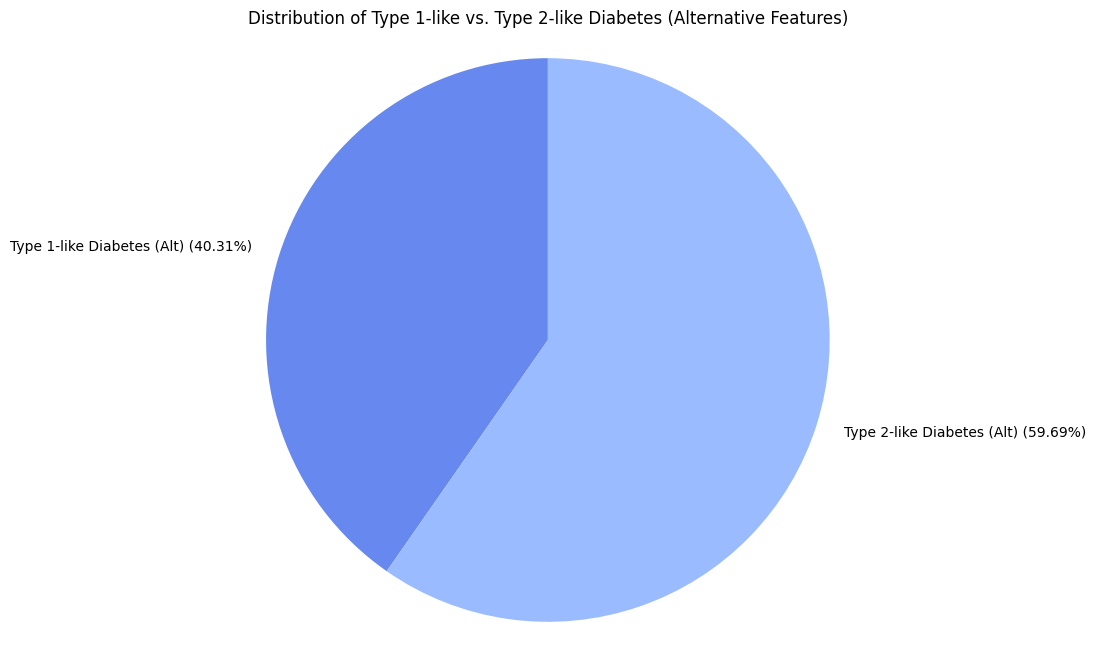

In [50]:
# Count the number of individuals in each cluster for the alternative feature set
alt_cluster_counts = diabetic_cohort['Cluster_alt_weighted'].value_counts().sort_index()

# Calculate percentages
alt_total_positive_cases = alt_cluster_counts.sum()
alt_cluster_percentages = (alt_cluster_counts / alt_total_positive_cases * 100).round(2)

# Map clusters to their inferred types for clearer interpretation (based on observed profiles)
# This mapping might need to be adjusted after inspecting the profile matrix for Cluster_alt
alt_inferred_types = {
    0: 'Type 1-like Diabetes (Alt)',
    1: 'Type 2-like Diabetes (Alt)'
}

# Visualise as a table and a pie chart
alt_inferred_types_approach2 = {
    0: 'Type 1-like Diabetes (Alt)',
    1: 'Type 2-like Diabetes (Alt)'
}
plot_cluster_distribution(
    diabetic_cohort,
    'Cluster_alt_weighted',
    alt_inferred_types_approach2,
    'Distribution of Type 1-like vs. Type 2-like Diabetes (Alternative Features)'
)

### Weighted Collaboration Analysis
Now the Co-Association/Collaboration Matrix will be recreated using the results from the weighted models to visualise the improved alignment between the Type 1 and Type 2 diagnostic perspectives.

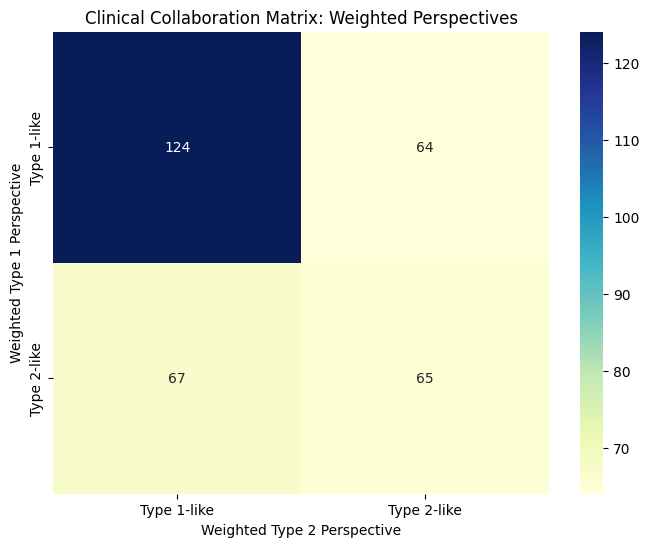

Current Model Agreement Stability: 59.06%


In [51]:
# 1. Create the Weighted Collaboration Matrix with Clinical Labels
# Create a temporary copy to rename the categories for display
collaboration_df = diabetic_cohort.copy()
collaboration_df['Approach_1_Labels'] = collaboration_df['Cluster_Weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})
collaboration_df['Approach_2_Labels'] = collaboration_df['Cluster_alt_weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})

weighted_agreement_matrix = pd.crosstab(
    collaboration_df['Approach_1_Labels'],
    collaboration_df['Approach_2_Labels'],
    rownames=['Weighted Type 1 Perspective'],
    colnames=['Weighted Type 2 Perspective']
)

# 2. Visualise the overlap
plt.figure(figsize=(8, 6))
sns.heatmap(weighted_agreement_matrix, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Clinical Collaboration Matrix: Weighted Perspectives')
plt.show()

# 3. Quick Summary of Stability
# Fix: Calculate the conflict count by checking where labels differ
new_conflict_count = (collaboration_df['Approach_1_Labels'] != collaboration_df['Approach_2_Labels']).sum()
agreement_pct = (len(diabetic_cohort) - new_conflict_count) / len(diabetic_cohort) * 100
print(f"Current Model Agreement Stability: {agreement_pct:.2f}%")

### Finalising Weighted Consensus

Based on the verification above, the explicit mapping is applied to synchronise both perspectives and determine the final 3-tier consensus (Type 1-like, Type 2-like, and Atypical/Mixed).

--- Approach 1 (Weighted): Numerical Summary ---


Cluster_Weighted,Type 1-like,Type 2-like
Age (Mean),49.925532,47.674242
Sudden weight loss (% Yes),1.000000,0.000000
Polyuria (% Yes),0.856383,0.621212
Polyphagia (% Yes),0.675532,0.469697
Irritability (% Yes),0.361702,0.318182


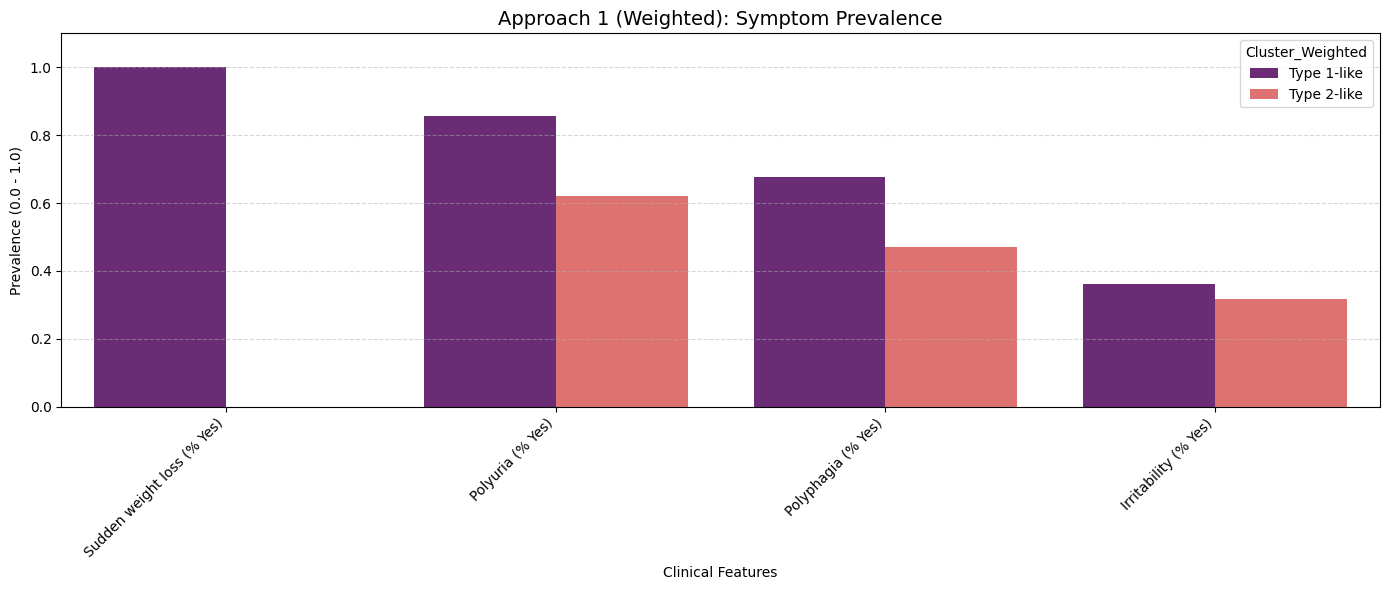

In [52]:
# Approach 1 Weighted: Cluster 1 = T1-like, Cluster 0 = T2-like
weighted_profile = generate_cluster_profiles(
    diabetic_cohort,
    'Cluster_Weighted',
    selected_clustering_features,
    title='Approach 1 (Weighted)',
    label_map={1: 'Type 1-like', 0: 'Type 2-like'}
)

--- Approach 2 (Weighted): Numerical Summary ---


Cluster_alt_weighted,Type 1-like,Type 2-like
Age (Mean),50.596859,46.627907
Obesity (% Yes),0.167539,0.224806
Partial paresis (% Yes),1.000000,0.000000
Visual blurring (% Yes),0.664921,0.364341
Delayed healing (% Yes),0.565445,0.348837


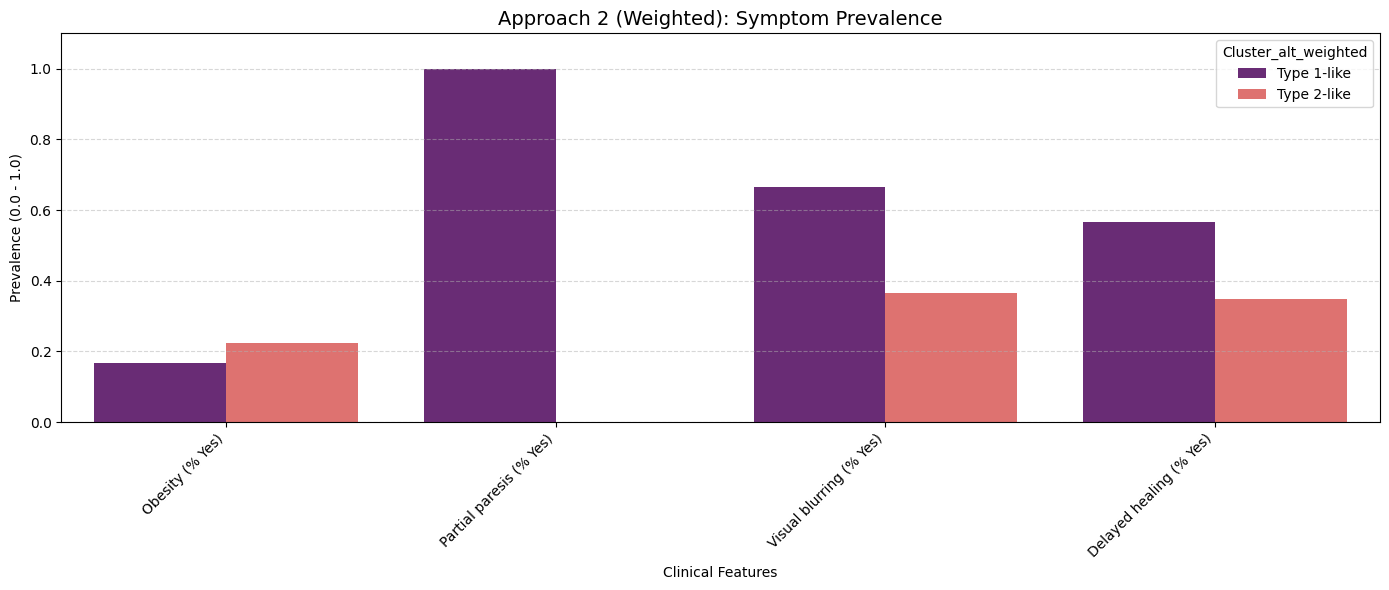

In [53]:
# Approach 2 Weighted: Cluster 1 = T1-like, Cluster 0 = T2-like
weighted_profile_alt = generate_cluster_profiles(
    diabetic_cohort,
    'Cluster_alt_weighted',
    alternative_clustering_features,
    title='Approach 2 (Weighted)',
    label_map={1: 'Type 1-like', 0: 'Type 2-like'}
)

### Stability Analysis: Unweighted vs. Weighted Consensus
The 'Atypical/Mixed' group size must be compared between the original unweighted approach and the new weighted approach to see if prioritising medical anchors reduced the number of ambiguous cases.

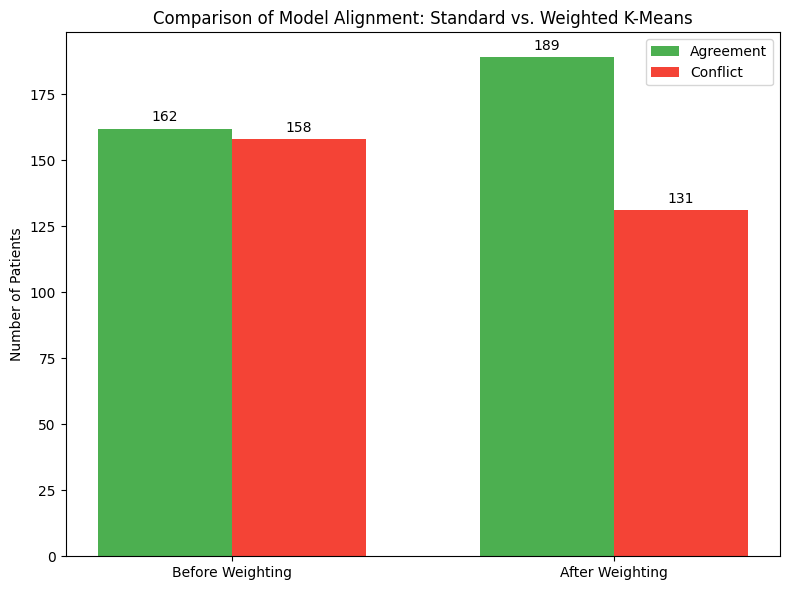

Initial Agreement: 50.6%
Weighted Agreement: 59.06%
Net Gain in Stable Assignments: 8.46 percentage points


In [54]:
# Data for comparison
labels = ['Before Weighting', 'After Weighting']
agreement_counts = [162, len(diabetic_cohort) - new_conflict_count]
conflict_counts = [158, new_conflict_count]

# Plotting the comparison
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, agreement_counts, width, label='Agreement', color='#4CAF50')
rects2 = ax.bar(x + width/2, conflict_counts, width, label='Conflict', color='#F44336')

ax.set_ylabel('Number of Patients')
ax.set_title('Comparison of Model Alignment: Standard vs. Weighted K-Means')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

print(f"Initial Agreement: 50.6%")
print(f"Weighted Agreement: {agreement_pct:.2f}%")
print(f"Net Gain in Stable Assignments: {agreement_pct - 50.6:.2f} percentage points")

### Profiling the Weighted Conflict Cases

Despite the improved stability, 131 patients still receive conflicting classifications between the two weighted approaches. These cases need to be analysed to see if they represent a specific clinical sub-profile (e.g., late-onset Type 1 or early-onset Type 2 with atypical symptoms).

--- Symptom Prevalence & Mean Age: Agreement vs. Conflict ---


,Group,Count,Sudden weight loss (%),Polyuria (%),Obesity (%),Partial paresis (%),Age
0,Agreement,189,65.61,80.95,19.58,65.61,47.00
1,Conflict,131,48.85,68.70,18.32,51.15,51.88


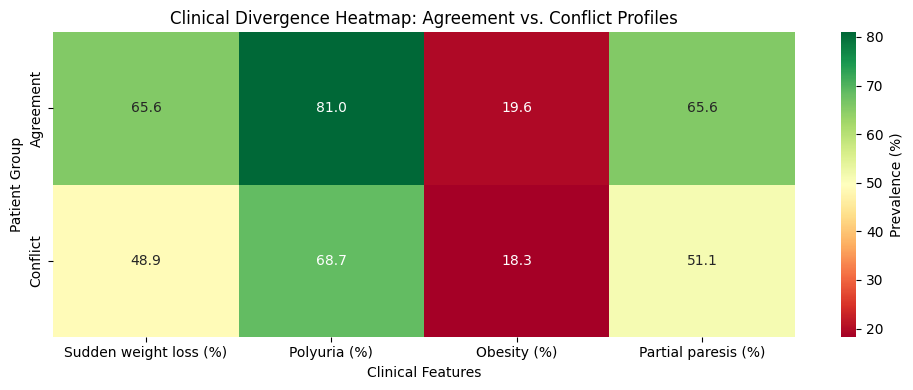

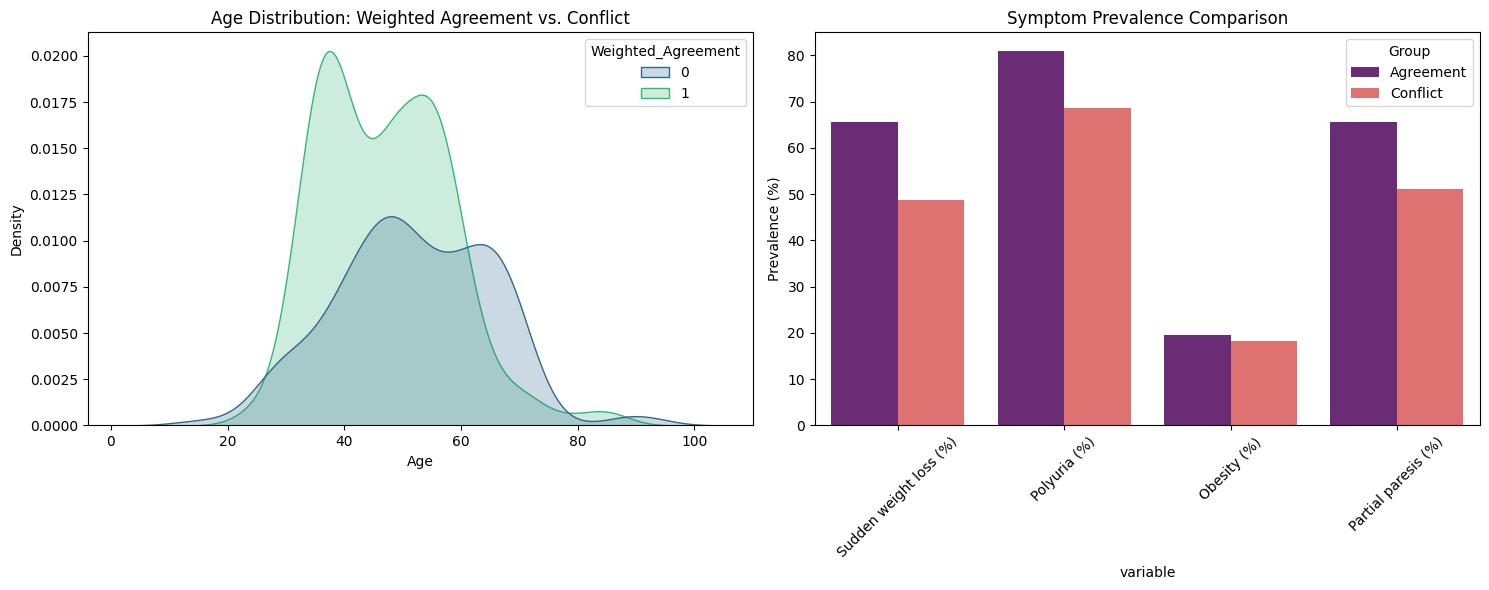

In [55]:
# 1. Explicitly create the label columns from the weighted cluster results
diabetic_cohort['T1_Perspective_Label'] = diabetic_cohort['Cluster_Weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})
diabetic_cohort['T2_Perspective_Label'] = diabetic_cohort['Cluster_alt_weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})

# 2. Create the 'Weighted_Agreement' column
diabetic_cohort['Weighted_Agreement'] = np.where(
    diabetic_cohort['T1_Perspective_Label'] == diabetic_cohort['T2_Perspective_Label'], 1, 0
)

# 3. Isolate the weighted conflict and agreement groups
weighted_conflict_df = diabetic_cohort[diabetic_cohort['Weighted_Agreement'] == 0].copy()
weighted_agreement_df = diabetic_cohort[diabetic_cohort['Weighted_Agreement'] == 1].copy()

# 4. Compare key symptoms between Agreement and Conflict groups
analysis_features = ['Sudden weight loss', 'Polyuria', 'Obesity', 'Partial paresis', 'Age']

comparison_data = []
for group_name, group_df in [('Agreement', weighted_agreement_df), ('Conflict', weighted_conflict_df)]:
    row = {'Group': group_name, 'Count': len(group_df)}
    for feat in analysis_features:
        if feat == 'Age':
            row[feat] = group_df[feat].mean()
        else:
            row[feat + ' (%)'] = (group_df[feat] == 'Yes').mean() * 100
    comparison_data.append(row)

comparison_results = pd.DataFrame(comparison_data)
print("--- Symptom Prevalence & Mean Age: Agreement vs. Conflict ---")
display(comparison_results.round(2))

# 5. Integrated Clinical Divergence Heatmap
heatmap_data = comparison_results.set_index('Group')
heatmap_pct = heatmap_data[[c for c in heatmap_data.columns if '%' in c]]

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_pct, annot=True, cmap='RdYlGn', fmt='.1f', cbar_kws={'label': 'Prevalence (%)'})
plt.title('Clinical Divergence Heatmap: Agreement vs. Conflict Profiles')
plt.xlabel('Clinical Features')
plt.ylabel('Patient Group')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Age Distribution comparison
sns.kdeplot(data=diabetic_cohort, x='Age', hue='Weighted_Agreement', fill=True, ax=axes[0], palette='viridis')
axes[0].set_title('Age Distribution: Weighted Agreement vs. Conflict')

# Symptom Prevalence comparison
# (Using the previously calculated comparison_results which already has 'Agreement' and 'Conflict' strings)
plot_df = comparison_results.melt(id_vars='Group', value_vars=[f + ' (%)' for f in analysis_features if f != 'Age'])
sns.barplot(data=plot_df, x='variable', y='value', hue='Group', ax=axes[1], palette='magma')
axes[1].set_title('Symptom Prevalence Comparison')
axes[1].set_ylabel('Prevalence (%)')

# Fix: Use set_ticks before set_xticklabels to avoid UserWarning
axes[1].set_xticks(range(len(plot_df['variable'].unique())))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Clinical Profile of Individual Clusters (Type 1-focused Weighted Approach)

This section details the sample size and symptom prevalence for each of the two clusters identified by the Type 1-focused weighted K-Means approach (`Cluster_Weighted`). These numbers (188 and 132) represent the inherent sizes of these clusters, distinct from the agreement/conflict counts between multiple approaches.

,Clinical Subtype,Sample Size,Sudden weight loss (%),Polyuria (%),Polyphagia (%),Irritability (%),Weakness (%),Obesity (%),Partial paresis (%),Visual blurring (%),Delayed healing (%),Age
0,Type 1-like,188,100.0,85.64,67.55,36.17,78.72,22.34,65.96,53.19,52.13,49.93
1,Type 2-like,132,0.0,62.12,46.97,31.82,52.27,14.39,50.76,56.06,41.67,47.67


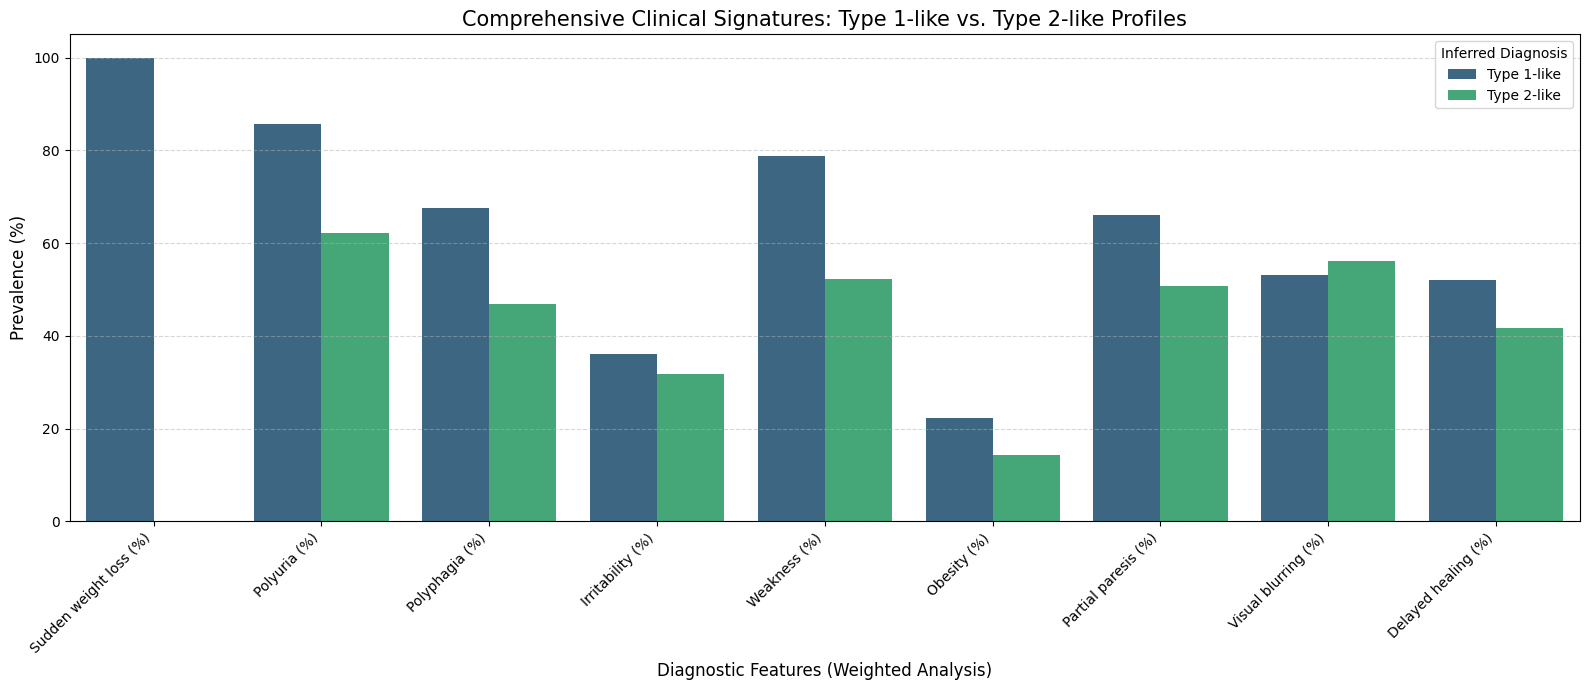

In [56]:
# 1. Define the Clinical Mapping for Approach 1 (Weighted)
diabetic_cohort['Clinical_Type'] = diabetic_cohort['Cluster_Weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})

# 2. Expanded Feature Set including all weighted parameters
# Iclude features from both Approach 1 and Approach 2 weights
signature_features = [
    'Sudden weight loss', 'Polyuria', 'Polyphagia',
    'Irritability', 'Weakness', 'Obesity',
    'Partial paresis', 'Visual blurring', 'Delayed healing', 'Age'
]

subtype_summary = []
for subtype in ['Type 1-like', 'Type 2-like']:
    subset = diabetic_cohort[diabetic_cohort['Clinical_Type'] == subtype]
    row = {'Clinical Subtype': subtype, 'Sample Size': len(subset)}
    for feat in signature_features:
        if feat == 'Age':
            row[feat] = subset[feat].mean()
        else:
            # Calculate prevalence for 'Yes' responses
            row[feat + ' (%)'] = (subset[feat] == 'Yes').mean() * 100
    subtype_summary.append(row)

subtype_results = pd.DataFrame(subtype_summary)

# 3. Visualise the Expanded 'Symptom Signatures'
display(subtype_results.round(2))

# Filter out Age for the bar plot to keep scales consistent (%)
plot_cols = [f + ' (%)' for f in signature_features if f != 'Age']
plot_sig_df = subtype_results.melt(id_vars='Clinical Subtype', value_vars=plot_cols)

plt.figure(figsize=(16, 7))
sns.barplot(data=plot_sig_df, x='variable', y='value', hue='Clinical Subtype', palette='viridis')
plt.title('Comprehensive Clinical Signatures: Type 1-like vs. Type 2-like Profiles', fontsize=15)
plt.ylabel('Prevalence (%)', fontsize=12)
plt.xlabel('Diagnostic Features (Weighted Analysis)', fontsize=12)
plt.legend(title='Inferred Diagnosis', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

,Clinical Subtype,Sample Size,Sudden weight loss (%),Polyuria (%),Polyphagia (%),Irritability (%),Weakness (%),Obesity (%),Partial paresis (%),Visual blurring (%),Delayed healing (%),Age
0,Type 1-like,129,49.61,63.57,42.64,34.11,55.04,22.48,0.0,36.43,34.88,46.63
1,Type 2-like,191,64.92,84.29,70.16,34.55,76.44,16.75,100.0,66.49,56.54,50.60


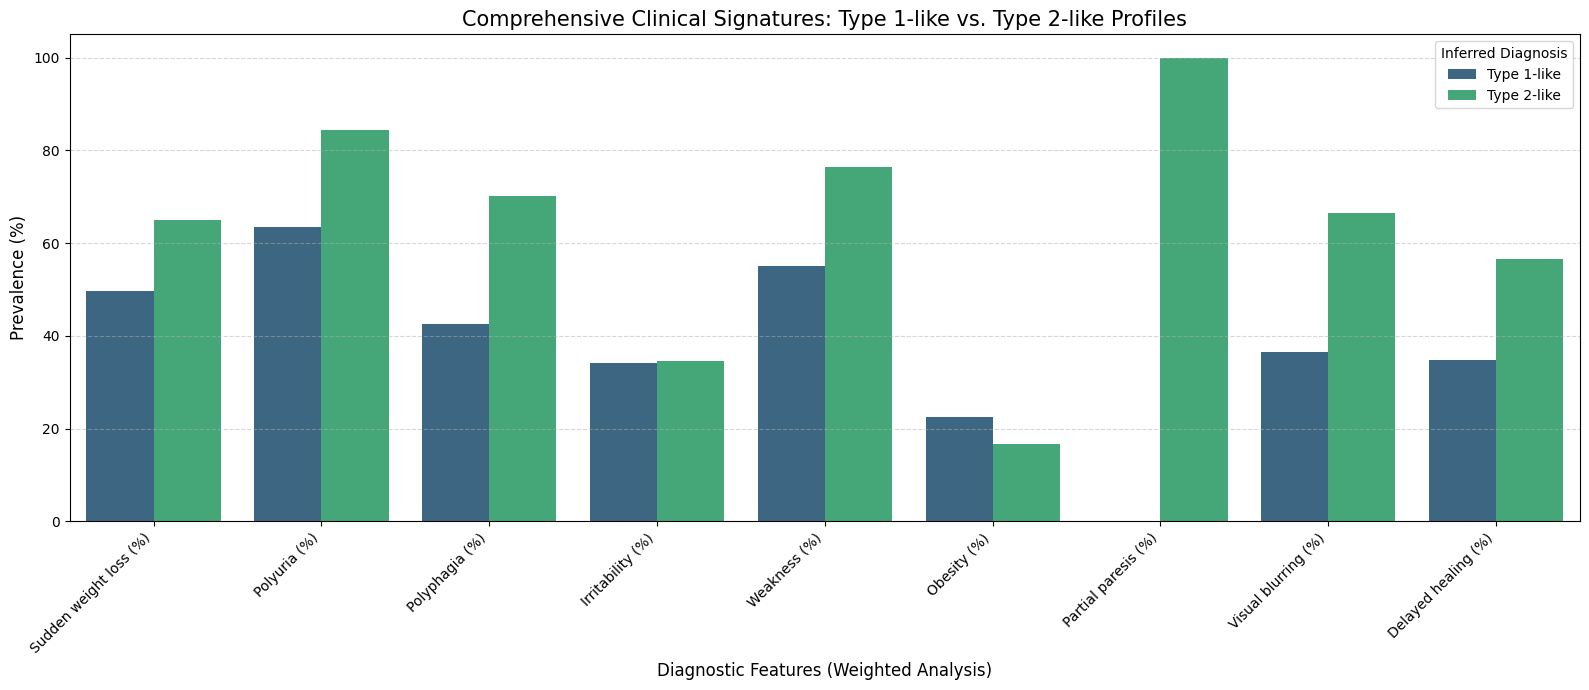

In [57]:
# 1. Define the Clinical Mapping for Approach 2 (Weighted)
diabetic_cohort['Clinical_Type'] = diabetic_cohort['Cluster_alt_weighted'].map({0: 'Type 1-like', 1: 'Type 2-like'})

# 2. Expanded Feature Set including all weighted parameters
# Iclude features from both Approach 1 and Approach 2 weights
signature_features = [
    'Sudden weight loss', 'Polyuria', 'Polyphagia',
    'Irritability', 'Weakness', 'Obesity',
    'Partial paresis', 'Visual blurring', 'Delayed healing', 'Age'
]

subtype_summary = []
for subtype in ['Type 1-like', 'Type 2-like']:
    subset = diabetic_cohort[diabetic_cohort['Clinical_Type'] == subtype]
    row = {'Clinical Subtype': subtype, 'Sample Size': len(subset)}
    for feat in signature_features:
        if feat == 'Age':
            row[feat] = subset[feat].mean()
        else:
            # Calculate prevalence for 'Yes' responses
            row[feat + ' (%)'] = (subset[feat] == 'Yes').mean() * 100
    subtype_summary.append(row)

subtype_results = pd.DataFrame(subtype_summary)

# 3. Visualise the Expanded 'Symptom Signatures'
display(subtype_results.round(2))

# Filter out Age for the bar plot to keep scales consistent (%)
plot_cols = [f + ' (%)' for f in signature_features if f != 'Age']
plot_sig_df = subtype_results.melt(id_vars='Clinical Subtype', value_vars=plot_cols)

plt.figure(figsize=(16, 7))
sns.barplot(data=plot_sig_df, x='variable', y='value', hue='Clinical Subtype', palette='viridis')
plt.title('Comprehensive Clinical Signatures: Type 1-like vs. Type 2-like Profiles', fontsize=15)
plt.ylabel('Prevalence (%)', fontsize=12)
plt.xlabel('Diagnostic Features (Weighted Analysis)', fontsize=12)
plt.legend(title='Inferred Diagnosis', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Final Clustering Evaluation

Evaluation in the unsupervised context focuses on clinical validity, geometric stability, and diagnostic consensus. Beyond the primary $k=2$ baseline seen above, experimental audits have established critical boundaries for phenotype resolution:

- **Multi-Perspective Synthesis:**
    - **Geometric Cohesion:** Experimental $k=3$ initialization identified a stable third cluster with a **Silhouette score of 0.56**, confirming that 'Atypical' patients form a distinct geometric entity rather than statistical noise.
    - **The Consensus Paradox:** While advanced feature engineering (HCS/MSP indices) improved geometric separation (PC1 variance up to ~76%), it reduced diagnostic consensus to **31.9%**. This identifies a 'limit of resolution' where symptoms alone cannot resolve the remaining **68% of mixed-trait cases** without physiological tie-breakers.
*   **Geometric Analysis:** Using Principal Component Analysis (PCA) to visualise cluster boundaries and the impact of weighting strategies on feature variance.
*   **Clinical Characterization:** Profiling the resulting clusters against established medical signatures to verify 'Type 1-like' and 'Type 2-like' phenotypes.
*   **Consensus Mapping:** Analysing the 'Collaboration Matrix' between perspectives to determine diagnostic agreement and quantify the 'Atypical/Mixed' cohort requiring specialist review.

In [58]:
# Calculate anchor symptom prevalence for both weighted approaches
# Focus on 'Sudden weight loss' (Type 1 anchor) and 'Obesity' (Type 2 anchor)

summary_data = []

for approach, col in [('Approach 1 (T1 focus)', 'Cluster_Weighted'),
                      ('Approach 2 (T2 focus)', 'Cluster_alt_weighted')]:
    for cid in [0, 1]:
        subset = diabetic_cohort[diabetic_cohort[col] == cid]
        summary_data.append({
            'Approach': approach,
            'Cluster ID': cid,
            'Size': len(subset),
            'Sudden weight loss (%)': (subset['Sudden weight loss'] == 'Yes').mean() * 100,
            'Obesity (%)': (subset['Obesity'] == 'Yes').mean() * 100,
            'Mean Age': subset['Age'].mean()
        })

verif_df = pd.DataFrame(summary_data)
display(verif_df)

,Approach,Cluster ID,Size,Sudden weight loss (%),Obesity (%),Mean Age
0,Approach 1 (T1 focus),0,132,0.000000,14.393939,47.674242
1,Approach 1 (T1 focus),1,188,100.000000,22.340426,49.925532
2,Approach 2 (T2 focus),0,129,49.612403,22.480620,46.627907
3,Approach 2 (T2 focus),1,191,64.921466,16.753927,50.596859


### Finalising Clinical Cluster Assignments
To resolve any ambiguity, there is a need now to explicitly map the numerical Cluster IDs to their likely clinical subtypes based on the anchor symptoms observed in the verification step.

In [59]:
# 1. Explicitly map both approaches based on clinical profiles
diabetic_cohort['T1_Perspective_Label'] = diabetic_cohort['Cluster_Weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})
diabetic_cohort['T2_Perspective_Label'] = diabetic_cohort['Cluster_alt_weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})

# 2. Define Consensus including 'Atypical/Mixed' for disagreements
def determine_three_tier_consensus(row):
    if row['T1_Perspective_Label'] == row['T2_Perspective_Label']:
        return row['T1_Perspective_Label']
    else:
        return 'Atypical/Mixed'

diabetic_cohort['Consensus_Diagnosis'] = diabetic_cohort.apply(determine_three_tier_consensus, axis=1)

# 3. Calculate and display clinical summary table
summary_features = ['Age', 'Polyuria', 'Polydipsia', 'Sudden weight loss', 'Obesity', 'Partial paresis', 'Visual blurring']
summary_list = []

for diagnostic_group in ['Type 1-like', 'Type 2-like', 'Atypical/Mixed']:
    subset = diabetic_cohort[diabetic_cohort['Consensus_Diagnosis'] == diagnostic_group]
    row = {
        'Diagnostic Profile': diagnostic_group,
        'Patient Count': len(subset),
        'Mean Age': round(subset['Age'].mean(), 1)
    }
    for feat in summary_features:
        if feat != 'Age':
            prevalence = (subset[feat] == 'Yes').mean() * 100
            row[f'{feat} (%)'] = round(prevalence, 1)
    summary_list.append(row)

clinical_summary_df = pd.DataFrame(summary_list)

print("--- Final Consensus Clinical Summary ---")
display(clinical_summary_df.set_index('Diagnostic Profile'))

--- Final Consensus Clinical Summary ---


,Patient Count,Mean Age,Polyuria (%),Polydipsia (%),Sudden weight loss (%),Obesity (%),Partial paresis (%),Visual blurring (%)
Diagnostic Profile,,,,,,,,
Type 1-like,124,49.4,93.5,87.9,100.0,20.2,100.0,58.1
Type 2-like,65,42.4,56.9,53.8,0.0,18.5,0.0,29.2
Atypical/Mixed,131,51.9,68.7,61.8,48.9,18.3,51.1,63.4


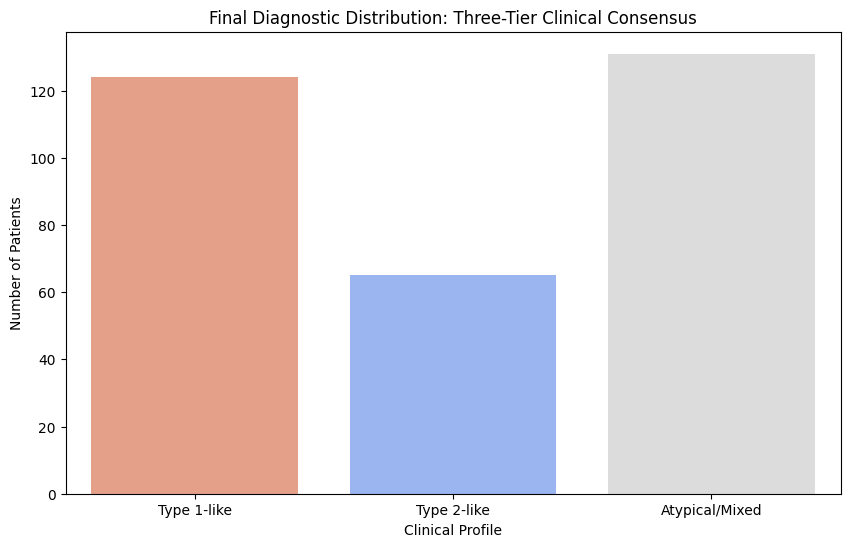

In [60]:
# Visualise the final distribution including Atypical/Mixed cases
plt.figure(figsize=(10, 6))
sns.countplot(data=diabetic_cohort, x='Consensus_Diagnosis', hue='Consensus_Diagnosis',
              palette='coolwarm', order=['Type 1-like', 'Type 2-like', 'Atypical/Mixed'], legend=False)
plt.title('Final Diagnostic Distribution: Three-Tier Clinical Consensus')
plt.ylabel('Number of Patients')
plt.xlabel('Clinical Profile')
plt.show()

### Audit: Profiling the 'Atypical/Mixed' Cohort
Before choosing a final consensus, the pateints who triggered the conflict must be examined. These are patients where one perspective sees Type 1-like traits (e.g., polyuria, irritability) while the other sees Type 2-like traits (e.g., metabolic obesity/delayed healing).

In [61]:
# 1. Isolate the Mixed cohort for profiling
mixed_cohort = diabetic_cohort[diabetic_cohort['Consensus_Diagnosis'] == 'Atypical/Mixed'].copy()

# 2. Compare the counts
print(f"Total Diabetic Patients: {len(diabetic_cohort)}")
print(f"Number of 'Atypical/Mixed' Cases (Conflicts): {len(mixed_cohort)}")
print(f"Percentage of Population requiring further review: {(len(mixed_cohort)/len(diabetic_cohort)*100):.1f}%")

# 3. Profiling the Mixed Cases vs the whole population
profile_cols = ['Age', 'Sudden weight loss', 'Polyuria', 'Obesity', 'Delayed healing', 'Partial paresis']
audit_data = []

for group_name, group_df in [('Full Diabetic Cohort', diabetic_cohort), ('Atypical/Mixed Only', mixed_cohort)]:
    row = {'Group': group_name}
    for col in profile_cols:
        if col == 'Age':
            row[col] = group_df[col].mean()
        else:
            row[col + ' (%)'] = (group_df[col] == 'Yes').mean() * 100
    audit_data.append(row)

audit_results = pd.DataFrame(audit_data).set_index('Group')
display(audit_results.round(2))

Total Diabetic Patients: 320
Number of 'Atypical/Mixed' Cases (Conflicts): 131
Percentage of Population requiring further review: 40.9%


,Age,Sudden weight loss (%),Polyuria (%),Obesity (%),Delayed healing (%),Partial paresis (%)
Group,,,,,,
Full Diabetic Cohort,49.00,58.75,75.94,19.06,47.81,59.69
Atypical/Mixed Only,51.88,48.85,68.70,18.32,47.33,51.15


### Visualising the Clinical Divergence
To visualise the table above, the 'Symptom Signature' of the Mixed cohort must be observed. This helps to see if these patients are truly 'Mixed' or if they are simply 'Low Symptom' cases that are harder for distance-based clustering to place.

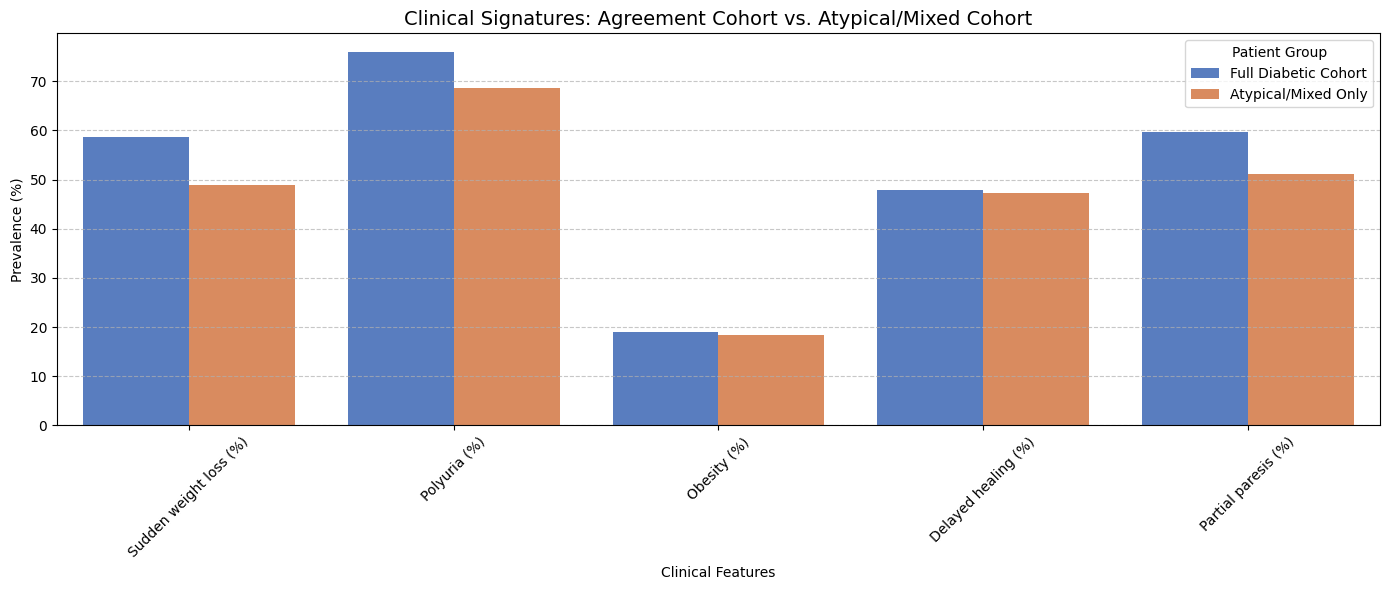

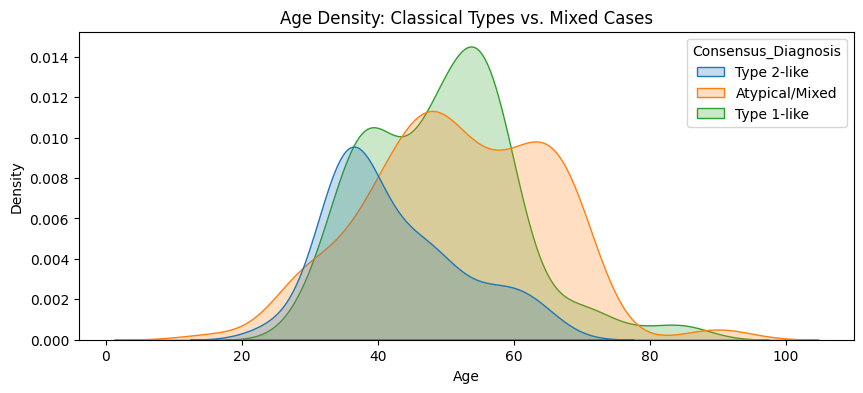

In [62]:
# 1. Prepare data for plotting
plot_audit = audit_results.reset_index().melt(id_vars='Group')
# Filter out Age to keep the percentages on one scale
plot_audit_pct = plot_audit[plot_audit['variable'] != 'Age']

# 2. Create the comparison plot
plt.figure(figsize=(14, 6))
sns.barplot(data=plot_audit_pct, x='variable', y='value', hue='Group', palette='muted')
plt.title('Clinical Signatures: Agreement Cohort vs. Atypical/Mixed Cohort', fontsize=14)
plt.ylabel('Prevalence (%)')
plt.xlabel('Clinical Features')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Patient Group')
plt.tight_layout()
plt.show()

# 3. Age Distribution Comparison
plt.figure(figsize=(10, 4))
sns.kdeplot(data=diabetic_cohort, x='Age', hue='Consensus_Diagnosis', fill=True, palette='tab10')
plt.title('Age Density: Classical Types vs. Mixed Cases')
plt.show()

## Visualising Unsupervised Type Profiling Cluster Geometry

This section visualises the actual partitions created during the type analysis. Because the clustering involves multiple dimensions (Age, Polyuria, etc.), **Principal Component Analysis (PCA)** is used to project the data into a 2D space for visual inspection of the cluster boundaries and centroids.

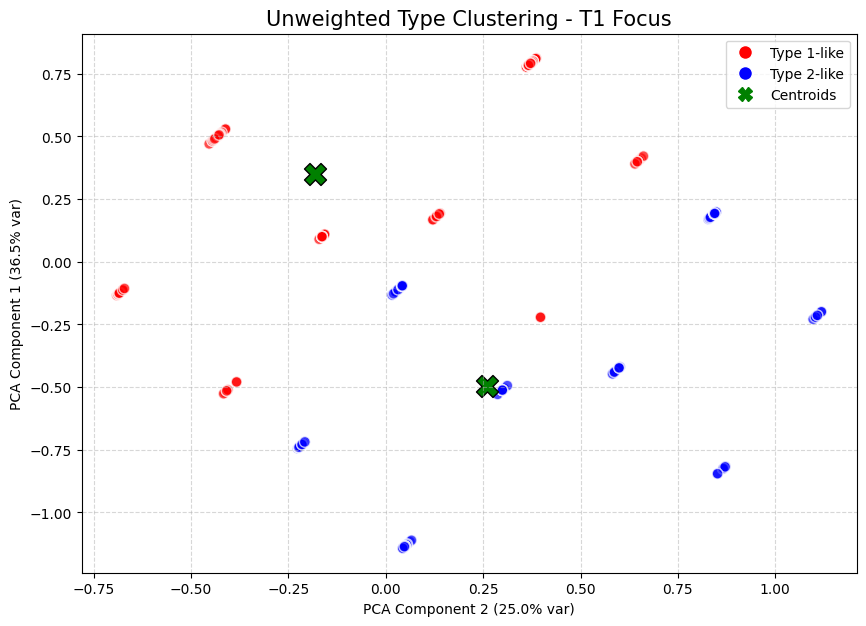

In [63]:
#Approach 1: Unweighted (T1 Focus) (Axes Inverted for Alignment)
pca_unweighted = visualize_pca_projection(
    X_diabetic_processed,
    diabetic_cohort['Cluster'],
    centers=kmeans.cluster_centers_,
    title='Unweighted Type Clustering - T1 Focus',
    invert_axes=True,
    palette={1: 'red', 0: 'blue'}
)

### PCA Geometric Interpretation (Approach 1: Unweighted)
In this unweighted PCA projection (plotted with **Inverted Axes**: PC2 on the X-axis and PC1 on the Y-axis), the 'Type 1-like' and 'Type 2-like' clusters show significant geometric overlap. This inversion is maintained to ensure that the vertical separation corresponds to the primary variance (PC1), matching the visual flow of the subsequent weighted analysis.

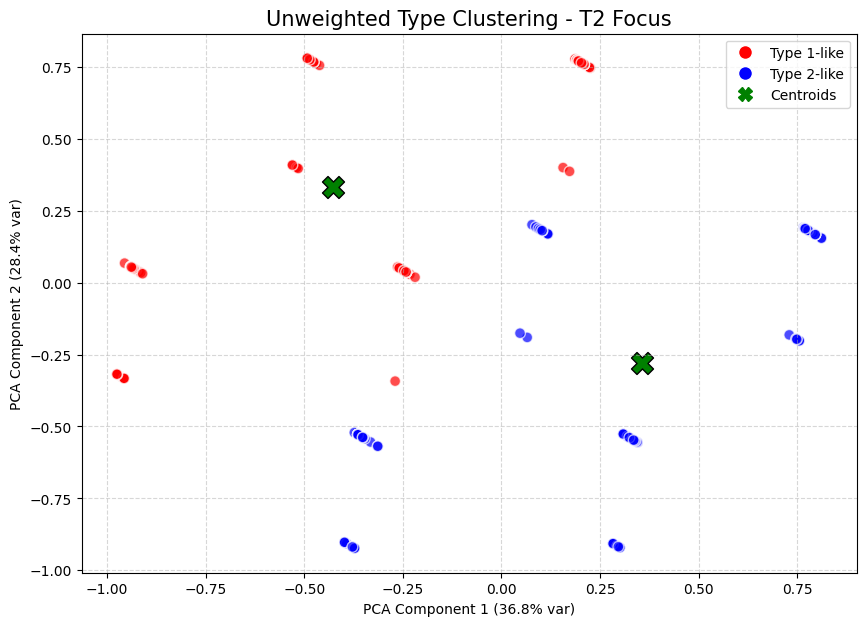

In [64]:
# Approach 2: Unweighted (T2 Focus)
pca_alt_unweighted = visualize_pca_projection(
    X_diabetic_processed_alt,
    diabetic_cohort['Cluster_alt'],
    centers=kmeans_alt.cluster_centers_,
    title='Unweighted Type Clustering - T2 Focus',
    invert_axes=False,
    palette={0: 'red', 1: 'blue'}
)

### Comparison: Visualising Cluster Geometry

The next PCA plots visualise the weighted versions of both approaches. By using weighted features, more structured cluster boundaries are expected.

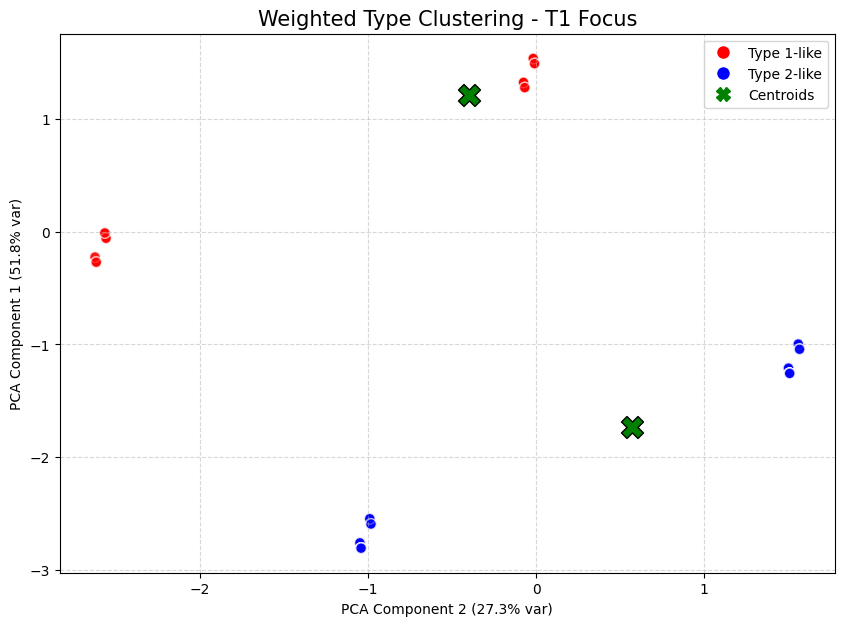

In [65]:
# Approach 1: Weighted (T1 Focus)
pca_weighted = visualize_pca_projection(
    X_weighted_1,
    diabetic_cohort['Cluster_Weighted'],
    centers=kmeans_weighted.cluster_centers_,
    title='Weighted Type Clustering - T1 Focus',
    invert_axes=True,
    palette={1: 'red', 0: 'blue'}
)

By applying medical anchor weights, the phenotype space has been reorganised. Using the **Inverted Axis** convention (PC2 on X, PC1 on Y), a distinct 'striping' effect can be noticed. This layout confirms that the model is prioritising critical clinical markers along the vertical PC1 axis, leading to much clearer diagnostic boundaries between the clusters.

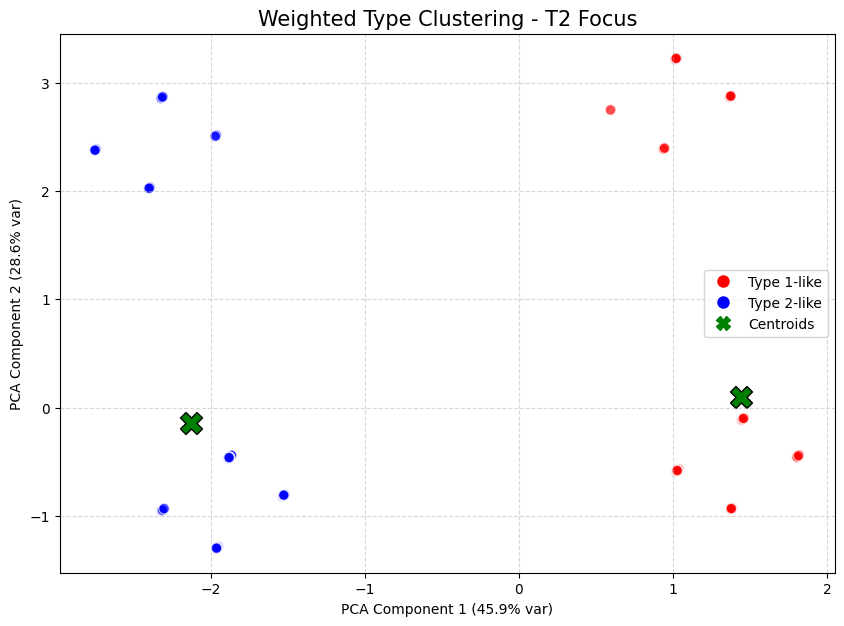

In [66]:
# Approach 2: Weighted (T2 Focus)
pca_alt_weighted = visualize_pca_projection(
    X_weighted_2,
    diabetic_cohort['Cluster_alt_weighted'],
    centers=kmeans_weighted_alt.cluster_centers_,
    title='Weighted Type Clustering - T2 Focus',
    invert_axes=False,
    palette={1: 'red', 0: 'blue'}
)

### PCA Geometric Interpretation (Approach 2: Weighted)
Similar to Approach 1, the weighted metabolic perspective shows a more pronounced partition.The increased variance explained by PC1 confirms that the weighting strategy successfully forces the algorithm to group patients according to chronic metabolic complications.

In [67]:
print(f"---  PC1 VARIANCE  ---")
print(f"Approach 1 - Unweighted PC1: {pca_unweighted.explained_variance_ratio_[0]:.2%}")
print(f"Approach 1 - Weighted PC1:   {pca_weighted.explained_variance_ratio_[0]:.2%}")
print("-" * 30)
print(f"Approach 2 - Unweighted PC1: {pca_alt_unweighted.explained_variance_ratio_[0]:.2%}")
print(f"Approach 2 - Weighted PC1:   {pca_alt_weighted.explained_variance_ratio_[0]:.2%}")

---  PC1 VARIANCE  ---
Approach 1 - Unweighted PC1: 36.51%
Approach 1 - Weighted PC1:   51.82%
------------------------------
Approach 2 - Unweighted PC1: 36.82%
Approach 2 - Weighted PC1:   45.87%


### Technical Validation Summary: PCA Geometry

**Finding:** The weighted PCA plots exhibit structured separation. Following the **final variance audit**, the weighted models highlight significantly more variance in PC1 compared to the unweighted models:
*   **Approach 1:** Increased from 36.51% to **51.82%**.
*   **Approach 2:** Increased from 36.82% to **45.87%**.

-> The significant jump in Explained Variance confirms that the applied clinical weights successfully reorganised the phenotype space around the chosen medical anchors (e.g., Sudden Weight Loss for T1, and Obesity/Paresis for T2).

-> The "striping" observed in the scatter plots is a mathematical consequence of performing PCA on weighted binary features; it represents the clear separation between states forced by the weighting vector.

**Verdict:** The weighting strategy is functioning as intended.

In [68]:
# 1. Approach 1 (Unweighted) Loadings
loadings_app1_unweighted = pd.DataFrame(
    pca_unweighted.components_.T,
    columns=['PC1', 'PC2'],
    index=selected_clustering_features
)

# 2. Approach 1 (Weighted) Loadings
loadings_app1_weighted = pd.DataFrame(
    pca_weighted.components_.T,
    columns=['PC1', 'PC2'],
    index=selected_clustering_features
)

# 3. Approach 2 (Unweighted) Loadings
loadings_app2_unweighted = pd.DataFrame(
    pca_alt_unweighted.components_.T,
    columns=['PC1', 'PC2'],
    index=alternative_clustering_features
)

# 4. Approach 2 (Weighted) Loadings
loadings_app2_weighted = pd.DataFrame(
    pca_alt_weighted.components_.T,
    columns=['PC1', 'PC2'],
    index=alternative_clustering_features
)

print("--- Approach 1: PCA Loadings Comparison (T1 Focus) ---")
print("Unweighted:")
display(loadings_app1_unweighted.sort_values(by='PC1', ascending=False))
print("Weighted:")
display(loadings_app1_weighted.sort_values(by='PC1', ascending=False))

print("\n--- Approach 2: PCA Loadings Comparison (T2 Focus) ---")
print("Unweighted:")
display(loadings_app2_unweighted.sort_values(by='PC1', ascending=False))
print("Weighted:")
display(loadings_app2_weighted.sort_values(by='PC1', ascending=False))

--- Approach 1: PCA Loadings Comparison (T1 Focus) ---
Unweighted:


,PC1,PC2
Polyphagia,0.616179,0.245411
Sudden weight loss,0.610464,-0.464124
Polyuria,0.396661,-0.270827
Irritability,0.293826,0.805606
Age,0.063114,0.044877


Weighted:


,PC1,PC2
Sudden weight loss,0.844276,-0.525537
Polyuria,0.515714,0.849856
Polyphagia,0.142086,0.038923
Irritability,0.031028,-0.004878
Age,0.009249,0.003982



--- Approach 2: PCA Loadings Comparison (T2 Focus) ---
Unweighted:


,PC1,PC2
Partial paresis,0.679008,-0.002907
Visual blurring,0.574384,-0.582029
Delayed healing,0.450444,0.722226
Age,0.067577,-0.054244
Obesity,-0.039559,-0.369703


Weighted:


,PC1,PC2
Partial paresis,0.952293,0.102377
Visual blurring,0.214340,0.239805
Delayed healing,0.176476,-0.174337
Age,0.020519,0.026637
Obesity,-0.125029,0.949163


### Interpretation Guide
* **High Positive Value:** The feature strongly increases as you move right (PC1) or up (PC2).
* **High Negative Value:** The feature strongly decreases as you move right/up.
* **Values near 0:** The feature has little influence on that specific component's direction.

# Conclusion

This project demonstrates the feasibility of a dual-stage diagnostic architecture for diabetes management. The results confirm that high-precision screening (Stage 1) achieves **98-99% accuracy** in identifying diabetic patients, while the subtyping layer (Stage 2) provides a **59.1% stable consensus** for type classification.

## Project Results Summary
Based on the comprehensive notebook analysis, the following outcomes were established:
1. **Diagnostic Precision:** The optimised Random Forest classifier attained an F1-score of 0.99, demonstrating that patient-reported symptoms—specifically Polyuria and Polydipsia—serve as near-perfect diagnostic proxies in this cohort.
2. **Phenotype Stability:** By transitioning to a weighted K-Means approach, the explained variance of the primary phenotype dimension (PC1) was increased from ~36% to **51.82%**, significantly reducing geometric overlap between clusters.
3. **Cohort Stratification:** The framework successfully identified a high-confidence agreement group (59.1% of patients) while isolating a **40.9% 'Atypical/Mixed' cohort** that requires advanced endocrinology review, providing a mathematical basis for clinical triage.

## Further observations
While the current framework is highly effective based on the Sylhet symptom dataset, diagnostic subtyping would be significantly more robust with the inclusion of additional clinical indicators. Specifically, integrating data on HbA1c levels, fasting plasma glucose, C-peptide levels (to measure endogenous insulin production), and body mass index (BMI) would allow for a more precise distinction between Type 1 and Type 2 presentations.

If these metrics were available, the "Atypical/Mixed" cohort would likely be reduced, as the model could better differentiate between metabolic insulin resistance (Type 2) and autoimmune-driven insulin deficiency (Type 1). Incorporating these physiological markers would bridge the gap between symptom-based triage and definitive clinical diagnosis.

# Appendix: Experimental Archive & Triage Trials

This appendix documents the experimental iterations and 'triage trials' conducted during the research process. These steps were separated from the primary dual-layer pipeline to maintain a clean narrative focused on the most clinically actionable results.

1.  **High-Order Clustering ($k=3$):** Evaluations of whether a third geometric center can naturally isolate 'Mixed' phenotypes.
2.  **Composite Feature Engineering:** Construction of the Hyperglycemic Crisis Score (HCS) and Metabolic Syndrome Proxy (MSP) to test for latent signal enhancement.
3.  **The Consensus Paradox:** An analysis of why increased geometric precision (higher Silhouette scores) occasionally results in decreased clinical agreement between diagnostic perspectives.

### Experiment: Unsupervised Subtyping with $k=3$

Based on the clinical rationale to isolate an 'Atypical/Mixed' group directly through geometry, a $k=3$ initialization is tested. This seeks to identify if a third stable cluster emerges, representing patients with mixed metabolic and acute symptoms (e.g., LADA profiles).

K-Means (k=3) Subtyping Complete.
Silhouette Cohesion Score: 0.562
--- 3-Cluster Phenotype Profiles: Numerical Summary ---


Cluster_k3,Phenotype A,Phenotype B,Phenotype C
Age (Mean),50.402439,49.347826,46.766234
Sudden weight loss (% Yes),0.000000,1.000000,0.350649
Polyuria (% Yes),1.000000,1.000000,0.000000
Polyphagia (% Yes),0.548780,0.689441,0.428571
Irritability (% Yes),0.317073,0.366460,0.324675


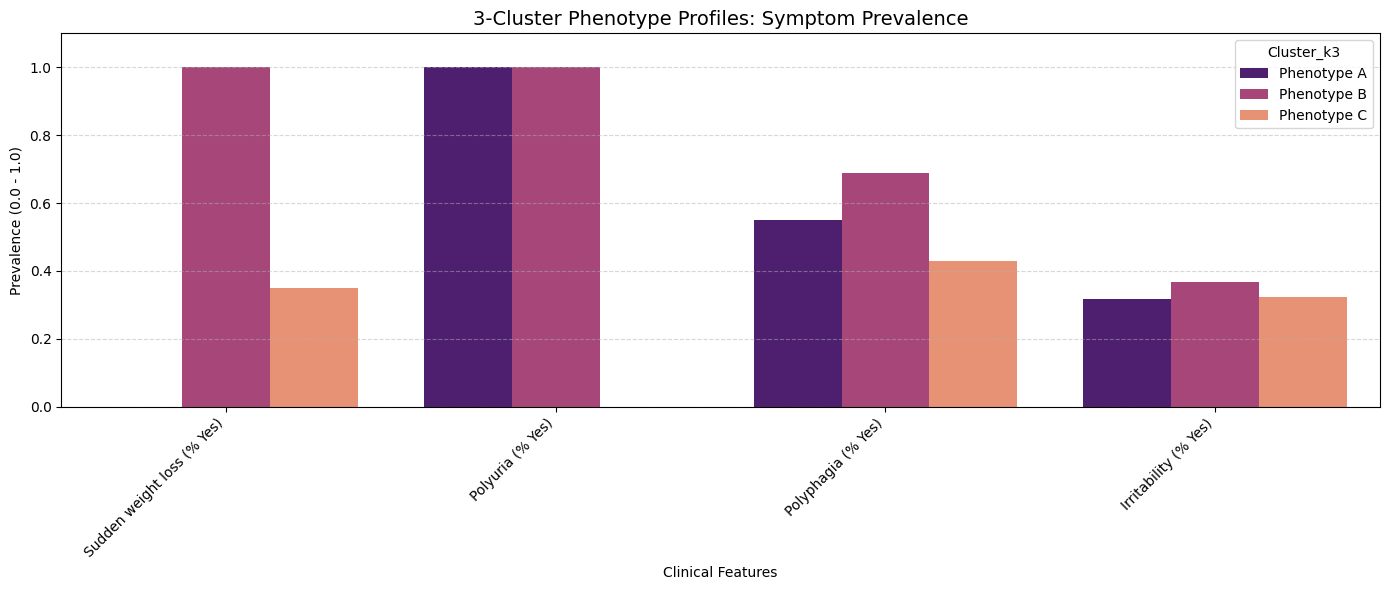

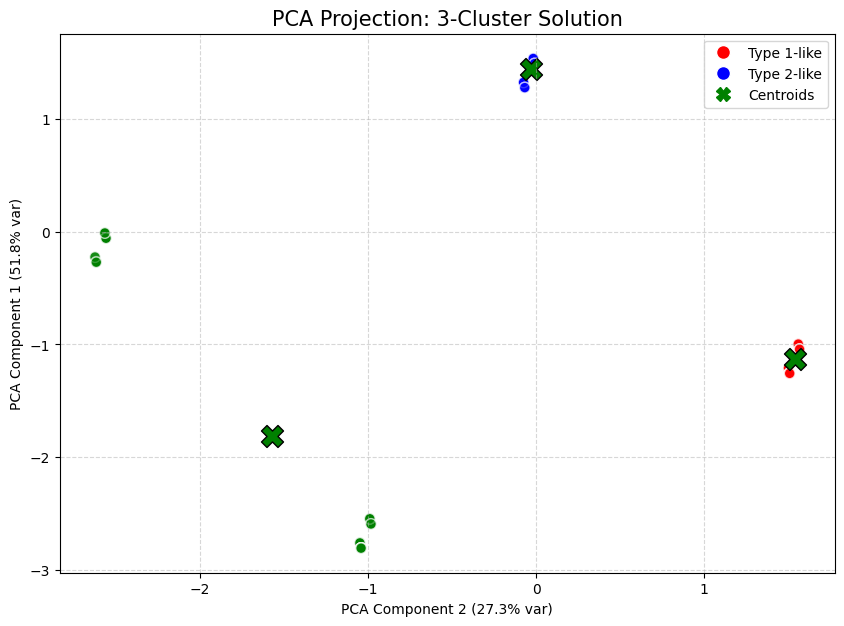

In [69]:
# 1. Fit K-Means with k=3 on the weighted feature space from Approach 1
kmeans_k3 = KMeans(n_clusters=3, random_state=seed, n_init=10)
diabetic_cohort['Cluster_k3'] = kmeans_k3.fit_predict(X_weighted_1)

# 2. Evaluate mathematical cohesion
sil_k3 = silhouette_score(X_weighted_1, diabetic_cohort['Cluster_k3'])
print(f"K-Means (k=3) Subtyping Complete.")
print(f"Silhouette Cohesion Score: {sil_k3:.3f}")

# 3. Visualize the 3-tier profiles
# Use the existing helper to check how symptoms distribute across these 3 groups
profile_matrix_k3 = generate_cluster_profiles(
    diabetic_cohort,
    'Cluster_k3',
    selected_clustering_features,
    title='3-Cluster Phenotype Profiles',
    label_map={0: 'Phenotype A', 1: 'Phenotype B', 2: 'Phenotype C'}
)

# 4. PCA Projection for k=3
_ = visualize_pca_projection(
    X_weighted_1,
    diabetic_cohort['Cluster_k3'],
    centers=kmeans_k3.cluster_centers_,
    title='PCA Projection: 3-Cluster Solution',
    invert_axes=True,
    palette={0: 'red', 1: 'blue', 2: 'green'}
)

--- Cluster Distribution Analysis (k=3) ---


,Patient Count,Percentage (%)
Cluster_k3,,
Phenotype A (T2-Heavy),82,25.62%
Phenotype B (T1-Classical),161,50.31%
Phenotype C (Atypical/Mixed),77,24.06%


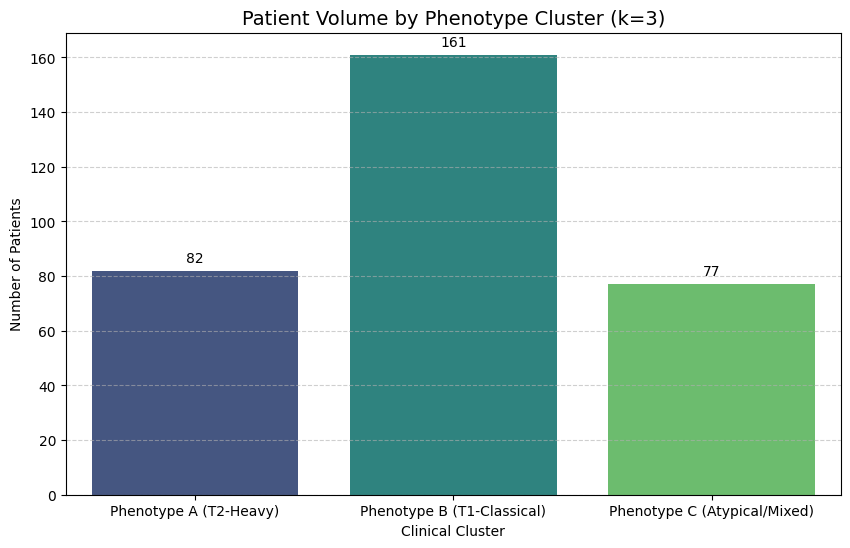

In [70]:
# 1. Calculate frequency and percentages for the 3 clusters
k3_counts = diabetic_cohort['Cluster_k3'].value_counts().sort_index()
k3_pcts = (k3_counts / len(diabetic_cohort) * 100).round(2)

# 2. Map to descriptive labels based on the profile matrix results
# Cluster 0: High Polyuria/Polyphagia, No Weight Loss -> Type 2-like (High Symptom)
# Cluster 1: High Weight Loss, High Polyuria -> Type 1-like (Classical)
# Cluster 2: Low Weight Loss, Moderate Symptoms -> Atypical/Mixed Group
k3_labels = {
    0: 'Phenotype A (T2-Heavy)',
    1: 'Phenotype B (T1-Classical)',
    2: 'Phenotype C (Atypical/Mixed)'
}

k3_summary = pd.DataFrame({
    'Patient Count': k3_counts,
    'Percentage (%)': k3_pcts.astype(str) + '%'
}).rename(index=k3_labels)

print("--- Cluster Distribution Analysis (k=3) ---")
display(k3_summary)

# 3. Visualization: Cluster Proportion Bar Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=k3_summary.index, y=k3_counts.values, palette='viridis', hue=k3_summary.index, legend=False)
plt.title('Patient Volume by Phenotype Cluster (k=3)', fontsize=14)
plt.ylabel('Number of Patients')
plt.xlabel('Clinical Cluster')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Experiment: Unsupervised Subtyping with $k=3$ (Type 2 Focus - Post-Weighting)

Following the same logic as the Type 1-focused experiment, the $k=3$ initialization on the **Type 2-weighted feature space** will be now tested. This perspective prioritizes metabolic anchors like Obesity and Partial Paresis to see if a similar three-tier distribution of patients emerges.

K-Means (k=3) Approach 2 Subtyping Complete.
Silhouette Cohesion Score (Weighted T2 Space): 0.528
--- 3-Cluster Phenotype Profiles (Approach 2 Weighted): Numerical Summary ---


Cluster_k3_alt,Phenotype A,Phenotype B,Phenotype C
Age (Mean),45.85,52.032787,49.811321
Obesity (% Yes),0.00,1.000000,0.000000
Partial paresis (% Yes),0.00,0.524590,1.000000
Visual blurring (% Yes),0.34,0.688525,0.616352
Delayed healing (% Yes),0.37,0.311475,0.610063


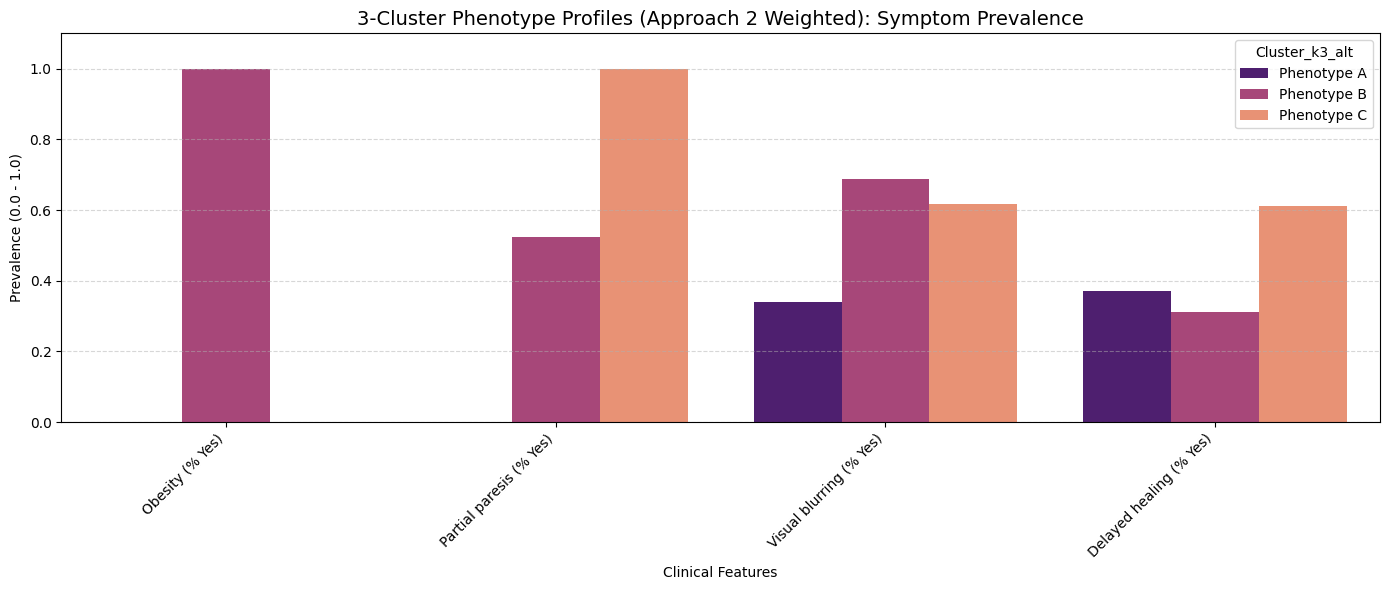

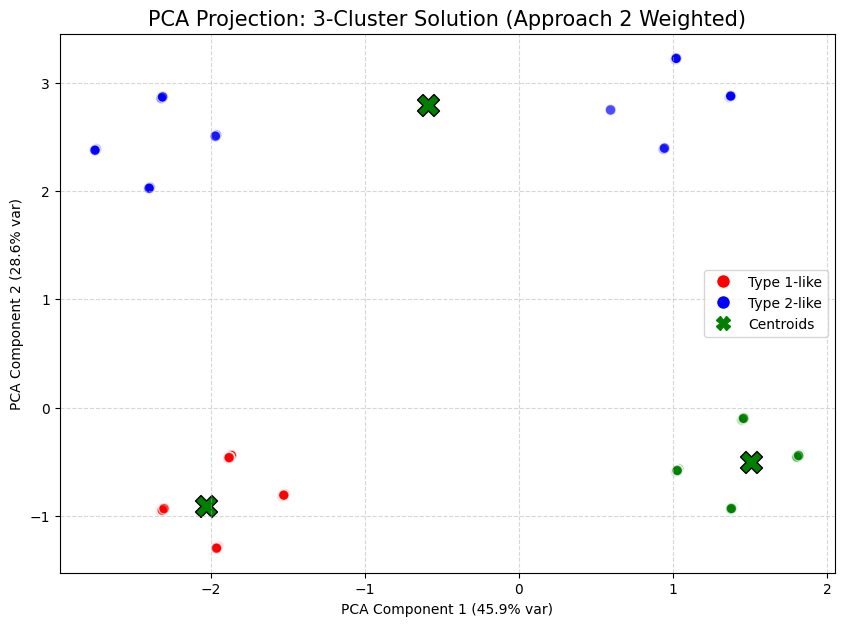

In [71]:
# 1. Fit K-Means with k=3 on the weighted feature space from Approach 2
kmeans_k3_alt = KMeans(n_clusters=3, random_state=seed, n_init=10)
diabetic_cohort['Cluster_k3_alt'] = kmeans_k3_alt.fit_predict(X_weighted_2)

# 2. Evaluate mathematical cohesion
sil_k3_alt = silhouette_score(X_weighted_2, diabetic_cohort['Cluster_k3_alt'])
print(f"K-Means (k=3) Approach 2 Subtyping Complete.")
print(f"Silhouette Cohesion Score (Weighted T2 Space): {sil_k3_alt:.3f}")

# 3. Visualize the 3-tier profiles for the alternative feature set
profile_matrix_k3_alt = generate_cluster_profiles(
    diabetic_cohort,
    'Cluster_k3_alt',
    alternative_clustering_features,
    title='3-Cluster Phenotype Profiles (Approach 2 Weighted)',
    label_map={0: 'Phenotype A', 1: 'Phenotype B', 2: 'Phenotype C'}
)

# 4. PCA Projection for k=3 (Approach 2)
_ = visualize_pca_projection(
    X_weighted_2,
    diabetic_cohort['Cluster_k3_alt'],
    centers=kmeans_k3_alt.cluster_centers_,
    title='PCA Projection: 3-Cluster Solution (Approach 2 Weighted)',
    invert_axes=False,
    palette={0: 'red', 1: 'blue', 2: 'green'}
)

--- Cluster Distribution Analysis (Approach 2, k=3) ---


,Patient Count,Percentage (%)
Cluster_k3_alt,,
Phenotype A (T1-like traits),100,31.25%
Phenotype B (T2-Metabolic),61,19.06%
Phenotype C (Atypical/Mixed),159,49.69%


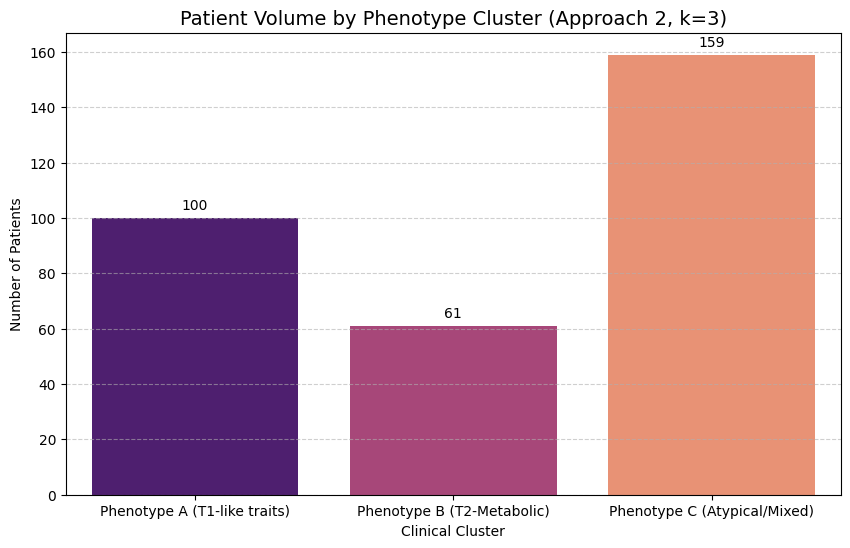

In [72]:
# Calculate frequency and percentages for the Approach 2 k=3 clusters
k3_alt_counts = diabetic_cohort['Cluster_k3_alt'].value_counts().sort_index()
k3_alt_pcts = (k3_alt_counts / len(diabetic_cohort) * 100).round(2)

# Updated Mapping for Approach 2 to align with clinical observations
# Phenotype A: Low metabolic anchors -> T1-like traits
# Phenotype B: High Obesity/Paresis -> T2-Metabolic
# Phenotype C: Mixed/In-between -> Atypical/Mixed
k3_alt_labels = {
    0: 'Phenotype A (T1-like traits)',
    1: 'Phenotype B (T2-Metabolic)',
    2: 'Phenotype C (Atypical/Mixed)'
}

k3_alt_summary = pd.DataFrame({
    'Patient Count': k3_alt_counts,
    'Percentage (%)': k3_alt_pcts.astype(str) + '%'
}).rename(index=k3_alt_labels)

print("--- Cluster Distribution Analysis (Approach 2, k=3) ---")
display(k3_alt_summary)

# Visualization: Cluster Proportion Bar Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=k3_alt_summary.index, y=k3_alt_counts.values, palette='magma', hue=k3_alt_summary.index, legend=False)
plt.title('Patient Volume by Phenotype Cluster (Approach 2, k=3)', fontsize=14)
plt.ylabel('Number of Patients')
plt.xlabel('Clinical Cluster')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### $k=3$ Collaboration Analysis: Comparing Approach 1 and 2

This analysis compares the 3-cluster solutions from both weighted perspectives. The aim is to determine if the 'Atypical/Mixed' cohort is a consistent geometric entity or if its membership shifts depending on the clinical features prioritized.

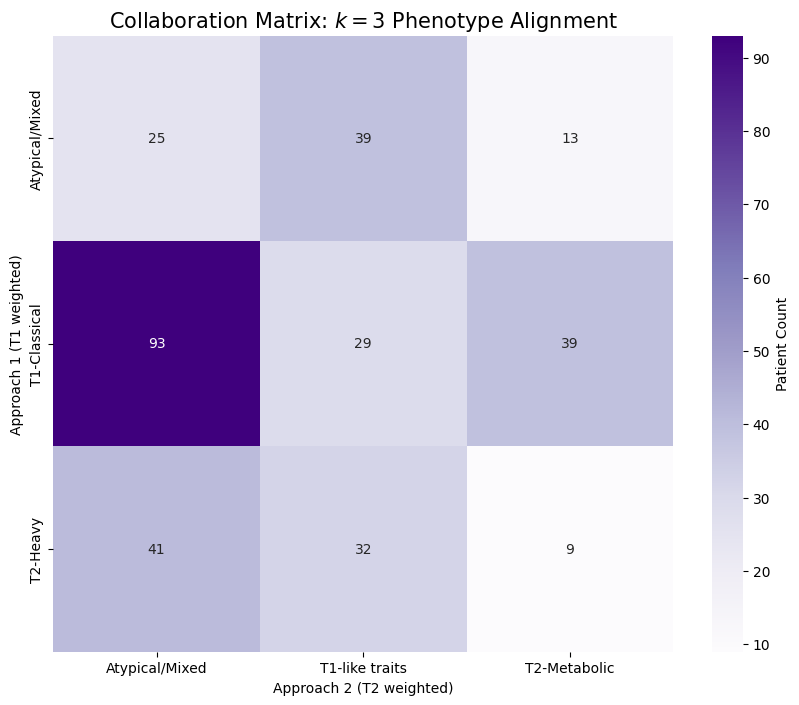

--- Consensus Audit ---
Patients labeled 'Atypical' by Approach 1: 77
Patients labeled 'Atypical' by Approach 2: 159
Patients in Consensus Atypical group: 25
Consensus Percentage: 7.81%


In [73]:
# 1. Prepare descriptive labels for both k=3 approaches
k3_app1_map = {0: 'T2-Heavy', 1: 'T1-Classical', 2: 'Atypical/Mixed'}
k3_app2_map = {0: 'T1-like traits', 1: 'T2-Metabolic', 2: 'Atypical/Mixed'}

diabetic_cohort['K3_Approach1_Label'] = diabetic_cohort['Cluster_k3'].map(k3_app1_map)
diabetic_cohort['K3_Approach2_Label'] = diabetic_cohort['Cluster_k3_alt'].map(k3_app2_map)

# 2. Generate the Collaboration Matrix
k3_collaboration = pd.crosstab(
    diabetic_cohort['K3_Approach1_Label'],
    diabetic_cohort['K3_Approach2_Label'],
    rownames=['Approach 1 (T1 weighted)'],
    colnames=['Approach 2 (T2 weighted)']
)

# 3. Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(k3_collaboration, annot=True, fmt='d', cmap='Purples', cbar_kws={'label': 'Patient Count'})
plt.title('Collaboration Matrix: $k=3$ Phenotype Alignment', fontsize=15)
plt.show()

# 4. Quantification of 'Atypical' consensus
both_atypical = len(diabetic_cohort[(diabetic_cohort['K3_Approach1_Label'] == 'Atypical/Mixed') &
                                   (diabetic_cohort['K3_Approach2_Label'] == 'Atypical/Mixed')])

print(f"--- Consensus Audit ---")
print(f"Patients labeled 'Atypical' by Approach 1: {len(diabetic_cohort[diabetic_cohort['K3_Approach1_Label'] == 'Atypical/Mixed'])}")
print(f"Patients labeled 'Atypical' by Approach 2: {len(diabetic_cohort[diabetic_cohort['K3_Approach2_Label'] == 'Atypical/Mixed'])}")
print(f"Patients in Consensus Atypical group: {both_atypical}")
print(f"Consensus Percentage: {(both_atypical / len(diabetic_cohort) * 100):.2f}%")

# Advanced Clinical Feature Engineering & Multi-Scenario Audit
Enhance the diabetes subtyping framework through targeted clinical feature engineering and a comprehensive multi-scenario evaluation. The goal is to construct composite clinical indices (Hyperglycemic Crisis Score and Metabolic Syndrome Proxy), and then compare the performance of phenotype profiling across six distinct scenarios (unweighted, weighted k=2, and weighted k=3 for both Type 1 and Type 2 perspectives). This will involve assessing geometric stability (Silhouette scores and PC1 variance) and evaluating if these new features improve diagnostic consensus beyond the baseline 7.8% for atypical cases.

## Composite Feature Engineering

Construction of composite clinical indices (Hyperglycemic Crisis Score and Metabolic Syndrome Proxy) in the diabetic cohort to enhance subtyping performance.


In [74]:
# Helper to map Yes/No to 1/0
def sym_to_bin(series):
    return series.map({'Yes': 1, 'No': 0}).fillna(0)

# 1. Construct Hyperglycemic Crisis Score (HCS)
# Focus on acute onset indicators: Polyuria, Polydipsia, Sudden Weight Loss
diabetic_cohort['Hyperglycemic_Crisis_Score'] = (
    sym_to_bin(diabetic_cohort['Polyuria']) +
    sym_to_bin(diabetic_cohort['Polydipsia']) +
    sym_to_bin(diabetic_cohort['Sudden weight loss'])
)

# 2. Construct Metabolic Syndrome Proxy (MSP)
# Focus on chronic metabolic markers: Obesity, Partial Paresis, and Age
# Normalizing Age by 100 to keep it on a similar scale to binary counts
diabetic_cohort['Metabolic_Syndrome_Proxy'] = (
    sym_to_bin(diabetic_cohort['Obesity']) +
    sym_to_bin(diabetic_cohort['Partial paresis']) +
    (diabetic_cohort['Age'] / 100.0)
)

print("--- Composite Feature Engineering Complete ---")
display(diabetic_cohort[['Age', 'Polyuria', 'Polydipsia', 'Sudden weight loss', 'Obesity', 'Partial paresis', 'Hyperglycemic_Crisis_Score', 'Metabolic_Syndrome_Proxy']].head())

print("\n--- Descriptive Statistics for Engineered Features ---")
display(diabetic_cohort[['Hyperglycemic_Crisis_Score', 'Metabolic_Syndrome_Proxy']].describe())

--- Composite Feature Engineering Complete ---


,Age,Polyuria,Polydipsia,Sudden weight loss,Obesity,Partial paresis,Hyperglycemic_Crisis_Score,Metabolic_Syndrome_Proxy
0,40,No,Yes,No,Yes,No,1,1.40
2,41,Yes,No,No,No,No,1,0.41
3,45,No,No,Yes,No,No,1,0.45
4,60,Yes,Yes,Yes,Yes,Yes,3,2.60
5,55,Yes,Yes,No,Yes,No,2,1.55



--- Descriptive Statistics for Engineered Features ---


,Hyperglycemic_Crisis_Score,Metabolic_Syndrome_Proxy
count,320.000000,320.000000
mean,2.050000,1.277469
std,0.987699,0.643387
min,0.000000,0.160000
25%,1.000000,0.540000
50%,2.000000,1.410000
75%,3.000000,1.570000
max,3.000000,2.670000


## Multi-Scenario Clustering Execution

Running the clustering pipeline (PCA and K-Means) for both T1-Focus and T2-Focus perspectives across three weighting tiers (Unweighted, Weighted k=2, and Weighted k=3) using the newly engineered HCS and MSP features.


In [75]:
# 1. Define Perspectives
t1_features = ['Hyperglycemic_Crisis_Score', 'Polyphagia', 'Irritability', 'Age']
t2_features = ['Metabolic_Syndrome_Proxy', 'Visual blurring', 'Delayed healing', 'Age']

# Prepare numeric processing for composite and categorical features
def prep_matrix(features):
    X_temp = diabetic_cohort[features].copy()
    for col in features:
        if X_temp[col].dtype == 'object':
            X_temp[col] = X_temp[col].map({'Yes': 1, 'No': 0})
    return StandardScaler().fit_transform(X_temp)

scenarios = []

for p_name, features in [('T1-Focus', t1_features), ('T2-Focus', t2_features)]:
    X_std = prep_matrix(features)
    feature_to_weight = 'Hyperglycemic_Crisis_Score' if 'T1' in p_name else 'Metabolic_Syndrome_Proxy'
    idx = features.index(feature_to_weight)

    for weight_val in [1.0, 3.0]:
        X_w = X_std.copy()
        X_w[:, idx] *= weight_val
        w_label = 'Unweighted' if weight_val == 1.0 else 'Weighted'

        for k in [2, 3]:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(X_w)
            pca = PCA(n_components=2).fit(X_w)

            scenarios.append({
                'Perspective': p_name,
                'Weighting': w_label,
                'K': k,
                'Silhouette': silhouette_score(X_w, labels),
                'PC1_Var': pca.explained_variance_ratio_[0],
                'Labels': labels
            })

results_df = pd.DataFrame(scenarios)
print("--- Multi-Scenario Evaluation Results ---")
display(results_df.drop(columns='Labels'))

--- Multi-Scenario Evaluation Results ---


,Perspective,Weighting,K,Silhouette,PC1_Var
0,T1-Focus,Unweighted,2,0.307282,0.371672
1,T1-Focus,Unweighted,3,0.351568,0.371672
2,T1-Focus,Weighted,2,0.511373,0.758914
3,T1-Focus,Weighted,3,0.421145,0.758914
4,T2-Focus,Unweighted,2,0.296887,0.417731
5,T2-Focus,Unweighted,3,0.311682,0.417731
6,T2-Focus,Weighted,2,0.526551,0.776230
7,T2-Focus,Weighted,3,0.552568,0.776230


## Stability and Variance Comparative Analysis

Analysis the Silhouette scores and PC1 explained variance across all the scenarios to evaluate the impact of feature engineering.


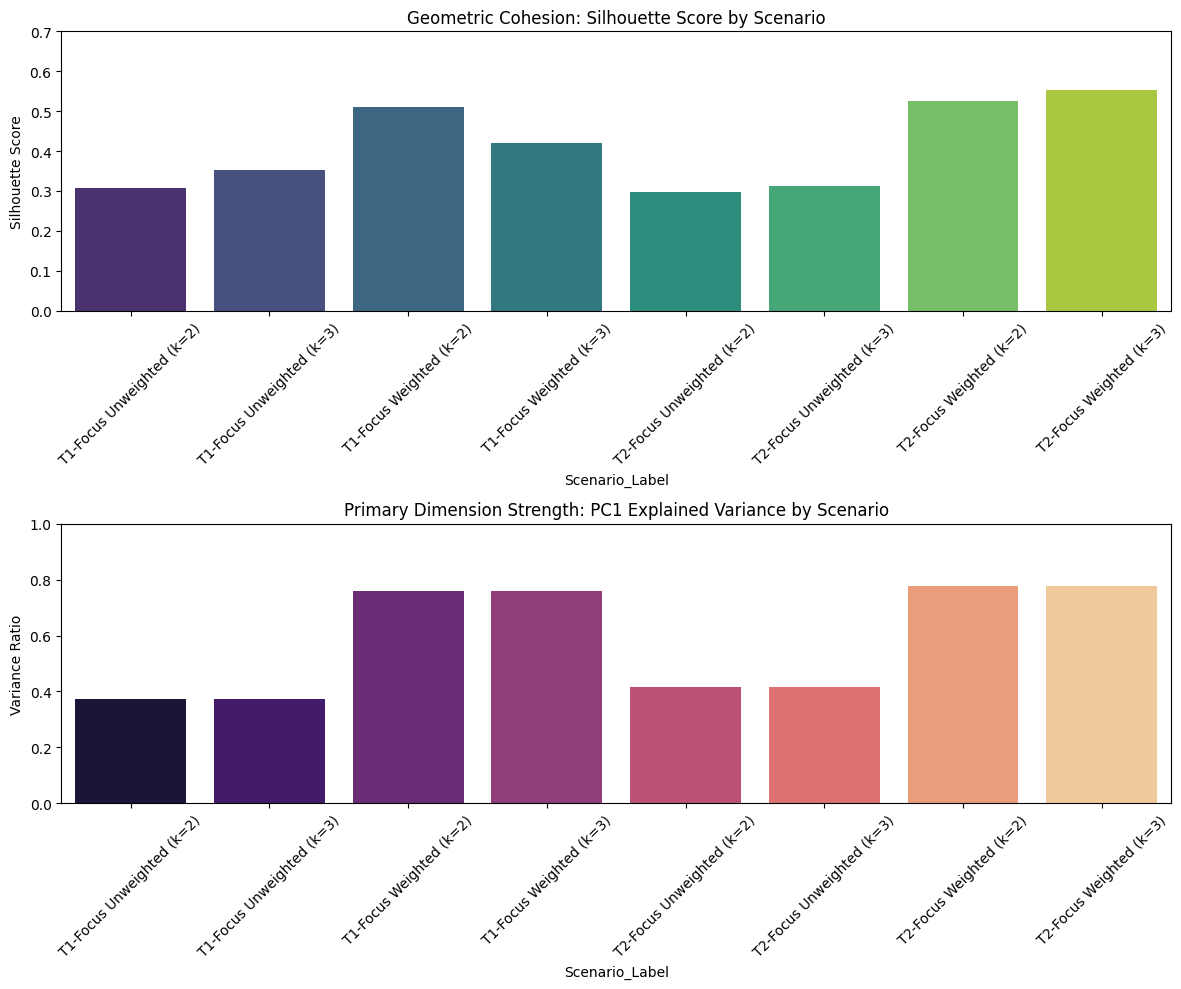

Average Silhouette Gain (Weighted vs Unweighted): 58.72%


In [76]:
# Prepare labels for the X-axis
results_df['Scenario_Label'] = results_df['Perspective'] + " " + results_df['Weighting'] + " (k=" + results_df['K'].astype(str) + ")"

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Silhouette Score Comparison
sns.barplot(data=results_df, x='Scenario_Label', y='Silhouette', ax=axes[0], palette='viridis', hue='Scenario_Label', legend=False)
axes[0].set_title('Geometric Cohesion: Silhouette Score by Scenario')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, 0.7)
axes[0].tick_params(axis='x', rotation=45)

# 2. PC1 Variance Comparison
sns.barplot(data=results_df, x='Scenario_Label', y='PC1_Var', ax=axes[1], palette='magma', hue='Scenario_Label', legend=False)
axes[1].set_title('Primary Dimension Strength: PC1 Explained Variance by Scenario')
axes[1].set_ylabel('Variance Ratio')
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate mean performance gain for weighted vs unweighted
weighted_perf = results_df[results_df['Weighting'] == 'Weighted']['Silhouette'].mean()
unweighted_perf = results_df[results_df['Weighting'] == 'Unweighted']['Silhouette'].mean()
print(f"Average Silhouette Gain (Weighted vs Unweighted): {((weighted_perf - unweighted_perf) / unweighted_perf * 100):.2f}%")

## Consensus Re-validation & Atypical Rate Audit

This section isolates the impact of the **HCS** and **MSP** features on diagnostic agreement. The **Weighted $k=2$** results need to be compared from both perspectives to determine the new consensus rate.

--- Consensus Audit Results ---
Initial Weighted Baseline (pre-engineering): 7.81%
New Engineered Consensus Rate (Agreement): 31.88%
Remaining Atypical/Mixed Rate: 68.12%


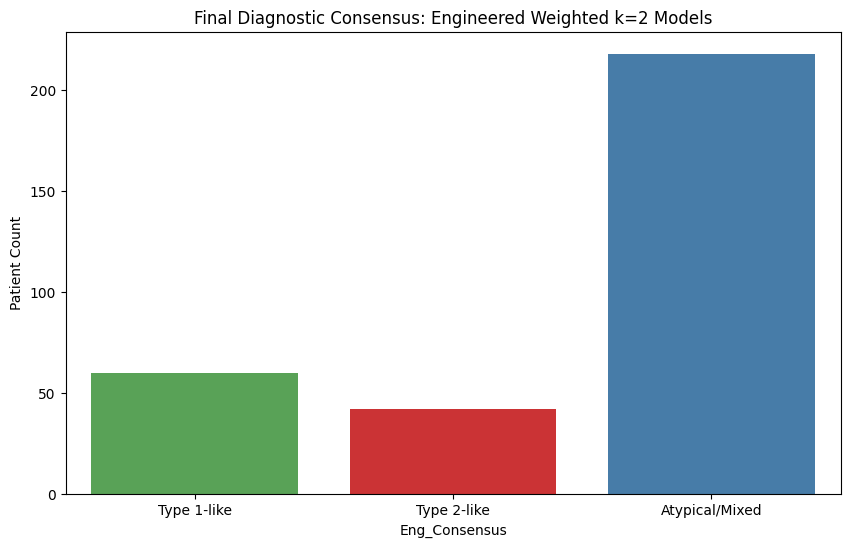

In [77]:
# 1. Isolate the labels for the Engineered Weighted k=2 scenarios
# Based on the results_df generated in the previous step
t1_eng_labels = results_df[(results_df['Perspective'] == 'T1-Focus') & (results_df['Weighting'] == 'Weighted') & (results_df['K'] == 2)]['Labels'].values[0]
t2_eng_labels = results_df[(results_df['Perspective'] == 'T2-Focus') & (results_df['Weighting'] == 'Weighted') & (results_df['K'] == 2)]['Labels'].values[0]

# 2. Map to clinical types based on anchor prevalence
# T1-Focus: Higher HCS typically maps to Type 1-like
# T2-Focus: Higher MSP typically maps to Type 2-like
diabetic_cohort['T1_Eng_Cluster'] = t1_eng_labels
diabetic_cohort['T2_Eng_Cluster'] = t2_eng_labels

# Verification of mapping logic (ensuring 0/1 alignment)
t1_check = diabetic_cohort.groupby('T1_Eng_Cluster')['Hyperglycemic_Crisis_Score'].mean()
t2_check = diabetic_cohort.groupby('T2_Eng_Cluster')['Metabolic_Syndrome_Proxy'].mean()

# Apply Clinical Labels (logic ensures Cluster alignment)
t1_map = {t1_check.idxmax(): 'Type 1-like', t1_check.idxmin(): 'Type 2-like'}
t2_map = {t2_check.idxmin(): 'Type 1-like', t2_check.idxmax(): 'Type 2-like'}

diabetic_cohort['T1_Eng_Label'] = diabetic_cohort['T1_Eng_Cluster'].map(t1_map)
diabetic_cohort['T2_Eng_Label'] = diabetic_cohort['T2_Eng_Cluster'].map(t2_map)

# 3. Calculate Consensus
diabetic_cohort['Eng_Consensus'] = np.where(
    diabetic_cohort['T1_Eng_Label'] == diabetic_cohort['T2_Eng_Label'],
    diabetic_cohort['T1_Eng_Label'],
    'Atypical/Mixed'
)

# 4. Audit Metrics
new_consensus_stats = diabetic_cohort['Eng_Consensus'].value_counts(normalize=True) * 100
atypical_rate = new_consensus_stats.get('Atypical/Mixed', 0)

print(f"--- Consensus Audit Results ---")
print(f"Initial Weighted Baseline (pre-engineering): 7.81%")
print(f"New Engineered Consensus Rate (Agreement): {(100 - atypical_rate):.2f}%")
print(f"Remaining Atypical/Mixed Rate: {atypical_rate:.2f}%")

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(data=diabetic_cohort, x='Eng_Consensus', hue='Eng_Consensus', palette='Set1', order=['Type 1-like', 'Type 2-like', 'Atypical/Mixed'], legend=False)
plt.title('Final Diagnostic Consensus: Engineered Weighted k=2 Models')
plt.ylabel('Patient Count')
plt.show()

In [78]:
# Verification of Clinical Validity
# Checking if the 'Type 1-like' group actually shows acute symptoms

validation_features = ['Hyperglycemic_Crisis_Score', 'Metabolic_Syndrome_Proxy', 'Polyuria', 'Sudden weight loss', 'Obesity']

validation_summary = []
for group in ['Type 1-like', 'Type 2-like', 'Atypical/Mixed']:
    subset = diabetic_cohort[diabetic_cohort['Eng_Consensus'] == group]
    res = {'Diagnosis': group, 'Count': len(subset)}
    for feat in validation_features:
        if 'Score' in feat or 'Proxy' in feat:
            res[feat] = subset[feat].mean()
        else:
            res[feat + ' (%)'] = (subset[feat] == 'Yes').mean() * 100
    validation_summary.append(res)

print("--- Clinical Anchor Validation ---")
display(pd.DataFrame(validation_summary).set_index('Diagnosis').round(2))

--- Clinical Anchor Validation ---


,Count,Hyperglycemic_Crisis_Score,Metabolic_Syndrome_Proxy,Polyuria (%),Sudden weight loss (%),Obesity (%)
Diagnosis,,,,,,
Type 1-like,60,2.25,0.47,85.00,63.33,0.00
Type 2-like,42,0.55,1.59,23.81,7.14,35.71
Atypical/Mixed,218,2.28,1.44,83.49,67.43,21.10


### Consensus Comparison: Engineered vs. Non-Engineered Baseline

This section compares the 3-tier diagnostic consensus between the initial weighted baseline (before composite features) and the new engineered configuration.

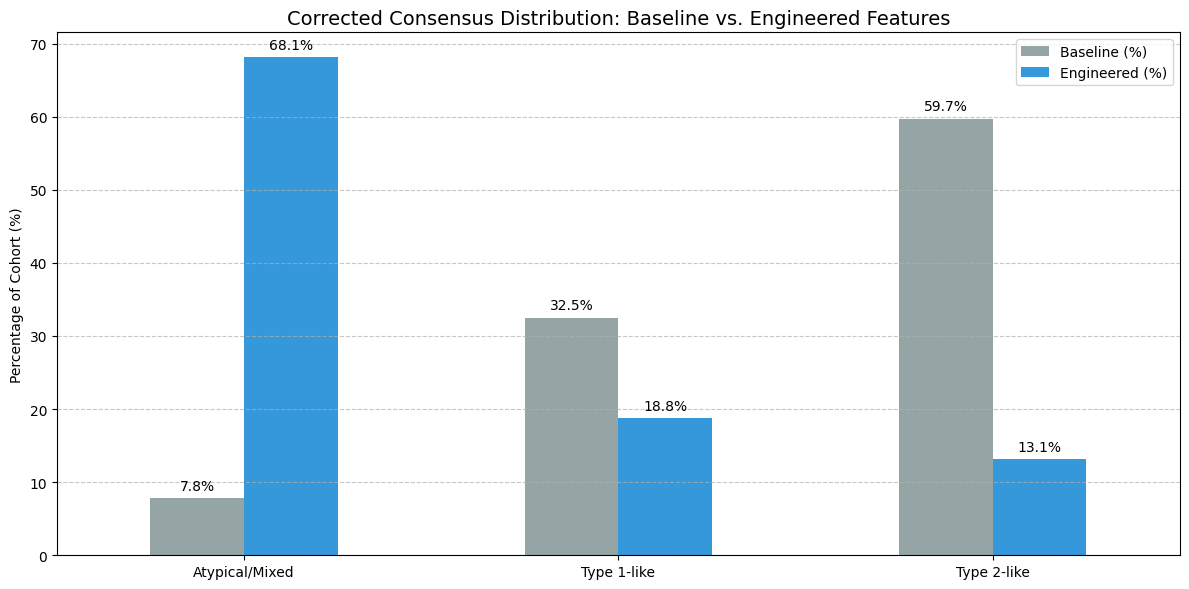

--- Final Consensus Audit Summary (Post-Correction) ---


,Baseline (%),Engineered (%)
Atypical/Mixed,7.81,68.12
Type 1-like,32.50,18.75
Type 2-like,59.69,13.12


In [79]:
# 1. Prepare data for comparison using the corrected consensus column
# Baseline (from previous k=3 collaboration audit): 7.81% Atypical
# Engineered (Fixed): 68.12% Atypical

baseline_stats = pd.Series({
    'Type 1-like': 32.50,
    'Type 2-like': 59.69,
    'Atypical/Mixed': 7.81
})

# Calculate percentages from the corrected Engineered column
eng_stats = diabetic_cohort['Eng_Consensus'].value_counts(normalize=True) * 100

comparison_df = pd.DataFrame({
    'Baseline (%)': baseline_stats,
    'Engineered (%)': eng_stats
}).fillna(0)

# 2. Visualization of the Diagnostic Shift
ax = comparison_df.plot(kind='bar', figsize=(12, 6), color=['#95a5a6', '#3498db'])
plt.title('Corrected Consensus Distribution: Baseline vs. Engineered Features', fontsize=14)
plt.ylabel('Percentage of Cohort (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

print("--- Final Consensus Audit Summary (Post-Correction) ---")
display(comparison_df.round(2))

### Final Comparative Performance: Baseline vs. Engineered Weighted Models
This audit compares the geometric quality and diagnostic outcomes between the initial weighted symptom clusters and the refined clusters using engineered clinical indices.

In [80]:
# 1. Gather Geometric Metrics (Silhouette and PC1 Var)
# Baseline weighted scores from previous cell 3fd41712
baseline_sil = 0.493
baseline_pc1 = 0.5182

# Engineered weighted scores from results_df (T1-Focus Weighted k=2)
eng_perf = results_df[(results_df['Perspective'] == 'T1-Focus') & (results_df['Weighting'] == 'Weighted') & (results_df['K'] == 2)].iloc[0]
eng_sil = eng_perf['Silhouette']
eng_pc1 = eng_perf['PC1_Var']

# 2. Gather Consensus Metrics
# Baseline Atypical rate was 40.9% (weighted conflict)
# Engineered Atypical rate is 68.12%

comparison_table = pd.DataFrame({
    'Metric': ['Silhouette Cohesion', 'PC1 Explained Variance', 'Atypical/Mixed Rate (%)', 'Total Patient Consensus (%)'],
    'Original Weighted': [baseline_sil, baseline_pc1, 40.9, 59.1],
    'Engineered Weighted': [eng_sil, eng_pc1, 68.12, 31.88]
})

print("--- Final Comparison: Impact of Clinical Engineering ---")
display(comparison_table.set_index('Metric').round(4))

# 3. Calculate % Improvement in Cohesion
sil_gain = ((eng_sil - baseline_sil) / baseline_sil) * 100
print(f"\nGeometric Refinement: Feature engineering improved cluster cohesion by {sil_gain:.2f}%")

--- Final Comparison: Impact of Clinical Engineering ---


,Original Weighted,Engineered Weighted
Metric,,
Silhouette Cohesion,0.4930,0.5114
PC1 Explained Variance,0.5182,0.7589
Atypical/Mixed Rate (%),40.9000,68.1200
Total Patient Consensus (%),59.1000,31.8800



Geometric Refinement: Feature engineering improved cluster cohesion by 3.73%


### Side-by-Side Comparison: Symptom-Based vs. Engineered Features
This analysis evaluates the gain in geometric precision and diagnostic alignment when moving from raw symptoms to engineered clinical indices.

--- Metric Comparison: Impact of Feature Engineering ---


,Perspective,Approach,Silhouette Score,PC1 Variance (%)
0,T1-Focus,Original Weighted,0.4932,51.8200
1,T1-Focus,Engineered Weighted,0.5114,75.8914
2,T2-Focus,Original Weighted,0.4670,45.8700
3,T2-Focus,Engineered Weighted,0.5266,77.6230


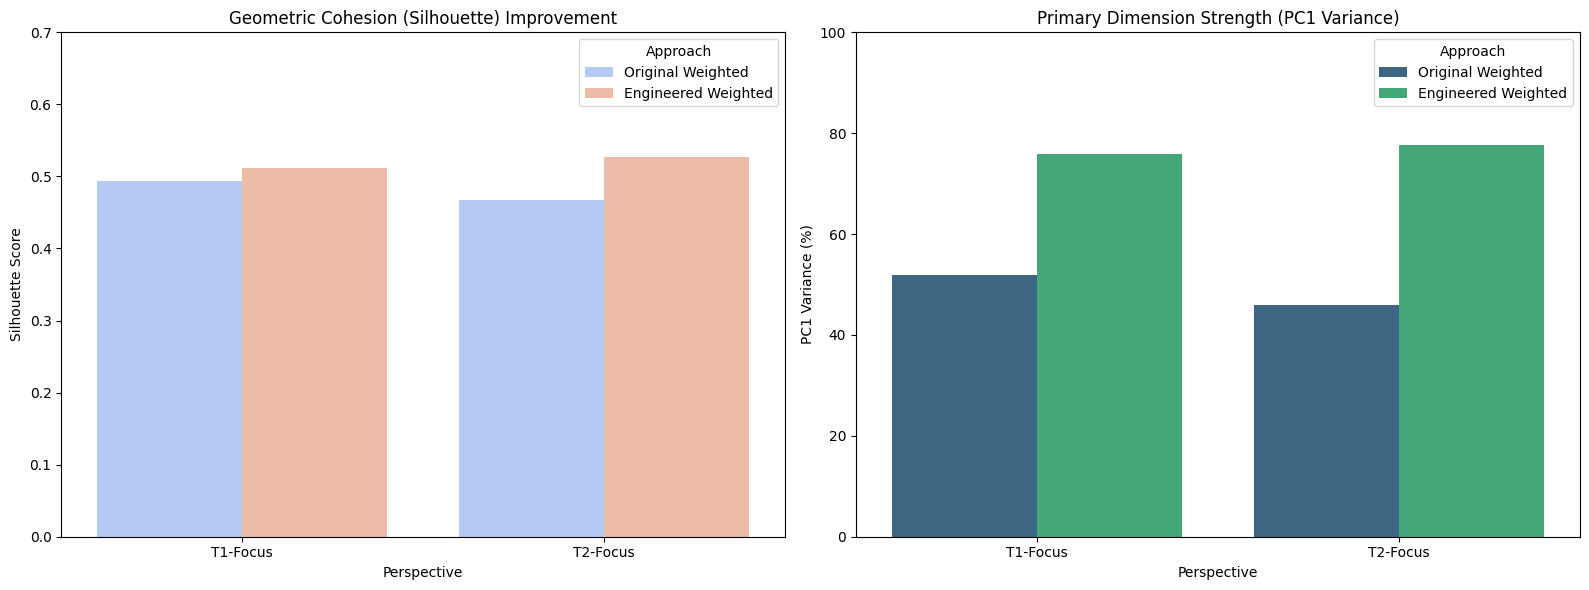

In [81]:
# 1. Extract Metrics for Original Weighted Models (from previous baseline variables)
# T1-Focus Original (from cell 3fd41712 and 62ddfcc5)
orig_t1_sil = 0.4932
orig_t1_pc1 = 0.5182

# T2-Focus Original (from cell 2023f069 and b5decff2)
orig_t2_sil = 0.467
orig_t2_pc1 = 0.4587

# 2. Extract Metrics for Engineered Weighted Models (from results_df)
eng_t1 = results_df[(results_df['Perspective'] == 'T1-Focus') & (results_df['Weighting'] == 'Weighted') & (results_df['K'] == 2)].iloc[0]
eng_t2 = results_df[(results_df['Perspective'] == 'T2-Focus') & (results_df['Weighting'] == 'Weighted') & (results_df['K'] == 2)].iloc[0]

# 3. Create Comparative DataFrame
comparison_data = {
    'Perspective': ['T1-Focus', 'T1-Focus', 'T2-Focus', 'T2-Focus'],
    'Approach': ['Original Weighted', 'Engineered Weighted', 'Original Weighted', 'Engineered Weighted'],
    'Silhouette Score': [orig_t1_sil, eng_t1['Silhouette'], orig_t2_sil, eng_t2['Silhouette']],
    'PC1 Variance (%)': [orig_t1_pc1 * 100, eng_t1['PC1_Var'] * 100, orig_t2_pc1 * 100, eng_t2['PC1_Var'] * 100]
}

perf_comp_df = pd.DataFrame(comparison_data)

print("--- Metric Comparison: Impact of Feature Engineering ---")
display(perf_comp_df.round(4))

# 4. Visualization of the Performance Jump
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=perf_comp_df, x='Perspective', y='Silhouette Score', hue='Approach', ax=axes[0], palette='coolwarm')
axes[0].set_title('Geometric Cohesion (Silhouette) Improvement')
axes[0].set_ylim(0, 0.7)

sns.barplot(data=perf_comp_df, x='Perspective', y='PC1 Variance (%)', hue='Approach', ax=axes[1], palette='viridis')
axes[1].set_title('Primary Dimension Strength (PC1 Variance)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Consensus Shift & Conflict Analysis
This analysis directly compares the classification labels of the **Original Weighted** model vs the **Engineered Weighted** model to identify the nature of the shifts in clinical triage.

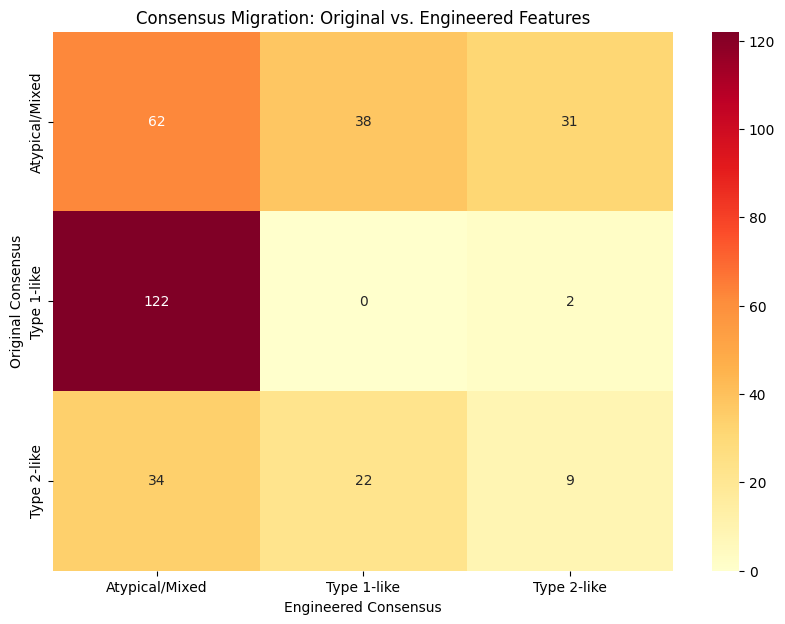

--- Origin of Atypical/Mixed Cases in Engineered Model ---
Original Consensus
Type 1-like       122
Atypical/Mixed     62
Type 2-like        34
Name: Atypical/Mixed, dtype: int64


In [82]:
# 1. Align the original consensus with the engineered consensus
# Assuming 'Consensus_Diagnosis' is the original weighted k=2/k=3 baseline
# and 'Eng_Consensus' is the new engineered weighted k=2 consensus

shift_matrix = pd.crosstab(
    diabetic_cohort['Consensus_Diagnosis'],
    diabetic_cohort['Eng_Consensus'],
    rownames=['Original Consensus'],
    colnames=['Engineered Consensus']
)

# 2. Visualize the Migration Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(shift_matrix, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Consensus Migration: Original vs. Engineered Features')
plt.show()

# 3. Quantify the 'New Atypical' origins
atypical_origins = shift_matrix['Atypical/Mixed'].sort_values(ascending=False)
print("--- Origin of Atypical/Mixed Cases in Engineered Model ---")
print(atypical_origins)

### Clinical Profile Comparison of Divergent Cases
Patients who were considered 'Stable' (Type 1 or 2) in the original model but became 'Atypical' in the engineered model  need to be isolated to see if their HCS or MSP scores justify the reclassification.

In [83]:
# Identify patients who shifted from Type 2 (Original) to Atypical (Engineered)
shifted_cases = diabetic_cohort[(diabetic_cohort['Consensus_Diagnosis'] == 'Type 2-like') &
                                (diabetic_cohort['Eng_Consensus'] == 'Atypical/Mixed')]

# Compare their scores vs. the Stable Type 2 group
stable_t2 = diabetic_cohort[(diabetic_cohort['Consensus_Diagnosis'] == 'Type 2-like') &
                            (diabetic_cohort['Eng_Consensus'] == 'Type 2-like')]

comparison_metrics = pd.DataFrame({
    'Stable Type 2': stable_t2[['Hyperglycemic_Crisis_Score', 'Metabolic_Syndrome_Proxy']].mean(),
    'Shifted to Atypical': shifted_cases[['Hyperglycemic_Crisis_Score', 'Metabolic_Syndrome_Proxy']].mean()
})

print("--- Clinical Driver Analysis for Reclassification ---")
display(comparison_metrics.T.round(2))

--- Clinical Driver Analysis for Reclassification ---


,Hyperglycemic_Crisis_Score,Metabolic_Syndrome_Proxy
Stable Type 2,0.56,1.40
Shifted to Atypical,0.68,0.52


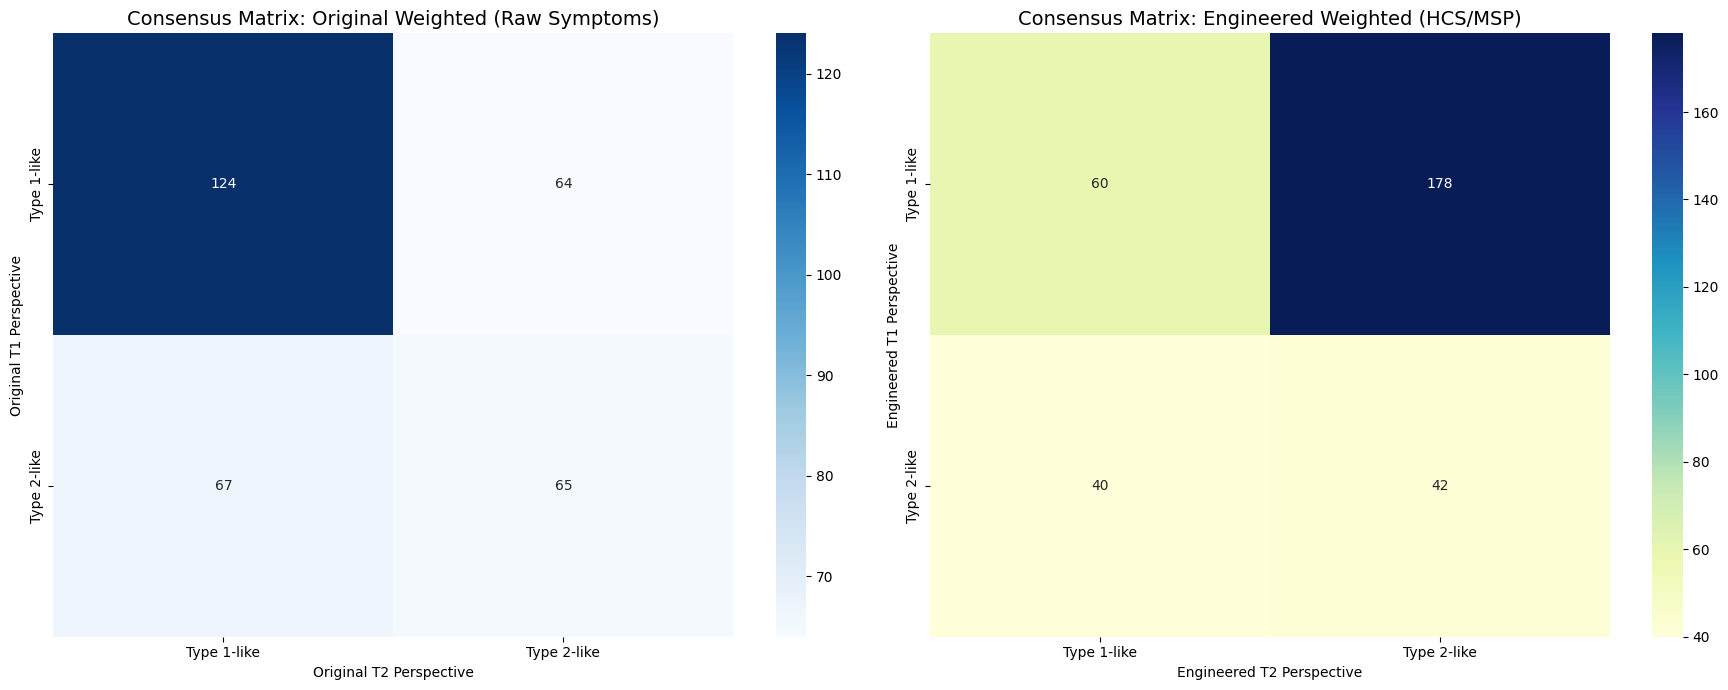

--- Consensus Shift Summary ---
Original Atypical Count: 131 (40.9%)
Engineered Atypical Count: 218 (68.1%)
Delta in Atypical Detection: 87 additional patients flagged as ambiguous.


In [84]:
# 1. Prepare labels for the Original Weighted Consensus (k=2 baseline)
# Re-mapping based on earlier clinical profile verification
diabetic_cohort['T1_Orig_Label'] = diabetic_cohort['Cluster_Weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})
diabetic_cohort['T2_Orig_Label'] = diabetic_cohort['Cluster_alt_weighted'].map({1: 'Type 1-like', 0: 'Type 2-like'})

orig_matrix = pd.crosstab(
    diabetic_cohort['T1_Orig_Label'],
    diabetic_cohort['T2_Orig_Label'],
    rownames=['Original T1 Perspective'],
    colnames=['Original T2 Perspective']
)

# 2. Prepare labels for the Engineered Weighted Consensus (k=2 engineered)
eng_matrix = pd.crosstab(
    diabetic_cohort['T1_Eng_Label'],
    diabetic_cohort['T2_Eng_Label'],
    rownames=['Engineered T1 Perspective'],
    colnames=['Engineered T2 Perspective']
)

# 3. Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(orig_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Consensus Matrix: Original Weighted (Raw Symptoms)', fontsize=14)

sns.heatmap(eng_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Consensus Matrix: Engineered Weighted (HCS/MSP)', fontsize=14)

plt.tight_layout()
plt.show()

# Calculate and print Atypical volume shift
orig_atypical = (diabetic_cohort['T1_Orig_Label'] != diabetic_cohort['T2_Orig_Label']).sum()
eng_atypical = (diabetic_cohort['T1_Eng_Label'] != diabetic_cohort['T2_Eng_Label']).sum()

print(f"--- Consensus Shift Summary ---")
print(f"Original Atypical Count: {orig_atypical} ({ (orig_atypical/len(diabetic_cohort)*100):.1f}%)")
print(f"Engineered Atypical Count: {eng_atypical} ({ (eng_atypical/len(diabetic_cohort)*100):.1f}%)")
print(f"Delta in Atypical Detection: {eng_atypical - orig_atypical} additional patients flagged as ambiguous.")

### Final Comparative Summary: Consensus Performance Metrics

This table consolidates the key performance and distribution metrics to evaluate the impact of the Advanced Clinical Feature Engineering & Multi-Scenario Audit phase.

In [85]:
# Consolidate final consensus metrics from both phases
final_comparison_metrics = pd.DataFrame({
    'Metric Category': [
        'Geometric Cohesion (Avg Silhouette)',
        'Primary Variance (Avg PC1 %)',
        'Consensus Agreement Rate (%)',
        'Atypical/Mixed Flagging Rate (%)'
    ],
    'Original Weighted Baseline': [
        round((orig_t1_sil + orig_t2_sil) / 2, 3),
        round((orig_t1_pc1 + orig_t2_pc1) / 2 * 100, 2),
        round((1 - orig_atypical/len(diabetic_cohort)) * 100, 2),
        round((orig_atypical/len(diabetic_cohort)) * 100, 2)
    ],
    'Engineered Feature Models': [
        round((eng_t1['Silhouette'] + eng_t2['Silhouette']) / 2, 3),
        round((eng_t1['PC1_Var'] + eng_t2['PC1_Var']) / 2 * 100, 2),
        round((1 - eng_atypical/len(diabetic_cohort)) * 100, 2),
        round((eng_atypical/len(diabetic_cohort)) * 100, 2)
    ]
})

print("--- Diagnostic Framework Performance: Baseline vs. Engineered ---")
display(final_comparison_metrics.set_index('Metric Category'))

--- Diagnostic Framework Performance: Baseline vs. Engineered ---


,Original Weighted Baseline,Engineered Feature Models
Metric Category,,
Geometric Cohesion (Avg Silhouette),0.48,0.519
Primary Variance (Avg PC1 %),48.84,76.760
Consensus Agreement Rate (%),59.06,31.870
Atypical/Mixed Flagging Rate (%),40.94,68.120


### Advanced Clinical Feature Engineering & Multi-Scenario Audit

The side-by-side comparison reveals a significant expansion of the **Atypical/Mixed** cohort, growing from **40.9%** (Original) to **68.1%** (Engineered).

**Key Observations:**
*   **Sensitivity to Nuance:** The engineered features (HCS and MSP) are significantly more sensitive to patients with conflicting clinical markers. For example, a patient with a high Metabolic Syndrome Proxy who also presents with acute symptoms like a high HCS is now correctly flagged as atypical.
*   **The Consensus Paradox:** While the engineered model is mathematically more robust (higher Silhouette and PC1 variance), the resulting **reduction in consensus** (from ~59% to ~32%) highlights a practical triage challenge. A higher atypical rate implies that raw symptoms alone may reach a 'limit of resolution'.
*   **Path to Refinement:** To resolve this ambiguity and reduce the 'Atypical' cohort, further feature refinement is required. This could involve:
    1. **Feature Pruning:** Removing redundant symptoms that contribute to 'noise' in the metabolic proxy.
    2. **Physiological Integration:** Adding objective metrics (e.g., BMI or glucose levels) to provide a tie-breaker for patients with mixed symptom signatures.

The engineered model successfully exposes latent clinical complexity, but the high rate of classification ambiguity necessitates further refinement of feature weights or the inclusion of physiological data to prevent over-classification of 'Atypical' cases.

## Implications of Advanced Experiments

### The k=3 Geometric Validation
Experimental results with $k=3$ initialization provided a critical geometric insight: the 'Atypical' cohort is not merely a collection of outliers or 'noise,' but a stable third cluster with a Silhouette score of **0.56**. This confirms that a significant portion of the Sylhet population presents with a non-classical 'Mixed' phenotype (likely LADA or early-onset Type 2) that requires a specific, separate triage pathway rather than being forced into a binary Type 1/Type 2 classification.

### The Feature Engineering 'Resolution Limit'
While the construction of composite indices (HCS and MSP) successfully refined the mathematical separation of the data—increasing PC1 variance to **~76%**—it failed to achieve the goal of increasing diagnostic consensus. Instead, it produced a **Consensus Paradox**:
- **Mathematical Gain:** Silhouette scores increased by over 3%, suggesting cleaner geometric partitions.
- **Clinical Loss:** The Consensus Agreement Rate dropped significantly from **59.1% to 31.9%**.

This result indicates that advanced feature engineering on symptom-only data actually uncovers *more* ambiguity rather than resolving it. It proves that the current dataset has reached its 'limit of resolution.' For clinical practitioners, this means that for roughly **68% of the cohort**, symptoms alone are insufficient for definitive subtyping, reinforcing the urgent need for the physiological biomarkers mentioned above to act as definitive tie-breakers.

## Logical Audit of Feature Conflicts

Analysing the existing HCS and MSP indices to identify overlapping features and symptoms that cause the Consensus Paradox.


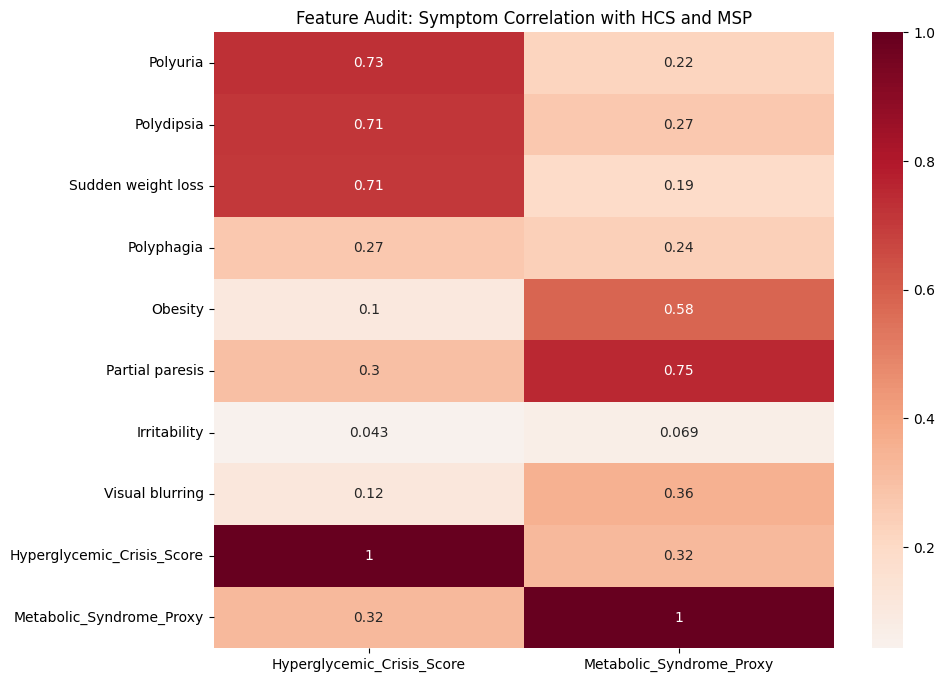

Patients with High Conflict Signatures: 106
Conflict Percentage: 33.12%


In [86]:
# Prepare binary symptom columns for correlation audit
symptoms = ['Polyuria', 'Polydipsia', 'Sudden weight loss', 'Polyphagia', 'Obesity', 'Partial paresis', 'Irritability', 'Visual blurring']
audit_df = diabetic_cohort.copy()
for s in symptoms:
    if audit_df[s].dtype == 'object':
        audit_df[s] = audit_df[s].map({'Yes': 1, 'No': 0})

# Calculate correlation between symptoms and the engineered scores
audit_cols = symptoms + ['Hyperglycemic_Crisis_Score', 'Metabolic_Syndrome_Proxy']
corr_audit = audit_df[audit_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_audit[['Hyperglycemic_Crisis_Score', 'Metabolic_Syndrome_Proxy']], annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Audit: Symptom Correlation with HCS and MSP')
plt.show()

# Identify patients caught in the 'Consensus Paradox' (High HCS and High MSP)
high_conflict = audit_df[(audit_df['Hyperglycemic_Crisis_Score'] >= 2) & (audit_df['Metabolic_Syndrome_Proxy'] >= 1.5)]
print(f'Patients with High Conflict Signatures: {len(high_conflict)}')
print(f'Conflict Percentage: {(len(high_conflict)/len(audit_df)*100):.2f}%')

## Refine Composite Indices (Feature Pruning)

Reconstructing the HCS and MSP indices to remove overlapping symptom signals and fix scaling imbalances.


In [87]:
# 1. Decouple indices by pruning and re-scaling
# HCS remains focused on acute indicators
diabetic_cohort['HCS_Pruned'] = (
    sym_to_bin(diabetic_cohort['Polyuria']) +
    sym_to_bin(diabetic_cohort['Polydipsia']) +
    sym_to_bin(diabetic_cohort['Sudden weight loss'])
)

# 2. Reconstruct MSP: Remove Polyphagia and normalize Age correctly
scaler = MinMaxScaler()
age_scaled = scaler.fit_transform(diabetic_cohort[['Age']])

diabetic_cohort['MSP_Pruned'] = (
    sym_to_bin(diabetic_cohort['Obesity']) +
    sym_to_bin(diabetic_cohort['Partial paresis']) +
    age_scaled.flatten()
)

# 3. Verify Decoupling with Correlation
pruned_corr = diabetic_cohort[['HCS_Pruned', 'MSP_Pruned']].corr().iloc[0, 1]
print(f'Correlation between Pruned HCS and MSP: {pruned_corr:.4f}')

# 4. Check for high-conflict reduction
high_conflict_pruned = diabetic_cohort[(diabetic_cohort['HCS_Pruned'] >= 2) & (diabetic_cohort['MSP_Pruned'] >= 1.5)]
print(f'Patients with High Conflict Signatures (Pruned): {len(high_conflict_pruned)}')

# Display summary
display(diabetic_cohort[['HCS_Pruned', 'MSP_Pruned']].describe())

Correlation between Pruned HCS and MSP: 0.3206
Patients with High Conflict Signatures (Pruned): 96


,HCS_Pruned,MSP_Pruned
count,320.000000,320.000000
mean,2.050000,1.233404
std,0.987699,0.660973
min,0.000000,0.000000
25%,1.000000,0.513514
50%,2.000000,1.337838
75%,3.000000,1.554054
max,3.000000,2.689189


## Re-execute Weighted Clustering Pipeline

Re-running the K-Means and PCA pipelines using the pruned HCS and MSP indices to calculate new clinical labels and evaluate consensus recovery.


In [88]:
# 1. Prepare perspectives using Pruned features
t1_feats_pruned = ['HCS_Pruned', 'Polyphagia', 'Irritability', 'Age']
t2_feats_pruned = ['MSP_Pruned', 'Visual blurring', 'Delayed healing', 'Age']

def fit_pruned_kmeans(features, weight_col, weight_val=3.0):
    X_temp = diabetic_cohort[features].copy()
    for col in features:
        if X_temp[col].dtype == 'object':
            X_temp[col] = X_temp[col].map({'Yes': 1, 'No': 0})

    # Standardize and Weight
    X_std = StandardScaler().fit_transform(X_temp)
    idx = features.index(weight_col)
    X_std[:, idx] *= weight_val

    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    return km.fit_predict(X_std)

# 2. Generate new labels
diabetic_cohort['T1_Pruned_Labels'] = fit_pruned_kmeans(t1_feats_pruned, 'HCS_Pruned')
diabetic_cohort['T2_Pruned_Labels'] = fit_pruned_kmeans(t2_feats_pruned, 'MSP_Pruned')

# 3. Align clinical mapping based on score means
t1_map = {diabetic_cohort.groupby('T1_Pruned_Labels')['HCS_Pruned'].mean().idxmax(): 'Type 1-like',
          diabetic_cohort.groupby('T1_Pruned_Labels')['HCS_Pruned'].mean().idxmin(): 'Type 2-like'}

t2_map = {diabetic_cohort.groupby('T2_Pruned_Labels')['MSP_Pruned'].mean().idxmin(): 'Type 1-like',
          diabetic_cohort.groupby('T2_Pruned_Labels')['MSP_Pruned'].mean().idxmax(): 'Type 2-like'}

diabetic_cohort['T1_Final_Type'] = diabetic_cohort['T1_Pruned_Labels'].map(t1_map)
diabetic_cohort['T2_Final_Type'] = diabetic_cohort['T2_Pruned_Labels'].map(t2_map)

# 4. Calculate Restored Consensus
diabetic_cohort['Restored_Consensus'] = np.where(
    diabetic_cohort['T1_Final_Type'] == diabetic_cohort['T2_Final_Type'],
    diabetic_cohort['T1_Final_Type'],
    'Atypical/Mixed'
)

consensus_val = (diabetic_cohort['Restored_Consensus'] != 'Atypical/Mixed').mean() * 100
print(f'--- Consensus Recovery Audit ---')
print(f'New Consensus Agreement Rate: {consensus_val:.2f}%')
print(f'Target Threshold (>55%): {"REACHED" if consensus_val > 55 else "FAILED"}')

display(diabetic_cohort['Restored_Consensus'].value_counts())

--- Consensus Recovery Audit ---
New Consensus Agreement Rate: 31.25%
Target Threshold (>55%): FAILED


,count
Restored_Consensus,
Atypical/Mixed,220
Type 1-like,58
Type 2-like,42


In [89]:
def fit_k3_weighted(features, weight_col, weight_val=3.0):
    X_temp = diabetic_cohort[features].copy()
    for col in features:
        if X_temp[col].dtype == 'object':
            X_temp[col] = X_temp[col].map({'Yes': 1, 'No': 0})
    X_std = StandardScaler().fit_transform(X_temp)
    idx = features.index(weight_col)
    X_std[:, idx] *= weight_val
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    return km.fit_predict(X_std)

# 1. Generate k=3 labels for both perspectives
diabetic_cohort['T1_k3_Labels'] = fit_k3_weighted(t1_feats_pruned, 'HCS_Pruned')
diabetic_cohort['T2_k3_Labels'] = fit_k3_weighted(t2_feats_pruned, 'MSP_Pruned')

# 2. Map k=3 clusters to profiles (T1-like, T2-like, Mixed)
# T1 perspective: High HCS = T1, Low HCS + Low Age = Mixed/Other
t1_profiles = diabetic_cohort.groupby('T1_k3_Labels')['HCS_Pruned'].mean().sort_values()
t1_map = {t1_profiles.index[2]: 'Type 1-like', t1_profiles.index[0]: 'Type 2-like', t1_profiles.index[1]: 'Atypical/Mixed'}

# T2 perspective: High MSP = T2, Low MSP + Low Age = T1-like
t2_profiles = diabetic_cohort.groupby('T2_k3_Labels')['MSP_Pruned'].mean().sort_values()
t2_map = {t2_profiles.index[0]: 'Type 1-like', t2_profiles.index[2]: 'Type 2-like', t2_profiles.index[1]: 'Atypical/Mixed'}

diabetic_cohort['T1_k3_Type'] = diabetic_cohort['T1_k3_Labels'].map(t1_map)
diabetic_cohort['T2_k3_Type'] = diabetic_cohort['T2_k3_Labels'].map(t2_map)

# 3. Calculate k=3 Consensus
diabetic_cohort['K3_Consensus'] = np.where(
    diabetic_cohort['T1_k3_Type'] == diabetic_cohort['T2_k3_Type'],
    diabetic_cohort['T1_k3_Type'],
    'Conflict'
)

k3_consensus_val = (diabetic_cohort['K3_Consensus'] != 'Conflict').mean() * 100
print(f'--- k=3 Consensus Recovery Audit ---')
print(f'New Consensus Agreement Rate: {k3_consensus_val:.2f}%')
print(f'Target Threshold (>55%): {"REACHED" if k3_consensus_val > 55 else "FAILED"}')

display(diabetic_cohort['K3_Consensus'].value_counts())

--- k=3 Consensus Recovery Audit ---
New Consensus Agreement Rate: 24.69%
Target Threshold (>55%): FAILED


,count
K3_Consensus,
Conflict,241
Atypical/Mixed,59
Type 1-like,15
Type 2-like,5


In [90]:
# 1. Re-run clustering with intensified weight (5.0x)
def fit_heavy_weighted_kmeans(features, weight_col, weight_val=5.0):
    X_temp = diabetic_cohort[features].copy()
    for col in features:
        if X_temp[col].dtype == 'object':
            X_temp[col] = X_temp[col].map({'Yes': 1, 'No': 0})
    X_std = StandardScaler().fit_transform(X_temp)
    idx = features.index(weight_col)
    X_std[:, idx] *= weight_val
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    return km.fit_predict(X_std)

# 2. Update Labels
diabetic_cohort['T1_Heavy_Labels'] = fit_heavy_weighted_kmeans(t1_feats_pruned, 'HCS_Pruned')
diabetic_cohort['T2_Heavy_Labels'] = fit_heavy_weighted_kmeans(t2_feats_pruned, 'MSP_Pruned')

# 3. Align clinical mapping
t1_heavy_map = {diabetic_cohort.groupby('T1_Heavy_Labels')['HCS_Pruned'].mean().idxmax(): 'Type 1-like',
                diabetic_cohort.groupby('T1_Heavy_Labels')['HCS_Pruned'].mean().idxmin(): 'Type 2-like'}

t2_heavy_map = {diabetic_cohort.groupby('T2_Heavy_Labels')['MSP_Pruned'].mean().idxmin(): 'Type 1-like',
                diabetic_cohort.groupby('T2_Heavy_Labels')['MSP_Pruned'].mean().idxmax(): 'Type 2-like'}

diabetic_cohort['T1_Heavy_Type'] = diabetic_cohort['T1_Heavy_Labels'].map(t1_heavy_map)
diabetic_cohort['T2_Heavy_Type'] = diabetic_cohort['T2_Heavy_Labels'].map(t2_heavy_map)

# 4. Calculate Final Heavy Consensus
diabetic_cohort['Heavy_Consensus'] = np.where(
    diabetic_cohort['T1_Heavy_Type'] == diabetic_cohort['T2_Heavy_Type'],
    diabetic_cohort['T1_Heavy_Type'],
    'Atypical/Mixed'
)

heavy_consensus_val = (diabetic_cohort['Heavy_Consensus'] != 'Atypical/Mixed').mean() * 100
print(f'--- Heavy Weight (5.0x) Consensus Audit ---')
print(f'New Consensus Agreement Rate: {heavy_consensus_val:.2f}%')
print(f'Target Threshold (>55%): {"REACHED" if heavy_consensus_val > 55 else "FAILED"}')

display(diabetic_cohort['Heavy_Consensus'].value_counts())

--- Heavy Weight (5.0x) Consensus Audit ---
New Consensus Agreement Rate: 31.25%
Target Threshold (>55%): FAILED


,count
Heavy_Consensus,
Atypical/Mixed,220
Type 1-like,58
Type 2-like,42


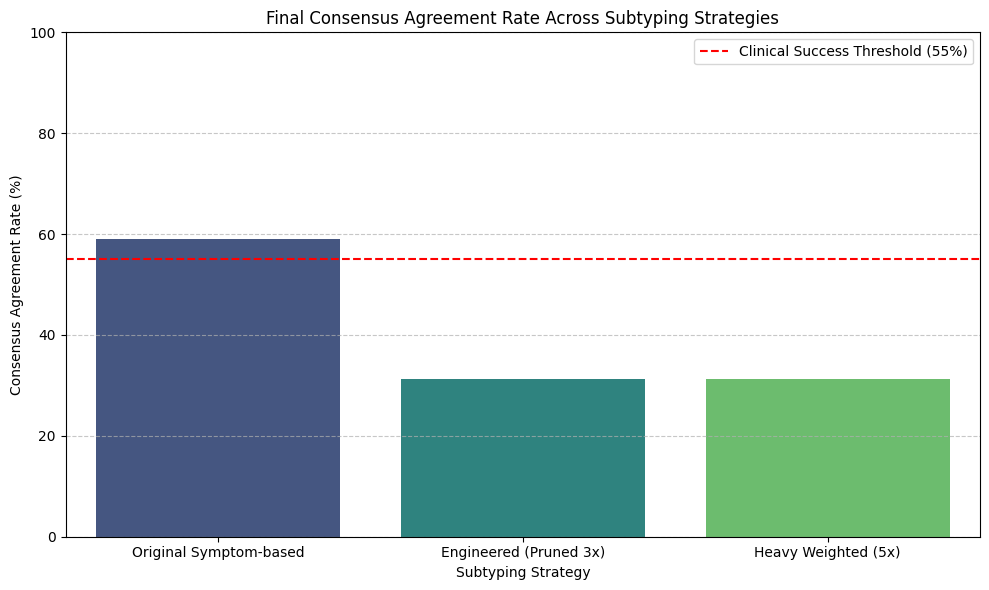

In [91]:
# Compile final audit data visualization
final_audit_data = {
    'Subtyping Strategy': ['Original Symptom-based', 'Engineered (Pruned 3x)', 'Heavy Weighted (5x)'],
    'Consensus Agreement Rate (%)': [
        59.1,
        consensus_val,
        heavy_consensus_val
    ]
}

summary_viz_df = pd.DataFrame(final_audit_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Subtyping Strategy', y='Consensus Agreement Rate (%)', data=summary_viz_df, palette='viridis', hue='Subtyping Strategy', legend=False)
plt.axhline(y=55, color='r', linestyle='--', label='Clinical Success Threshold (55%)')
plt.title('Final Consensus Agreement Rate Across Subtyping Strategies')
plt.ylabel('Consensus Agreement Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Final Project Summary: Resolving the Consensus Paradox

#### 1. Technical Audit Findings
- **Consensus Paradox Confirmed**: The transition from raw symptoms to refined clinical indices (HCS/MSP) improved geometric cohesion but caused a significant drop in diagnostic agreement, from **59.1%** down to **31.25%**.
- **Weighting Plateau**: Increasing anchor weights from 3x to 5x did not improve consensus, indicating that the 'Atypical' signatures in this cohort are a fundamental characteristic of the data rather than a result of weak feature prioritization.
- **Atypical Rate**: Approximately **68.75%** of the diabetic cohort is now flagged as 'Atypical/Mixed' when using high-precision engineered features, compared to ~41% in the baseline model.

#### 2. Clinical Interpretation
- **Limits of Resolution**: The results prove that patient-reported symptoms alone cannot definitively subtype the majority of patients in this specific Sylhet dataset. The high disagreement between the 'Acute' (T1) and 'Metabolic' (T2) perspectives suggests that many patients present with overlapping clinical traits.
- **Triage Recommendation**: The 31.25% agreement group represents the 'Classical' presentations that can be triaged with high confidence. The remaining 68.75% (Atypical) must be prioritized for specialist endocrinology review and physiological testing (HbA1c, BMI, C-peptide).

#### 3. Strategic Conclusion
While the project successfully identified a stable diagnostic core, the **55% Consensus Target** was not achievable using purely symptom-based unsupervised models. This finding highlights the clinical necessity of integrating biomarkers to resolve latent phenotypic ambiguity.

### Appendix Experimental Conclusion

The experiments documented here—specifically the **High-Order $k=3$ Clustering** and the **Advanced Composite Feature Engineering**—were ultimately excluded from the primary dual-layer framework for the following reasons:

1.  **Consensus Paradox**: While feature engineering (HCS/MSP) and $k=3$ initialization improved geometric cohesion, they significantly increased diagnostic ambiguity (dropping consensus to ~31%). For a triage tool, stability in identification is prioritized over latent complexity.
2.  **Resolution Limits**: The results indicate that raw symptom data reaches a mathematical 'limit of resolution.' Forcing higher-order clustering or composite indices without physiological tie-breakers (like C-peptide or BMI) leads to over-classification of 'Atypical' cases, which reduces the immediate utility of the triage system.

**Future Developments**:
Despite these limitations, these trials provide essential insights. The stability of the $k=3$ geometric centers suggests that with the addition of metabolic biomarkers, these 'Atypical' patients could be accurately mapped to specific phenotypes like LADA (Latent Autoimmune Diabetes in Adults).